### Imports and Packages Used

In [21]:
# rdkit drawing libraries
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG, display
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

# standard libraries
import os
import pickle
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import copy 
from tqdm import tqdm
from IPython.display import display

# machine learning libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torch_geometric.nn import global_mean_pool, GINEConv

# GNN (PyTorch Geometric)
from torch_geometric.data import Data as PyGData
from torch_geometric.loader import DataLoader as GraphDataLoader

# Transformer (PyTorch) 
from torch.utils.data import Dataset as TorchDataset
from torch.utils.data import DataLoader as TorchDataLoader
from torch.utils.data import WeightedRandomSampler

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

# used to explore hyperparameter space
from sklearn.experimental import enable_halving_search_cv # needed for HalvingRandomSearch import
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.stats import uniform, loguniform, randint

# savio device checks
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using device: cpu
False


### (1) Retrieve the cleaned data from data_exploration.ipynb to use in our model. 
Structure them to use in models.

In [22]:
alchemy_elements = {'C', 'Cl', 'F', 'H', 'N', 'O', 'S'}

molecule_types_df_path = "/Users/joshuahoang/Downloads/savio_full_project/Collected Data Processed/final_version_with_smiles_coords_angles.pkl"
molecule_types_df = pd.read_pickle(molecule_types_df_path)
display(molecule_types_df)

reaction_types_df_path = "/Users/joshuahoang/Downloads/savio_full_project/Collected Data Processed/uspto_50k_processed.csv"
reaction_types_df = pd.read_csv(reaction_types_df_path)
display(reaction_types_df)

,gdb_idx,atom number,"zpve\n(Ha, zero point vibrational energy)","Cv\n(cal/molK, heat capacity at 298.15 K)","gap\n(Ha, LUMO-HOMO)","G\n(Ha, Free energy at 298.15 K)","HOMO\n(Ha, energy of HOMO)","U\n(Ha, internal energy at 298.15 K)","alpha\n(a_0^3, Isotropic polarizability)","U0\n(Ha, internal energy at 0 K)","H\n(Ha, enthalpy at 298.15 K)","LUMO\n(Ha, energy of LUMO)","mu\n(D, dipole moment)","R2\n(a_0^2, electronic spatial extent)",smiles,coords,node_angles
0,2859833,9,0.226164,0.000067,0.300531,-352.128828,-0.236722,-352.076085,99.201621,-352.088194,-352.075141,0.063809,0.180558,1919.249225,CC#CC[C@H](C)CCC,"[[1.4191, 1.0679, -0.7249], [0.642, 0.2423, -1...","{0: [], 1: [1.995018720626831], 2: [2.02745819..."
1,3148292,9,0.180782,0.000058,0.293098,-386.820766,-0.241536,-386.774917,84.670738,-386.784878,-386.773973,0.051562,1.302656,1420.242859,C#CC[C@@H]1CO[C@@H]1CC,"[[0.8276, 0.4718, 0.3516], [0.3443, -0.9649, 0...","{0: [], 1: [1.9479340314865112], 2: [1.9565199..."
2,3607838,9,0.205922,0.000057,0.307544,-388.062328,-0.224965,-388.018758,86.198178,-388.028208,-388.017814,0.082579,1.284923,1257.238492,CC[C@H]1[C@H]2CCO[C@]21C,"[[1.1241, 1.687, -0.1877], [0.1225, 0.564, -0....","{0: [], 1: [1.9696639776229858], 2: [2.1605758..."
3,9540153,11,0.160845,0.000056,0.195923,-515.046508,-0.203538,-515.001198,95.801267,-515.010568,-515.000254,-0.007615,4.074910,1600.220066,COc1nccc2c1OCC2,"[[-5.1197, 7.1633, 5.3178], [-4.7619, 6.1363, ...","{0: [], 1: [2.1072568893432617], 2: [1.9805861..."
4,340363,10,0.177712,0.000057,0.254495,-403.843164,-0.248943,-403.800346,95.147725,-403.809426,-403.799402,0.005552,4.111533,1442.171110,CC1=CC[C@H]2C[C@@H]2[C@H]1C#N,"[[0.4915, 0.3661, 0.231], [0.5473, 0.8513, -1....","{0: [], 1: [2.125312328338623, 2.0248210430145..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202574,9581016,10,0.120222,0.000051,0.179768,-450.915828,-0.244325,-450.872449,88.581216,-450.881390,-450.871505,-0.064557,6.434535,1541.115465,CNc1cc(C#N)ncn1,"[[1.1884, 0.0204, -0.0006], [0.1768, 0.0285, -...","{0: [], 1: [2.1844115257263184], 2: [2.1464011..."
202575,9706527,10,0.130179,0.000053,0.189401,-438.632624,-0.231340,-438.589755,96.102362,-438.598674,-438.588811,-0.041938,0.338522,1628.839361,C#Cc1ccnc(OC)c1,"[[1.2218, 0.0872, -0.2336], [0.234, 1.1131, -0...","{0: [], 1: [2.0464351177215576], 2: [2.0328996..."
202576,9760179,10,0.119919,0.000051,0.163827,-450.920199,-0.232783,-450.875248,89.074794,-450.884399,-450.874304,-0.068956,4.337358,1497.024559,CNc1nccc(C#N)n1,"[[1.2711, 0.1905, 0.01], [0.3996, -0.033, 1.14...","{0: [], 1: [2.162799835205078], 2: [2.02789354..."
202577,9845175,10,0.119740,0.000050,0.191354,-454.722866,-0.251374,-454.680504,89.026059,-454.689065,-454.679560,-0.060020,5.263580,1611.219983,COc1cncc(C#N)c1,"[[0.733, 0.0993, -0.1025], [1.2403, 0.3389, -1...","{0: [], 1: [2.067808151245117], 2: [2.18707561..."


,reactant,product,category
0,C1=COCCC1.COC(=O)CCC(=O)c1ccc(O)cc1O,COC(=O)CCC(=O)c1ccc(OC2CCCCO2)cc1O,1
1,COC(=O)c1cccc(C(=O)O)c1.Nc1cccnc1N,COC(=O)c1cccc(-c2nc3cccnc3[nH]2)c1,4
2,CC(C)(C)OC(=O)NC1CCC(C(=O)O)CC1.CNOC,CON(C)C(=O)C1CCC(NC(=O)OC(C)(C)C)CC1,2
3,Nc1ccc(O)cc1.O=[N+]([O-])c1ccc(Cl)nc1Cl,O=[N+]([O-])c1ccc(Cl)nc1Nc1ccc(O)cc1,1
4,[N-]=[N+]=NCC1=CC[C@@H](c2ccc(Cl)cc2Cl)[C@H]([...,NCC1=CC[C@@H](c2ccc(Cl)cc2Cl)[C@H]([N+](=O)[O-...,9
...,...,...,...
35111,COC(=O)c1ccc(C(=O)OCc2ccccc2)cc1F,COC(=O)c1ccc(C(=O)O)cc1F,6
35112,C=CCOC(=O)N1CCc2nnc(NN)cc2C1.CC(C)=O,C=CCOC(=O)N1CCc2nnc(NN=C(C)C)cc2C1,1
35113,FC1(F)CCNC1.O=C(O)c1ccncc1NC(=O)c1nc(C2CC2)ccc...,O=C(Nc1cnccc1C(=O)N1CCC(F)(F)C1)c1nc(C2CC2)ccc...,2
35114,CC(=O)Cl.CC(C)(C)OC(=O)NCCO,CC(=O)OCCNC(=O)OC(C)(C)C,2


Pipeline for GNN

(1) The GNN will take each molecule as a pooling of the atoms as nodes and the bonds as edges and lets each atom/node update its features by aggreating from its neighbors. 

(2) After this messaging, pool atoms to molecule to predict the target features that will be used in trasnformer for the reaction type. 

- Of the target features for the GNN from the alchemy dataset, 12 columns are physics-relevent feature columns

- 9/12 of the physics-relevent ones do not have too bad overlap and will be used as features for molecules in the transformer to see if it does improve the transformer's predictive power. 

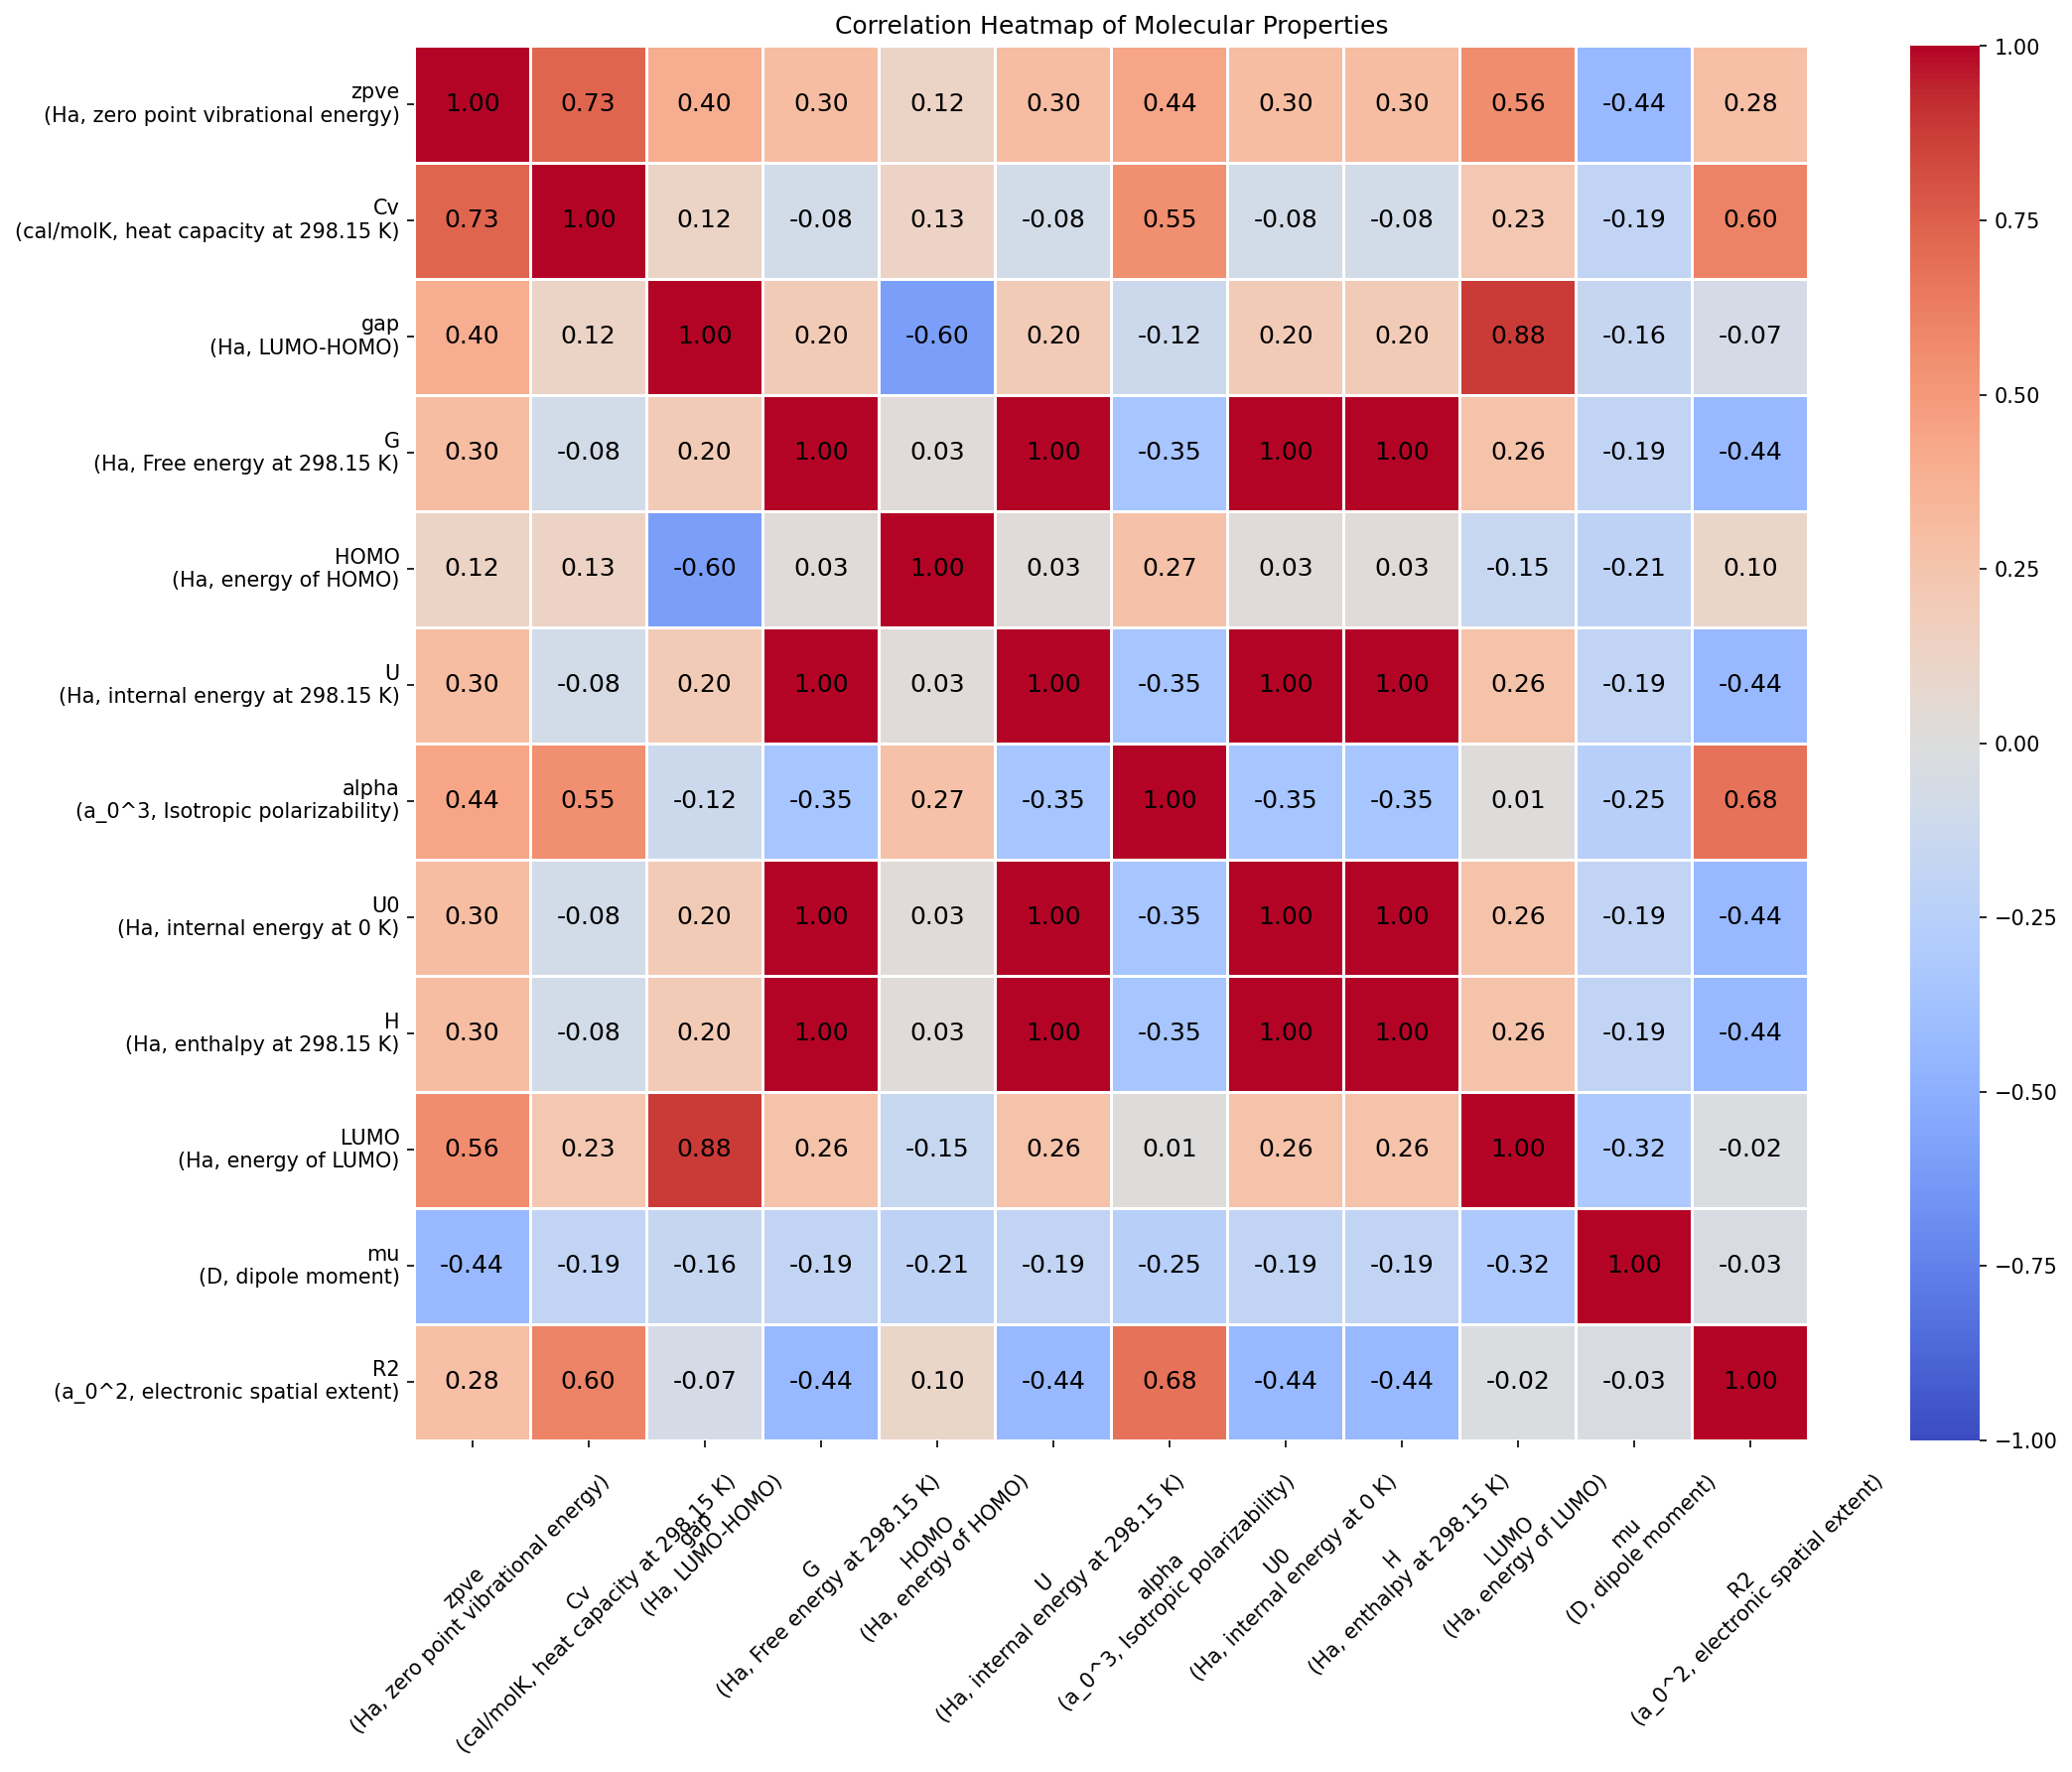

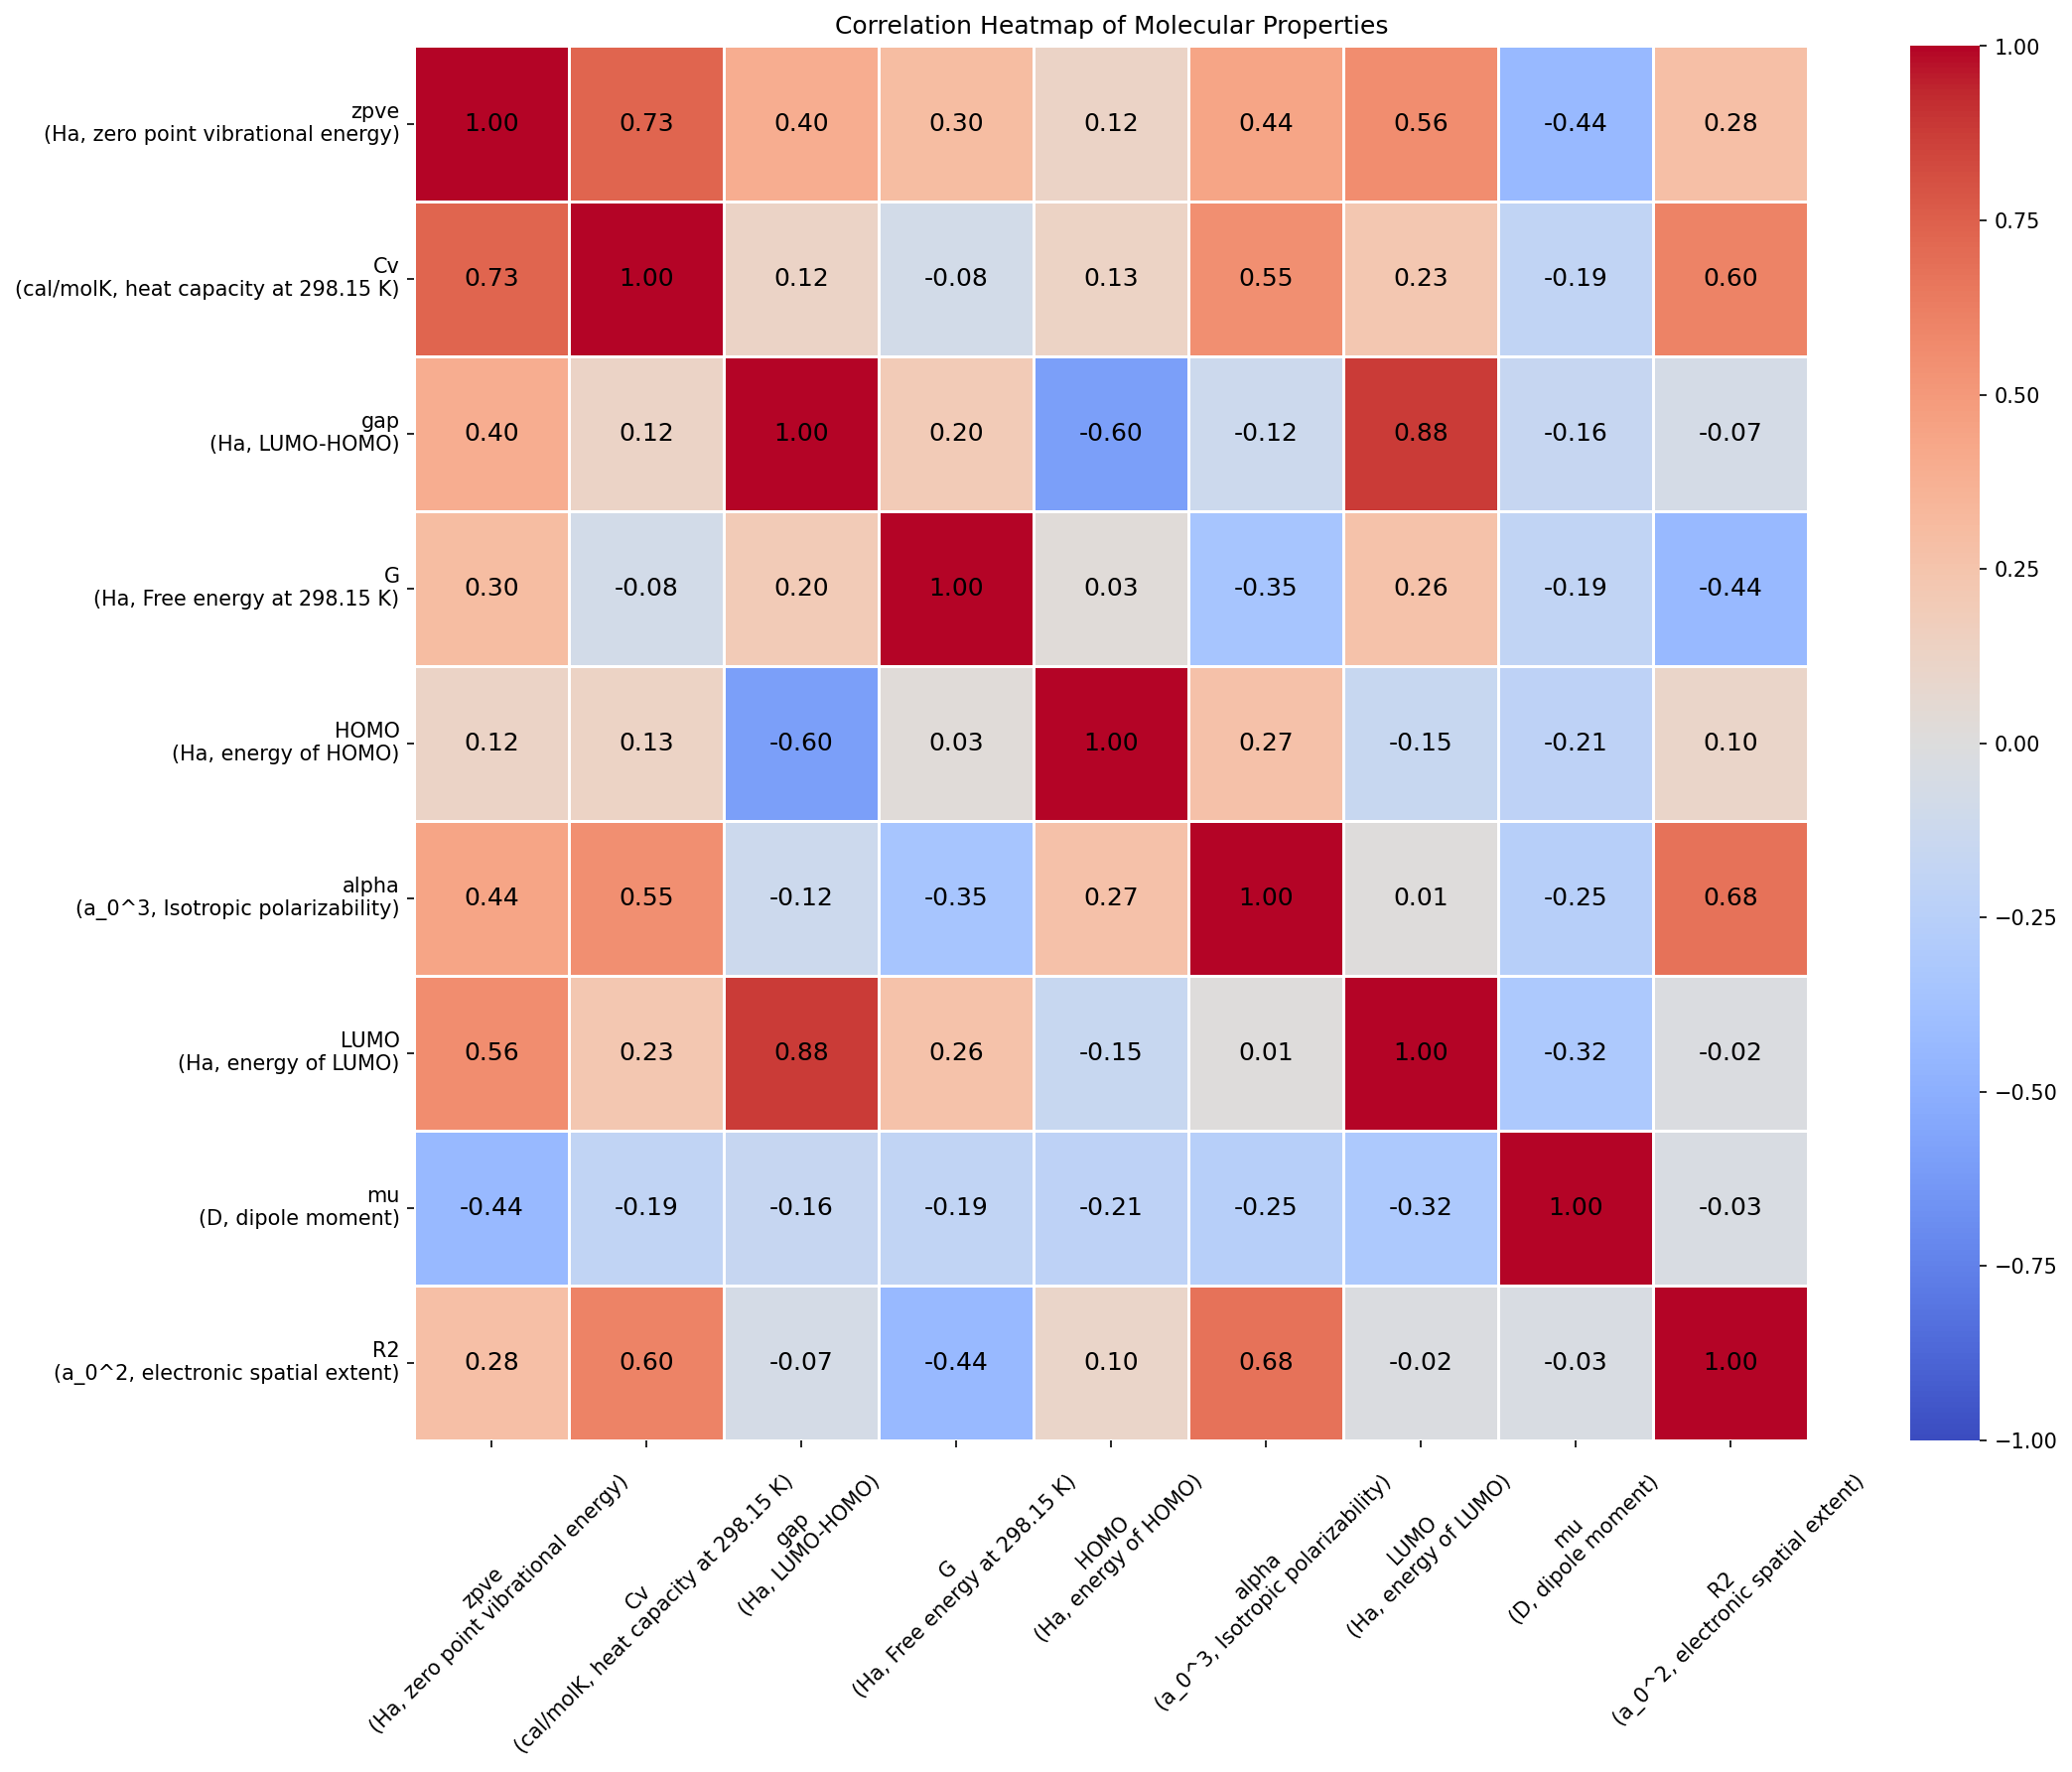

In [23]:
def plot_heatmap(df, title="Correlation Heatmap of Molecular Properties"):

    corr = df.corr(numeric_only=True)

    plt.figure(figsize=(16, 12), dpi=150)

    sns.heatmap(
        data=corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        square=True,
        annot_kws={"size": 12, "color": "black"},  # bigger + force color
        linewidths=0.5  # adds grid lines to separate cells
    )

    plt.title(title)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# 12 that are physics-relevent target features
molecule_targets_df = molecule_types_df.drop(columns=[
    'smiles', 
    'gdb_idx', 
    'atom number', 
    'coords', 
    'node_angles'
])
plot_heatmap(molecule_targets_df)

# G, U, U0, H: G = U + PV - TS = H - TS, so we only need 1 -> keep G
molecule_targets_df = molecule_types_df.drop(columns=[
    'smiles', 
    'gdb_idx', 
    'atom number', 
    'coords',
    'node_angles',
    'U\n(Ha, internal energy at 298.15 K)',
    'U0\n(Ha, internal energy at 0 K)', 
    'H\n(Ha, enthalpy at 298.15 K)', 
])
plot_heatmap(molecule_targets_df)

### (2) GNN Creation

Turn all the alchemy data into a graph structure. We choose the features that help predict the nine properties like bond angle, bond length in the form of RBF (Radial Basis Function) which helps the model learn the importance of distances easiler based on gaussian distribution of distances.

In [24]:
class AlchemyGraphFeaturizer:

    def __init__(self, alchemy_elements, target_cols, max_angles=6, rbf_centers=16):

        # =========================
        # NODE (ATOM) FEATURE SETUP
        # =========================

        # categorical (one-hot)
        self.alchemy_elements = list(alchemy_elements)
        self.degree_set = [0, 1, 2, 3, 4, 5]
        self.numH_set = [0, 1, 2, 3, 4]
        self.charge_set = [-1, 0, 1]
        self.hybridization_set = [
            Chem.rdchem.HybridizationType.SP,
            Chem.rdchem.HybridizationType.SP2,
            Chem.rdchem.HybridizationType.SP3,
            Chem.rdchem.HybridizationType.SP3D,
            Chem.rdchem.HybridizationType.SP3D2,
        ]

        # scalars
        self.pt = Chem.GetPeriodicTable()
        self.en_map = {"H":2.20, "C":2.55, "N":3.04, "O":3.44, "F":3.98, "S":2.58, "Cl":3.16}

        # geometry (node-centered) 
        self.max_angles = max_angles # no. angles associated with an atom

        # normalization (node features) (tbd from dataset)
        self.scalar_mean = None
        self.scalar_std  = None
        self.angle_mean = None
        self.angle_std  = None

        # =========================
        # EDGE (BOND) FEATURE SETUP
        # =========================

        # categorical (one-hot)
        self.bond_types = [
            Chem.rdchem.BondType.SINGLE,
            Chem.rdchem.BondType.DOUBLE,
            Chem.rdchem.BondType.TRIPLE,
            Chem.rdchem.BondType.AROMATIC,
        ]

        self.stereo_types = [
            Chem.rdchem.BondStereo.STEREONONE,
            Chem.rdchem.BondStereo.STEREOZ,
            Chem.rdchem.BondStereo.STEREOE,
        ]

        # distance encoding for edge features
        self.rbf_centers = rbf_centers

        # =========================
        # GRAPH-LEVEL FEATURES
        # =========================

        # which column from dataframe are prediction targets
        self.target_cols = list(target_cols)

        # normalization (targets / graph-level)
        self.y_mean = None
        self.y_std  = None
        self.graph_mean = None
        self.graph_std  = None


    # =========================
    # GENERIC HELPER FUNCTIONS
    # =========================

    # one_hot encoder used for various node and edge features
    def one_hot(self, value, choices):
        return [int(value == c) for c in choices]
    
    # helper function to get angle from sdf files for node feature
    def compute_angle(self, a, b, c, pos):
        ba = pos[a] - pos[b]
        bc = pos[c] - pos[b]
        cos_theta = torch.dot(ba, bc) / (torch.norm(ba) * torch.norm(bc) + 1e-8)
        cos_theta = torch.clamp(cos_theta, -1.0, 1.0)
        return torch.acos(cos_theta).item()

    # =========================
    # GRAPH-LEVEL FEATURES
    # =========================

    # computes the global descriptors of each molecule
    def raw_graph_level_features(self, mol, pos):

        # find the count of the atoms in the molecule
        heavy_atom_count = mol.GetNumAtoms()
        total_H_count = sum(atom.GetTotalNumHs() for atom in mol.GetAtoms())
        atom_count = heavy_atom_count + total_H_count
    
        # get the MW 
        molecular_weight = sum(self.pt.GetAtomicWeight(atom.GetSymbol()) for atom in mol.GetAtoms())
        molecular_weight += total_H_count * self.pt.GetAtomicWeight("H")
    
        # get the geometric properties for graph-level
        if pos.shape[0] <= 1:
            max_pairwise_dist = 0.0
            radius_of_gyration = 0.0
        else:
            dmat = torch.cdist(pos, pos, p=2)
            max_pairwise_dist = dmat.max().item()
    
            centroid = pos.mean(dim=0, keepdim=True) # mean for the centroid
            sq_dist = ((pos - centroid) ** 2).sum(dim=1) # atom's positions relative to eachother
            radius_of_gyration = torch.sqrt(sq_dist.mean()).item() # approx radius of gyration
    
        # electronegativity-weighted centroid offset
        geom_centroid = pos.mean(dim=0)
    
        en_weights = torch.tensor(
            [self.en_map.get(atom.GetSymbol(), 0.0) for atom in mol.GetAtoms()],
            dtype=torch.float
        )
    
        if en_weights.sum().item() > 1e-8:
            en_centroid = (en_weights.unsqueeze(1) * pos).sum(dim=0) / en_weights.sum()
            en_centroid_offset = torch.norm(en_centroid - geom_centroid).item()
        else:
            en_centroid_offset = 0.0
    
        return [
            atom_count,
            heavy_atom_count,
            molecular_weight,
            max_pairwise_dist,
            radius_of_gyration,
            en_centroid_offset
        ]
    
    # normalize the graph features
    def graph_level_features(self, mol, pos):
        vals = torch.tensor(self.raw_graph_level_features(mol, pos), dtype=torch.float)

        if self.graph_mean is not None and self.graph_std is not None:
            vals = (vals - self.graph_mean) / (self.graph_std + 1e-8)

        return vals

    # =========================
    # NORMALIZATION SETUP
    # =========================

    # fits the mean/std values needed to normalize node, graph, and target values
    def fit_normalization_from_df(self, df):

        # store values across the full dataframe before taking mean/std
        scalar_vals = []
        angle_vals = []
        y_vals = []
        graph_vals = []

        for _, row in df.iterrows():

            smi = row["smiles"]
            coords = row["coords"]

            mol = Chem.MolFromSmiles(smi)
            if mol is None: continue

            pos = torch.tensor(coords, dtype=torch.float)

            # skip bad rows where coordinates do not match atoms
            # should not happen considering I cleaned the data but just in case
            if pos.shape[0] != mol.GetNumAtoms(): continue

            # collect node-level scalar features
            for atom in mol.GetAtoms():
                sym = atom.GetSymbol()
                Z = self.pt.GetAtomicNumber(sym)

                scalar_vals.append([
                    self.pt.GetAtomicWeight(sym),
                    self.pt.GetRvdw(Z),
                    self.pt.GetRcovalent(Z),
                    self.pt.GetDefaultValence(Z),
                    self.en_map.get(sym, 0.0),
                ])

            # collect node-level angle features
            for atom in mol.GetAtoms():
                atom_idx = atom.GetIdx()
                nbr_indices = [nbr.GetIdx() for nbr in atom.GetNeighbors()]

                for i in range(len(nbr_indices)):
                    for j in range(i + 1, len(nbr_indices)):
                        angle_vals.append(
                            self.compute_angle(nbr_indices[i], atom_idx, nbr_indices[j], pos)
                        )

            # collect graph-level features and target values
            graph_vals.append(self.raw_graph_level_features(mol, pos))
            y_vals.append(row[self.target_cols].astype(float).tolist())

        # convert collected values into tensors
        scalar_vals = torch.tensor(scalar_vals, dtype=torch.float)
        y_vals = torch.tensor(y_vals, dtype=torch.float)
        graph_vals = torch.tensor(graph_vals, dtype=torch.float)

        # node scalar normalization stats
        self.scalar_mean = scalar_vals.mean(dim=0)
        self.scalar_std = scalar_vals.std(dim=0).clamp_min(1e-8)

        # angle normalization stats
        if len(angle_vals) == 0:
            self.angle_mean = torch.zeros(self.max_angles, dtype=torch.float)
            self.angle_std = torch.ones(self.max_angles, dtype=torch.float)
        else:
            angle_vals = torch.tensor(angle_vals, dtype=torch.float)

            angle_mean_scalar = angle_vals.mean()
            angle_std_scalar = angle_vals.std().clamp_min(1e-8)

            self.angle_mean = torch.full((self.max_angles,), angle_mean_scalar, dtype=torch.float)
            self.angle_std = torch.full((self.max_angles,), angle_std_scalar, dtype=torch.float)

        # target normalization stats
        self.y_mean = y_vals.mean(dim=0)
        self.y_std = y_vals.std(dim=0).clamp_min(1e-8)

        # graph-level feature normalization stats
        self.graph_mean = graph_vals.mean(dim=0)
        self.graph_std = graph_vals.std(dim=0).clamp_min(1e-8)


    # =========================
    # NODE (ATOM) FEATURES
    # =========================

    # gets scalar atom properties and normalizes them
    def atom_scalars(self, atom):

        sym = atom.GetSymbol()
        Z = self.pt.GetAtomicNumber(sym)

        vals = torch.tensor([
            self.pt.GetAtomicWeight(sym),
            self.pt.GetRvdw(Z),
            self.pt.GetRcovalent(Z),
            self.pt.GetDefaultValence(Z),
            self.en_map.get(sym, 0.0),
        ], dtype=torch.float)

        if self.scalar_mean is not None and self.scalar_std is not None:
            vals = (vals - self.scalar_mean) / (self.scalar_std + 1e-8)

        return vals.tolist()


    # gets the bond angles around an atom and pads them to fixed length
    def padded_angle_vector(self, atom_idx, mol, pos):

        atom = mol.GetAtomWithIdx(atom_idx)
        nbr_indices = [nbr.GetIdx() for nbr in atom.GetNeighbors()]

        angles = []

        # compute all neighbor-atom-neighbor angles around this atom
        # NOTE: this opration is costly but improved the gnn considerably for targets 
        # dipole moment and electronic extent
        for i in range(len(nbr_indices)):
            for j in range(i + 1, len(nbr_indices)):
                angles.append(
                    self.compute_angle(nbr_indices[i], atom_idx, nbr_indices[j], pos)
                )

        # sort so the ordering is consistent
        angles = sorted(angles)

        # keep only max_angles
        real_count = min(len(angles), self.max_angles)
        angles = angles[:self.max_angles]

        # mask tells the model which angle entries are real vs padded
        mask = [1.0] * real_count

        # pad missing angles with zero
        if len(angles) < self.max_angles:
            pad = self.max_angles - len(angles)
            angles = angles + [0.0] * pad
            mask = mask + [0.0] * pad

        angles = torch.tensor(angles, dtype=torch.float)

        # normalize only real angles, not padded zeros
        if self.angle_mean is not None and self.angle_std is not None:
            real_mask = torch.tensor(mask, dtype=torch.float)

            angles = torch.where(
                real_mask > 0,
                (angles - self.angle_mean) / (self.angle_std + 1e-8),
                angles
            )

        return angles.tolist() + mask


    # combines all atom-level information into one node feature vector
    def atom_feature_vector(self, atom, mol, pos):

        return (
            self.one_hot(atom.GetSymbol(), self.alchemy_elements) +
            self.one_hot(atom.GetDegree(), self.degree_set) +
            self.one_hot(atom.GetTotalNumHs(), self.numH_set) +
            self.one_hot(atom.GetFormalCharge(), self.charge_set) +
            [int(atom.GetIsAromatic())] +
            [int(atom.IsInRing())] +
            self.one_hot(atom.GetHybridization(), self.hybridization_set) +
            self.padded_angle_vector(atom.GetIdx(), mol, pos) +
            self.atom_scalars(atom)
        )


    # =========================
    # EDGE (BOND) FEATURES
    # =========================

    # expands a bond distance into radial basis function features
    def rbf_expand(self, d):

        d = torch.tensor(d, dtype=torch.float)

        centers = torch.linspace(0.0, 3.0, steps=self.rbf_centers)

        delta = centers[1] - centers[0]
        gamma = 1.0 / (delta.item() ** 2 + 1e-8)

        return torch.exp(-gamma * (d - centers) ** 2).tolist()


    # combines all bond-level information into one edge feature vector
    def bond_feature_vector(self, bond, pos):

        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        # 3D bond distance from SDF coordinates
        distance = torch.norm(pos[i] - pos[j]).item()

        return (
            self.one_hot(bond.GetBondType(), self.bond_types) +
            [int(bond.IsInRing())] +
            self.one_hot(bond.GetStereo(), self.stereo_types) +
            self.rbf_expand(distance)
        )


    # =========================
    # TARGET NORMALIZATION
    # =========================

    # normalizes the target values before training
    def normalize_y(self, y):

        y = torch.tensor(y, dtype=torch.float)

        if self.y_mean is not None and self.y_std is not None:
            y = (y - self.y_mean) / (self.y_std + 1e-8)

        return y.view(1, -1)


    # converts predicted normalized targets back to original units
    def unnormalize_y(self, y):

        if self.y_mean is None or self.y_std is None:
            return y

        return y * self.y_std + self.y_mean


    # =========================
    # GRAPH OBJECT CONSTRUCTION
    # =========================

    # converts one molecule into a PyTorch Geometric graph object
    def smiles_to_graph_alchemy(self, smi, coords, y):

        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None

        pos = torch.tensor(coords, dtype=torch.float)

        # skip bad rows where coordinate count does not match atom count
        if pos.shape[0] != mol.GetNumAtoms():
            return None

        # build node feature matrix
        x = torch.tensor(
            [self.atom_feature_vector(atom, mol, pos) for atom in mol.GetAtoms()],
            dtype=torch.float
        )

        edge_index = []
        edge_attr = []

        # build edge connectivity and edge features
        for bond in mol.GetBonds():

            i = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()

            bf = self.bond_feature_vector(bond, pos)

            # add both directions because PyG message passing uses directed edges
            edge_index.append((i, j))
            edge_attr.append(bf)

            edge_index.append((j, i))
            edge_attr.append(bf)

        # handle molecules with no bonds
        if len(edge_index) == 0:

            edge_dim = len(self.bond_types) + 1 + len(self.stereo_types) + self.rbf_centers

            edge_index = torch.empty((2, 0), dtype=torch.long)
            edge_attr = torch.empty((0, edge_dim), dtype=torch.float)

        else:

            edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
            edge_attr = torch.tensor(edge_attr, dtype=torch.float)

        # graph-level molecular descriptors
        graph_feat = self.graph_level_features(mol, pos).view(1, -1)

        # normalized quantum-property targets
        y = self.normalize_y(y)

        return PyGData(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            pos=pos,
            y=y,
            graph_feat=graph_feat
        )


    # converts a full dataframe into a list of PyG graph objects
    def dataframe_to_graph_dataset(self, df):

        graph_dataset = []

        for _, row in df.iterrows():

            graph = self.smiles_to_graph_alchemy(
                row["smiles"],
                row["coords"],
                row[self.target_cols].astype(float).tolist()
            )

            if graph is not None:
                graph_dataset.append(graph)

        return graph_dataset

Convert the molecule_type_df into graph_dataset for use in the GNN.

In [25]:
run_featurizer = False

if run_featurizer: 
    # targets = everything remaining after drop
    target_cols = molecule_targets_df.columns.tolist()

    # initialize featurizer
    featurizer = AlchemyGraphFeaturizer(
        alchemy_elements=alchemy_elements,
        target_cols=target_cols
    )

    # fit ALL normalization inside class
    featurizer.fit_normalization_from_df(molecule_types_df)

    # build normalized graph dataset
    graph_dataset = featurizer.dataframe_to_graph_dataset(molecule_types_df)
else: 
    print("No need to run again, featurizer completed.")

No need to run again, featurizer completed.


In [26]:
save_featurizer = False

if save_featurizer:

    # save graph dataset
    torch.save(graph_dataset, "cached_data/graph_dataset.pt")

    # save only the picklable featurizer state
    featurizer_state = {
        "alchemy_elements": featurizer.alchemy_elements,
        "target_cols": featurizer.target_cols,
        "max_angles": featurizer.max_angles,
        "rbf_centers": featurizer.rbf_centers,

        "degree_set": featurizer.degree_set,
        "numH_set": featurizer.numH_set,
        "charge_set": featurizer.charge_set,

        # save RDKit enum-like objects as strings
        "hybridization_set": [str(x) for x in featurizer.hybridization_set],
        "bond_types": [str(x) for x in featurizer.bond_types],
        "stereo_types": [str(x) for x in featurizer.stereo_types],

        "en_map": featurizer.en_map,

        "scalar_mean": featurizer.scalar_mean,
        "scalar_std": featurizer.scalar_std,
        "angle_mean": featurizer.angle_mean,
        "angle_std": featurizer.angle_std,
        "y_mean": featurizer.y_mean,
        "y_std": featurizer.y_std,
        "graph_mean": featurizer.graph_mean,
        "graph_std": featurizer.graph_std,
    }

    torch.save(featurizer_state, "cached_data/featurizer_state.pt")
    
else:
    print("Already saved graph_dataset and its featurizer.")

Already saved graph_dataset and its featurizer.


In [27]:
if "graph_dataset" not in globals() or "featurizer" not in globals():

    graph_dataset_path = "/Users/joshuahoang/Downloads/savio_full_project/gnn_and_transformer_development/cached_data/graph_dataset.pt"
    graph_dataset = torch.load(graph_dataset_path) # this graph_dataset is quite large

    featurizer_state_path = "/Users/joshuahoang/Downloads/savio_full_project/gnn_and_transformer_development/cached_data/featurizer_state.pt"
    featurizer_state = torch.load(featurizer_state_path)

    # pull out the calculation from storage to make featurizer
    featurizer = AlchemyGraphFeaturizer(
    alchemy_elements=featurizer_state["alchemy_elements"],
    target_cols=featurizer_state["target_cols"],
    max_angles=featurizer_state["max_angles"],
    rbf_centers=featurizer_state["rbf_centers"],
    )
    
    featurizer.degree_set = featurizer_state["degree_set"]
    featurizer.numH_set = featurizer_state["numH_set"]
    featurizer.charge_set = featurizer_state["charge_set"]
    featurizer.en_map = featurizer_state["en_map"]

    featurizer.scalar_mean = featurizer_state["scalar_mean"]
    featurizer.scalar_std = featurizer_state["scalar_std"]
    featurizer.angle_mean = featurizer_state["angle_mean"]
    featurizer.angle_std = featurizer_state["angle_std"]
    featurizer.y_mean = featurizer_state["y_mean"]
    featurizer.y_std = featurizer_state["y_std"]
    featurizer.graph_mean = featurizer_state["graph_mean"]
    featurizer.graph_std = featurizer_state["graph_std"]
else: 
    print("The variables graph_dataset and featurizer have already been loaded.")
# .pt files do not like rdkit objects 

The variables graph_dataset and featurizer have already been loaded.


Now use an architechture that propogates node features.
 - GINEConv: Propagates node features but not edge features. (There is already good convergence here already, so no need to propogate edge features and increase run time.)
 - I have tried others that propograte the bond features, but they exponentially increase run time with little performance improvement like NNConv or a self-implmented Conv like from Homework 9. Also, GINEConv has alot of optimizations already and runtime is a concern.

In [28]:
class GNN(torch.nn.Module): 
    # screw around with the hidden_dim to get better regression statistic
    # number of y predictions is out_dim in case of future change (just the 9 target features)
    def __init__(self, in_channels, edge_dim, hidden_dim, out_dim = molecule_targets_df.shape[1], dropout=0.2): 
        super().__init__()

        # node features into hidden space
        self.node_encoder = nn.Linear(in_channels, hidden_dim)

        # edge features into hidden space
        self.edge_encoder = nn.Linear(edge_dim, hidden_dim)

        # GINEConv blocks
        self.conv1 = GINEConv(
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ),
            edge_dim=hidden_dim
        )

        self.conv2 = GINEConv(
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ),
            edge_dim=hidden_dim
        )

        self.conv3 = GINEConv(
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ),
            edge_dim=hidden_dim
        ) # test and turns out three conv blocks seemed to be the best

        # because we concatenate 6 graph-level descriptors after pooling
        self.lin1 = nn.Linear(hidden_dim + 6, hidden_dim)
        self.dropout = nn.Dropout(dropout)

        # one small head per target
        self.heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim // 2, 1)
            )
            for _ in range(out_dim)
        ])

    def forward(self, x, edge_index, edge_attr, batch, graph_feat):
        # encode raw node and edge features into hidden space
        x = self.node_encoder(x)
        edge_attr = self.edge_encoder(edge_attr)
    
        # first graph convolution block
        x_res = x # skip connection
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.dropout(x)
        x = x + x_res # skip connection
    
        # second graph convolution block
        x_res = x # skip connection
        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.dropout(x)
        x = x + x_res # skip connection
    
        # third graph convolution block
        x_res = x # skip connection
        x = self.conv3(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.dropout(x)
        x = x + x_res # skip connection
    
        # pool from atom space to molecule space
        # concatenate graph-level size / shape descriptors
        # does NOT affect message passing, affect only the final prediction
        # is never ever propogated, like edge features
        x = global_mean_pool(x, batch)
        x = torch.cat([x, graph_feat], dim=1)
    
        # readout MLP 
        x = self.lin1(x)
        x = F.relu(x)
        x = self.dropout(x)

        # task-specific heads
        out = torch.cat([head(x) for head in self.heads], dim=1)
        return out
        

class GNNTrainer: 
    def __init__(
        self,
        model,
        optimizer=torch.optim.Adam,
        lr=1e-3,
        loss_type="smoothl1",
        beta=0.5, # smaller is more l1 like (~0.5), larger is l2 (~2)
        device="cpu"
    ):
        super().__init__()

        self.model = model.to(device)
        self.device = device
        self.optimizer = optimizer(self.model.parameters(), lr=lr)

        if loss_type == "mse": self.loss_function = torch.nn.MSELoss()
        elif loss_type == "smoothl1": self.loss_function = torch.nn.SmoothL1Loss(beta=beta)
        else: raise ValueError(f"Unsupported loss_type: {loss_type}'")

    def train_one_epoch(self, loader): 
        # training mode that activates dropout
        self.model.train()
        total_loss = 0.0

        for batch in loader: 
            batch = batch.to(self.device) # move PyG to device
            self.optimizer.zero_grad() # clear old grads from previous batch

            # forward pass, true targets
            pred = self.model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.graph_feat)
            target = batch.y

            # reshape so targets match
            pred = pred.reshape(target.shape).contiguous()
            target = target.contiguous()

            # regression loss, find grad, update weights, and store loss
            loss = self.loss_function(pred, target)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
        
        return total_loss / len(loader) # avg loss across batches
    
    @torch.no_grad()
    def evaluate(self, loader): 
        # evaluate mode that deactivates dropout
        self.model.eval()
        total_loss = 0.0
        all_preds = []
        all_targets = []

        for batch in loader: 
            batch = batch.to(self.device) 

            # forward pass, true targets
            pred = self.model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.graph_feat)
            target = batch.y

            # reshape so targets match
            pred = pred.reshape(target.shape).contiguous()
            target = target.contiguous()

            # validation and test loss
            loss = self.loss_function(pred, target)
            total_loss += loss.item()

            # save all predcitions for r2 calculation
            all_preds.append(pred.cpu())
            all_targets.append(target.cpu())
        
        # shove all batches into one tensor to calculate r2 
        all_preds = torch.cat(all_preds, dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        
        ss_res = ((all_preds - all_targets) ** 2).sum(dim=0)
        ss_tot = ((all_targets - all_targets.mean(dim=0)) ** 2).sum(dim=0).clamp_min(1e-8)

        r2_per_output = 1 - (ss_res / ss_tot)
        avg_r2 = r2_per_output.mean().item()
        
        return total_loss / len(loader), avg_r2
    
    # the full training loop
    def fit(self, train_loader, val_loader, epochs=20, show_progress=True): 
        # track loss and r2 over epochs for plotting
        train_losses = []
        val_losses = []
        train_r2s = []
        val_r2s = []

        # best model tracking based on validation loss
        best_val_loss = float("inf")
        best_train_loss = None
        best_train_r2 = None
        best_val_r2 = None

        for epoch in range(1, epochs + 1): 
            # train one epoch
            train_loss = self.train_one_epoch(train_loader)

            # evaluate on train and validation sets
            _, train_r2 = self.evaluate(train_loader)
            val_loss, val_r2 = self.evaluate(val_loader)

            # store metrics
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_r2s.append(train_r2)
            val_r2s.append(val_r2)

            # track best validation loss (early stopping)
            # lowest validation loss means best generalization
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_train_loss = train_loss
                best_train_r2 = train_r2
                best_val_r2 = val_r2

            if show_progress:
                print(
                    f"Epoch {epoch}: "
                    f"train_loss={train_loss:.4f}, "
                    f"train_r2={train_r2:.4f}, "
                    f"val_loss={val_loss:.4f}, "
                    f"val_r2={val_r2:.4f}"
                )

        # return the best metrics and the training curves
        return {
            "best_train_loss": best_train_loss,
            "best_val_loss": best_val_loss,
            "best_train_r2": best_train_r2,
            "best_val_r2": best_val_r2,

            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_r2s": train_r2s,
            "val_r2s": val_r2s,
        }

In [29]:
def run_single_split(
        model_class,
        train_graphs,
        val_graphs,
        batch_size=32,
        epochs=20,
        hidden_dim=64,
        dropout=0.2,
        lr=1e-3,
        optimizer=torch.optim.Adam,
        loss_type="smoothl1",
        beta=0.5,
        device="cpu",
        show_progress=False,
        val_every=1,
        train_eval_every=1
):
    """
    Train one model on one train/validation split.
    Returns metrics and the trained model.
    """

    # arguments for model class (fixed)
    # node, edge, and target features
    in_channels = train_graphs[0].x.shape[1]
    edge_dim = train_graphs[0].edge_attr.shape[1]
    out_dim = train_graphs[0].y.shape[1]

    train_loader = GraphDataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader = GraphDataLoader(val_graphs, batch_size=batch_size, shuffle=False)

    # initialize the model
    model = model_class(
        in_channels=in_channels,
        edge_dim=edge_dim,
        hidden_dim=hidden_dim,
        out_dim=out_dim,
        dropout=dropout
    )

    # initialize the trainer
    trainer = GNNTrainer(
        model=model,
        optimizer=optimizer,
        lr=lr,
        loss_type=loss_type,
        beta=beta,
        device=device
    )

    # tracking loss and r2 over epochs
    train_losses = []
    val_losses = []
    train_r2s = []
    val_r2s = []

    # best model tracking based on validation loss
    best_val_loss = float("inf")
    best_train_loss = None
    best_train_r2 = None
    best_val_r2 = None

    # keep previous evaluations so skipped epochs still plot nicely
    last_train_r2 = np.nan
    last_val_loss = np.nan
    last_val_r2 = np.nan

    for epoch in range(1, epochs + 1):

        # train one epoch and update the weights
        train_loss = trainer.train_one_epoch(train_loader)
        train_losses.append(train_loss)

        # only evaluate train set every few epochs
        if epoch % train_eval_every == 0:
            _, last_train_r2 = trainer.evaluate(train_loader)
        train_r2s.append(last_train_r2)

        # only evaluate validation set every few epochs
        if epoch % val_every == 0:
            last_val_loss, last_val_r2 = trainer.evaluate(val_loader)

            # track best validation loss
            if last_val_loss < best_val_loss:
                best_val_loss = last_val_loss
                best_train_loss = train_loss
                best_train_r2 = last_train_r2
                best_val_r2 = last_val_r2

        val_losses.append(last_val_loss)
        val_r2s.append(last_val_r2)

        if show_progress:
            train_r2_str = f"{last_train_r2:.4f}" if not np.isnan(last_train_r2) else "nan"
            val_loss_str = f"{last_val_loss:.4f}" if not np.isnan(last_val_loss) else "nan"
            val_r2_str = f"{last_val_r2:.4f}" if not np.isnan(last_val_r2) else "nan"

            print(
                f"Epoch {epoch}: "
                f"train_loss={train_loss:.4f}, "
                f"train_r2={train_r2_str}, "
                f"val_loss={val_loss_str}, "
                f"val_r2={val_r2_str}"
            )

    return {
        "model": trainer.model,

        "best_train_loss": best_train_loss,
        "best_val_loss": best_val_loss,
        "best_train_r2": best_train_r2,
        "best_val_r2": best_val_r2,

        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_r2s": train_r2s,
        "val_r2s": val_r2s,
    }


# replace accuracy with the R^2 regression statistic
# function used to check hyperparameters and stability
# this function DOES NOT have an early stop if the loss function dies or increases again
# that is intentional to see how it behaves
def KFoldCrossValidation(
    model_class,
    graph_dataset,
    k=3,
    batch_size=32,
    epochs=20,
    hidden_dim=64,
    dropout=0.2,
    lr=1e-3,
    optimizer=torch.optim.Adam,
    loss_type="smoothl1",
    beta=0.5,
    device="cpu",
    early_break=False,
    show_progress=False,
    make_plots=True,
    verbose=True, # print per fold results
    random_state=67,
    val_every=1,
    train_eval_every=1
): 
    """
    Run either:
    - k=1: a single train/validation split (fast for me to debug)
    - k>1: k-fold cross validation

    Returns only metrics for evaluation / hyperparameter search.
    Does NOT return a model. (No need.)
    """
    if k == 1: # k = 1 was used during code creation to check fast
        indices = list(range(len(graph_dataset)))
        train_idx, val_idx = train_test_split(
            indices, 
            test_size=0.2, 
            random_state=random_state, 
            shuffle=True
        )
        splits = [(train_idx, val_idx)]
    else:
        kf = KFold(n_splits=k, shuffle=True, random_state=random_state)
        splits = kf.split(graph_dataset)

    # contain results for each fold to compute average and std dev
    train_loss_list = []
    val_loss_list = []
    train_r2_list = []
    val_r2_list = []  

    # store full curve for all folds
    all_train_losses = [] 
    all_val_losses = []  
    all_train_r2s = []
    all_val_r2s = []  

    for fold, (train_idx, val_idx) in enumerate(splits): 

        # split data 
        train_graphs = [graph_dataset[i] for i in train_idx]
        val_graphs = [graph_dataset[i] for i in val_idx]

        # train and evaluate model on this fold
        fold_results = run_single_split(
            model_class=model_class,
            train_graphs=train_graphs,
            val_graphs=val_graphs, # run_single_split expects raw graphs, not loaders
            batch_size=batch_size,
            epochs=epochs,
            hidden_dim=hidden_dim,
            dropout=dropout,
            lr=lr,
            optimizer=optimizer,
            loss_type=loss_type,
            beta=beta,
            device=device,
            show_progress=show_progress,
            val_every=val_every,
            train_eval_every=train_eval_every
        )

        # pull the best fold metrics
        train_loss_best = fold_results["best_train_loss"]
        val_loss_best = fold_results["best_val_loss"]
        train_r2_best = fold_results["best_train_r2"]
        val_r2_best = fold_results["best_val_r2"]

        # save teh best number per fold
        train_loss_list.append(train_loss_best)
        val_loss_list.append(val_loss_best)
        train_r2_list.append(train_r2_best)
        val_r2_list.append(val_r2_best)

        # save the full epoch curves
        all_train_losses.append(fold_results["train_losses"])
        all_val_losses.append(fold_results["val_losses"]) 
        all_train_r2s.append(fold_results["train_r2s"]) 
        all_val_r2s.append(fold_results["val_r2s"]) 

        if verbose:
            print(f"\nFold {fold+1}")
            print(f"Best train loss: {train_loss_best:.4f}")
            print(f"Best val loss: {val_loss_best:.4f}")
            print(f"Best train R²: {train_r2_best:.4f}")
            print(f"Best val R²: {val_r2_best:.4f}")

        if early_break: break

    # compute average CURVES for losses and r2 per epoch across folds
    # else the plotting just gets nasty and hard to read
    avg_train_losses = np.mean(np.array(all_train_losses), axis=0)
    avg_val_losses = np.mean(np.array(all_val_losses), axis=0)
    avg_train_r2s = np.mean(np.array(all_train_r2s), axis=0)
    avg_val_r2s = np.mean(np.array(all_val_r2s), axis=0)

    if make_plots:
        plt.figure()
        plt.plot(avg_train_losses, label='Average Train Loss')
        plt.plot(avg_val_losses, label='Average Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss Curves')
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure()
        plt.plot(avg_train_r2s, label="Train R²")
        plt.plot(avg_val_r2s, label="Validation R²")
        plt.xlabel("Epoch")
        plt.ylabel("R²")
        plt.title("Train vs Validation R²")
        plt.legend()
        plt.grid(True)
        plt.show()

    summary = {
        # hyperparameters I tracked here
        "hyperparameters": {
            "k": k,
            "batch_size": batch_size,
            "epochs": epochs,
            "hidden_dim": hidden_dim,
            "dropout": dropout,
            "lr": lr,
            "optimizer": optimizer.__name__ if hasattr(optimizer, "__name__") else str(optimizer),
            "loss_type": loss_type,
            "beta": beta,
            "device": device,
            "random_state": random_state,
            "val_every": val_every,
            "train_eval_every": train_eval_every,
        },

        # main metrics
        "mean_train_loss": float(np.mean(train_loss_list)),
        "std_train_loss": float(np.std(train_loss_list)),
        "mean_val_loss": float(np.mean(val_loss_list)),
        "std_val_loss": float(np.std(val_loss_list)),

        "mean_train_r2": float(np.mean(train_r2_list)),
        "std_train_r2": float(np.std(train_r2_list)),
        "mean_val_r2": float(np.mean(val_r2_list)),
        "std_val_r2": float(np.std(val_r2_list)),

        # per-fold metrics
        "train_loss_per_fold": train_loss_list,
        "val_loss_per_fold": val_loss_list,
        "train_r2_per_fold": train_r2_list,
        "val_r2_per_fold": val_r2_list,

        # average curves
        "avg_train_losses": avg_train_losses,
        "avg_val_losses": avg_val_losses,
        "avg_train_r2s": avg_train_r2s,
        "avg_val_r2s": avg_val_r2s,
    }
    
    if make_plots:
        print("\nFinal results:")
        print(f"Train loss: {summary['mean_train_loss']:.4f} ± {summary['std_train_loss']:.4f}")
        print(f"Val loss: {summary['mean_val_loss']:.4f} ± {summary['std_val_loss']:.4f}")
        print(f"Train R²: {summary['mean_train_r2']:.4f} ± {summary['std_train_r2']:.4f}")
        print(f"Val R²: {summary['mean_val_r2']:.4f} ± {summary['std_val_r2']:.4f}")

    return summary


# final function to train/val/test on the whole alchemy dataset
# this function DOES have an early stop if the vlaidation loss function dies or increases again
def train_validate_test(
        model_class,
        graph_dataset,
        test_size=0.1,
        val_size=0.1, 
        batch_size=32,
        epochs=20,
        hidden_dim=64,
        dropout=0.2,
        lr=1e-3,
        optimizer=torch.optim.Adam,
        loss_type="smoothl1",
        beta=0.5,
        device="cpu",
        random_state=67,
        show_progress=False,
        verbose=True, 
        make_plots=True,
        val_every=1,         
        train_eval_every=1,  
        early_stopping_patience_epochs=15,  
        min_delta = 1e-4, 
        # min delta is the requied decrease in validation loss to count as in improvement
        # this was added to help prevent tiny noise from resetting patience (and running forever)
):
    """
    Used in the final evaluation phase after hyperparameter tuning to train 
    a model on the full training set and evaluate on the test set.

    1. Split full dataset into train_pool and test
    2. Split train_pool into train and val
    3. Train on train
    4. Save best checkpoint based on val R2 
    5. Reload best checkpoint
    6. Evaluate once on train/val/test

    If val_every > 1 or train_eval_every > 1, skipped epochs keep the
    previous evaluation value so plots remain continuous.
    """

    # train pool and test
    train_pool_graphs, test_graphs = train_test_split(
        graph_dataset,
        test_size=test_size,
        random_state=random_state,
        shuffle=True
    )

    # train and val
    adjusted_val_size = val_size / (1 - test_size) # size relative to the full dataset

    train_graphs, val_graphs = train_test_split(
        train_pool_graphs,
        test_size=adjusted_val_size,
        random_state=random_state,
        shuffle=True
    )

    # inferred dimensions for the model class (fixed)
    in_channels = train_graphs[0].x.shape[1]
    edge_dim = train_graphs[0].edge_attr.shape[1]
    out_dim = train_graphs[0].y.shape[1]

    train_loader = GraphDataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader = GraphDataLoader(val_graphs, batch_size=batch_size, shuffle=False)
    test_loader = GraphDataLoader(test_graphs, batch_size=batch_size, shuffle=False)

    # building the model + trainer 
    model = model_class(
        in_channels=in_channels,
        edge_dim=edge_dim,
        hidden_dim=hidden_dim,
        out_dim=out_dim,
        dropout=dropout
    )

    trainer = GNNTrainer(
        model=model,
        optimizer=optimizer,
        lr=lr,
        loss_type=loss_type,
        beta=beta,
        device=device
    )

    model = trainer.model.to(device)

    # metric curves for plotting
    train_losses = []
    val_losses = []
    train_r2s = []
    val_r2s = []

    # best checkpoint tracking based on validation loss
    best_val_loss = float("inf")
    best_val_r2 = None
    best_epoch = None
    best_state_dict = None

    # keep previous evaluations so skipped epochs still plot nicely
    last_train_r2 = np.nan
    last_val_loss = np.nan
    last_val_r2 = np.nan

    # early stopping should depend on how often validation is checked
    # if val_every = 5 and patience = 15, patience_checks = 3
    patience_checks = max(1, early_stopping_patience_epochs // val_every)
    no_improve_count = 0

    # training loop
    for epoch in range(1, epochs + 1):

        # update weights using one full pass through train_loader
        train_loss = trainer.train_one_epoch(train_loader)
        train_losses.append(train_loss)

        # train evaluation only every few epochs or so 
        if epoch % train_eval_every == 0:
            _, last_train_r2 = trainer.evaluate(train_loader)
        train_r2s.append(last_train_r2)

        # validation only every few epochs
        if epoch % val_every == 0:
            last_val_loss, last_val_r2 = trainer.evaluate(val_loader)

            # improvement means validation loss decreased by at least min_delta
            if last_val_loss < best_val_loss - min_delta:
                best_val_loss = last_val_loss
                best_val_r2 = last_val_r2
                best_epoch = epoch

                # save best model weights
                best_state_dict = copy.deepcopy(model.state_dict())

                # reset patience because validation loss improved
                no_improve_count = 0
            else:
                # validation loss increased or stayed basically flat
                no_improve_count += 1

        val_losses.append(last_val_loss)
        val_r2s.append(last_val_r2)

        if show_progress:
            train_r2_str = f"{last_train_r2:.4f}" if not np.isnan(last_train_r2) else "nan"
            val_loss_str = f"{last_val_loss:.4f}" if not np.isnan(last_val_loss) else "nan"
            val_r2_str = f"{last_val_r2:.4f}" if not np.isnan(last_val_r2) else "nan"

            print(
                f"Epoch {epoch}: "
                f"train_loss={train_loss:.4f}, "
                f"train_r2={train_r2_str}, "
                f"val_loss={val_loss_str}, "
                f"val_r2={val_r2_str}"
            )

        # early stopping based on number of validation checks with no improvement
        if no_improve_count >= patience_checks:
            if verbose:
                print(
                    f"Early stopping at epoch {epoch} "
                    f"(no val R² improvement for ~{early_stopping_patience_epochs} epochs)."
                )
            break

    if best_state_dict is None: # in case validation never improved
        best_state_dict = copy.deepcopy(model.state_dict())
        best_epoch = epoch

    # reload best validation loss checkpoint
    model.load_state_dict(best_state_dict)
    model.eval()
    
    # pick loss func for the final evaluation
    if loss_type == "mse": loss_function = torch.nn.MSELoss()
    elif loss_type == "smoothl1": loss_function = torch.nn.SmoothL1Loss(beta=beta)
    else: raise ValueError(f"Unsupported loss_type: {loss_type}")

    # helper function for final eval
    @torch.no_grad()
    def detailed_evaluation(loader): 
        total_loss = 0.0
        pred_list = []
        target_list = []

        for batch in loader:
            batch = batch.to(device)

            target = batch.y.contiguous()
            pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.graph_feat)
            pred = pred.reshape(target.shape).contiguous()
    
            loss = loss_function(pred, target)
            total_loss += loss.item()
    
            pred_list.append(pred.cpu())
            target_list.append(target.cpu())

        preds = torch.cat(pred_list, dim=0)
        targets = torch.cat(target_list, dim=0)

        ss_res = ((preds - targets) ** 2).sum(dim=0)
        ss_tot = ((targets - targets.mean(dim=0)) ** 2).sum(dim=0).clamp_min(1e-8)

        r2_per_output = 1 - (ss_res / ss_tot)
        avg_r2 = r2_per_output.mean().item()
        avg_loss = total_loss / len(loader)

        return avg_loss, avg_r2, r2_per_output, preds, targets
    
    train_loss_final, train_r2_final, train_r2_per_output, train_preds, train_targets = detailed_evaluation(train_loader)
    val_loss_final, val_r2_final, val_r2_per_output, val_preds, val_targets = detailed_evaluation(val_loader)
    test_loss_final, test_r2_final, test_r2_per_output, test_preds, test_targets = detailed_evaluation(test_loader)

    if make_plots:
        epochs_ran = len(train_losses)

        # train and validation loss
        plt.figure()
        plt.plot(range(1, epochs_ran + 1), train_losses, label="Train Loss")
        plt.plot(range(1, epochs_ran + 1), val_losses, label="Validation Loss")
        plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Train and Validation Loss")
        plt.legend()
        plt.grid()
        plt.show()

        # train and validation r2
        plt.figure()
        plt.plot(range(1, epochs_ran + 1), train_r2s, label="Train R²")
        plt.plot(range(1, epochs_ran + 1), val_r2s, label="Validation R²")
        plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
        plt.xlabel("Epoch")
        plt.ylabel("R²")
        plt.title("Train and Validation R²")
        plt.legend()
        plt.grid()
        plt.show()

        # predicted vs true plot aka parity plot
        plt.figure()
        plt.scatter(test_targets.flatten().numpy(), test_preds.flatten().numpy(), alpha=0.4)
        plt.xlabel("True")
        plt.ylabel("Predicted")
        plt.title("Predicted vs True (Test)")
        plt.grid()
        plt.show()

        # per r2 property bar plot
        clean_property_names = [
            "ZPVE",
            "Cv",
            "Gap",
            "G",
            "HOMO",
            "Polarizability",
            "LUMO",
            "Dipole (μ)",
            "Electron extent (⟨r²⟩)"
        ]

        plt.figure(figsize=(10, 5))
        plt.bar(clean_property_names, test_r2_per_output.cpu().numpy())
        plt.xlabel("Molecular Property")
        plt.ylabel("R² score")
        plt.title("Test R² per Molecular Property")
        plt.xticks(rotation=45)
        plt.grid(axis="y")
        plt.tight_layout()
        plt.show()

    if verbose:
        print(f"Best Epoch (by val loss): {best_epoch}")
        print(f"Best Val Loss During Training: {best_val_loss:.4f}")
        if best_val_r2 is not None:
            print(f"Val R² at Best Val Loss: {best_val_r2:.4f}")
        print(f"Final Train R²: {train_r2_final:.4f}")
        print(f"Final Train Loss: {train_loss_final:.4f}")
        print(f"Final Val R²: {val_r2_final:.4f}")
        print(f"Final Val Loss: {val_loss_final:.4f}")
        print(f"Final Test R²: {test_r2_final:.4f}")
        print(f"Final Test Loss: {test_loss_final:.4f}")

    return {
        # best model since I saved the best checkpoint
        "model": model,
        "best_epoch": best_epoch,

        # array of train and validation losses and r2s
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_r2s": train_r2s,
        "val_r2s": val_r2s,

        # final values from the model
        "train_r2": train_r2_final,
        "train_loss": train_loss_final,
        "train_r2_per_output": train_r2_per_output,
        "train_preds": train_preds,
        "train_targets": train_targets,

        "val_r2": val_r2_final,
        "val_loss": val_loss_final,
        "val_r2_per_output": val_r2_per_output,
        "val_preds": val_preds,
        "val_targets": val_targets,

        "test_r2": test_r2_final,
        "test_loss": test_loss_final,
        "test_r2_per_output": test_r2_per_output,
        "test_preds": test_preds,
        "test_targets": test_targets,
    }

Now I will find hyperparameters for out model. Sklearn conveniently has a package for this. 

In [30]:
# this class soley exists to find hyperparameters
class GNNRegressor(BaseEstimator):
    def __init__(
        self,
        hidden_dim=64,
        lr=1e-3,
        dropout=0.1,
        batch_size=64,
        beta=0.5,
        epochs=15,
        device="cpu"
    ):
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.dropout = dropout
        self.batch_size = batch_size
        self.beta = beta
        self.epochs = epochs
        self.device = device

    def fit(self, X, y=None):
        in_channels = X[0].x.shape[1]
        edge_dim = X[0].edge_attr.shape[1]
        out_dim = X[0].y.shape[1]

        self.model_ = GNN(
            in_channels=in_channels,
            edge_dim=edge_dim,
            hidden_dim=self.hidden_dim,
            out_dim=out_dim,
            dropout=self.dropout
        )

        self.trainer_ = GNNTrainer(
            model=self.model_,
            lr=self.lr,
            loss_type="smoothl1",
            beta=self.beta,
            device=self.device
        )

        train_loader = GraphDataLoader(
            X,
            batch_size=int(self.batch_size),
            shuffle=True
        )

        for _ in range(int(self.epochs)):
            self.trainer_.train_one_epoch(train_loader)

        return self

    def score(self, X, y=None):
        val_loader = GraphDataLoader(
            X,
            batch_size=int(self.batch_size),
            shuffle=False
        )

        _, val_r2 = self.trainer_.evaluate(val_loader)

        return val_r2

In [31]:
indices = np.random.RandomState(67).choice(len(graph_dataset), size=1000, replace=False)
subset = [graph_dataset[i] for i in indices]

param_dist = {
    "hidden_dim": list(range(64, 132, 4)),
    "lr": loguniform(3e-4, 1e-3),
    "dropout": uniform(0.0, 0.35),
    "batch_size": randint(64, 160),
    "beta": uniform(0.2, 0.7),
}

cache_path = "cached_data/gnn_search_results.pkl"

# load if exists, otherwise run search
if os.path.exists(cache_path):
    with open(cache_path, "rb") as f:
        df = pickle.load(f)
    print("Loaded cached results.")
else:
    search = HalvingRandomSearchCV(
        estimator=GNNRegressor(device=device),
        param_distributions=param_dist,
        factor=2, # this factor controls how aggresive pruning is; 1/factor, so factor > 1
        resource="epochs",
        max_resources=15,
        min_resources=5,
        cv=3,
        verbose=0,
        refit=False,
        random_state=67
    ) # https://www.youtube.com/watch?v=rSJd25w6e-0

    search.fit(subset)

    df = pd.DataFrame(search.cv_results_)

    df = df[[
        "mean_test_score",
        "std_test_score",
        "param_epochs",
        "param_hidden_dim",
        "param_lr",
        "param_dropout",
        "param_batch_size",
        "param_beta"
    ]].rename(columns={
        "mean_test_score": "r2",
        "std_test_score": "std",
        "param_epochs": "epochs",
        "param_hidden_dim": "hidden_dim",
        "param_lr": "lr",
        "param_dropout": "dropout",
        "param_batch_size": "batch_size",
        "param_beta": "beta"
    })

    df = df.sort_values(
        by=["r2", "std"],
        ascending=[False, True]
    ).reset_index(drop=True)

    # save results
    with open(cache_path, "wb") as f:
        pickle.dump(df, f)

    print("Ran and cached results.")

display(df)

Loaded cached results.


,r2,std,epochs,hidden_dim,lr,dropout,batch_size,beta
0,0.661975,0.021608,10,96,0.000907,0.074602,86,0.470394
1,0.594093,0.003458,10,100,0.000825,0.332974,131,0.725997
2,0.545028,0.020110,5,96,0.000907,0.074602,86,0.470394
3,0.433417,0.032228,5,100,0.000825,0.332974,131,0.725997
4,0.303141,0.047801,5,120,0.000527,0.287459,158,0.232827


Perform KFoldCrossValidation and try test_validate_train function to see how the model holds.

Loaded cached results for sample=100.


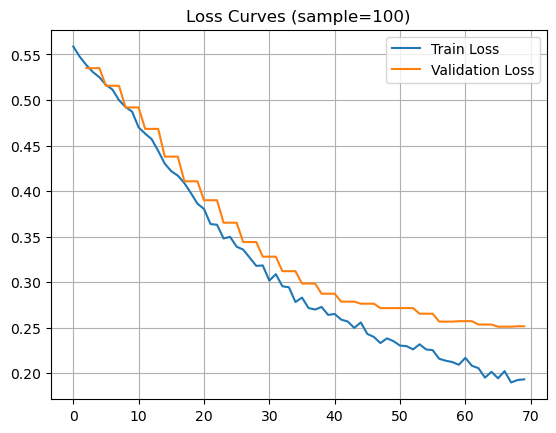

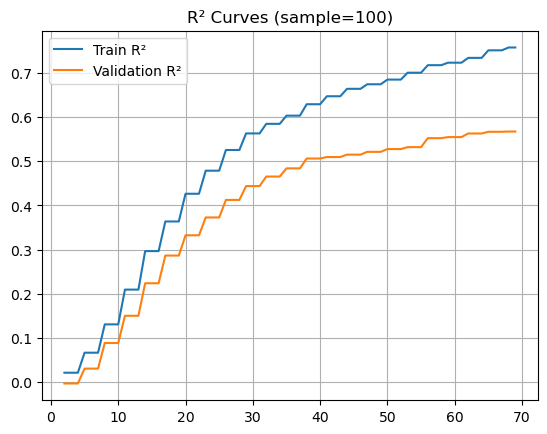

Loaded cached results for sample=500.


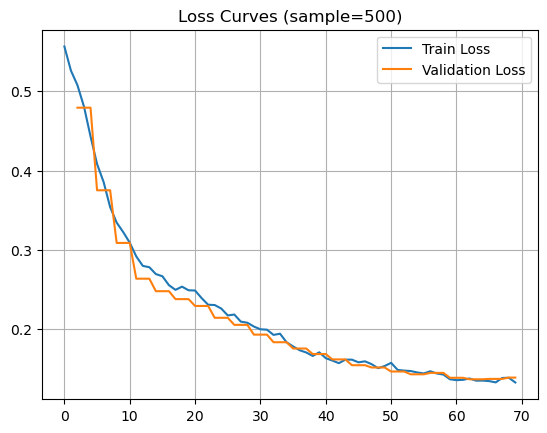

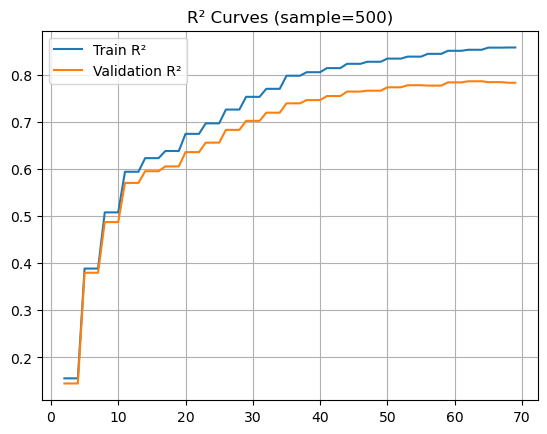

Loaded cached results for sample=1000.


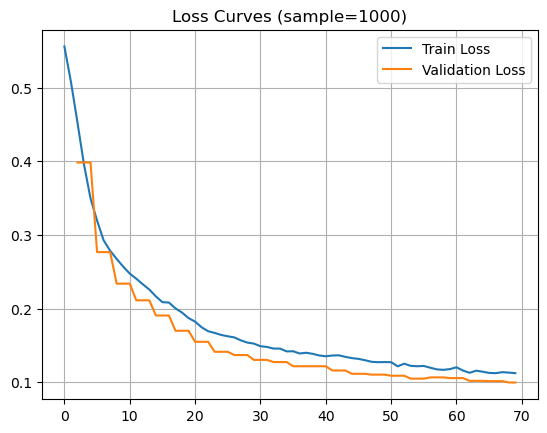

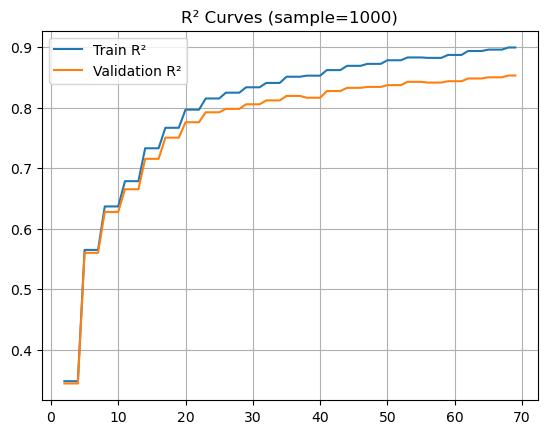

In [32]:
# check if R^2 validation scales with number of examples as my model learns more
# if it does scale, I can continue and make my final @test_and_train function

for sample in [100, 500, 1000]:

    cache_path = f"cached_data/gnn_kfold_sample_{sample}.pkl"

    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            results = pickle.load(f)
        print(f"Loaded cached results for sample={sample}.")
    else:
        results = KFoldCrossValidation(
            model_class=GNN,
            graph_dataset=graph_dataset[:sample],
            k=3,
            batch_size=100,
            epochs=70,
            hidden_dim=100,
            dropout=0.25,
            lr=9e-4,
            loss_type="smoothl1",
            beta=0.6,
            device=device,
            show_progress=False,
            verbose=False, # your eyes will bleed
            make_plots=False,  # disable the inside
            val_every=3,
            train_eval_every=3
        ) # R^2 val does scale with number of samples

        with open(cache_path, "wb") as f:
            pickle.dump(results, f)

        print(f"Saved cached results for sample={sample}.")

    # loss curves and r2 curves
    plt.figure()
    plt.plot(results["avg_train_losses"], label="Train Loss")
    plt.plot(results["avg_val_losses"], label="Validation Loss")
    plt.legend()
    plt.title(f"Loss Curves (sample={sample})")
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(results["avg_train_r2s"], label="Train R²")
    plt.plot(results["avg_val_r2s"], label="Validation R²")
    plt.legend()
    plt.title(f"R² Curves (sample={sample})")
    plt.grid(True)
    plt.show()

Loaded cached results for sample=100.


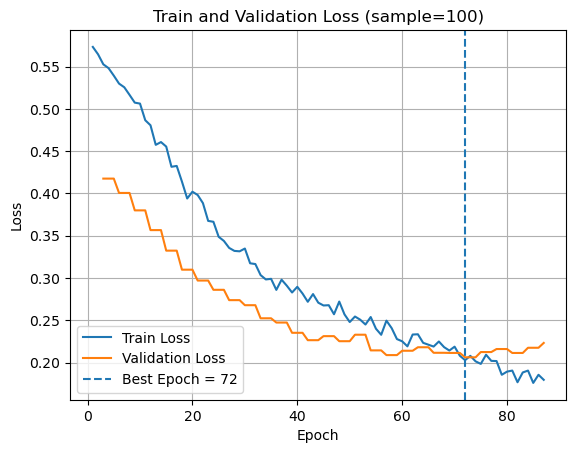

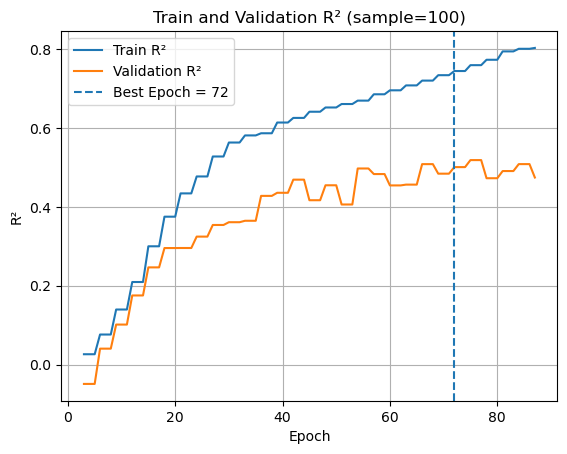

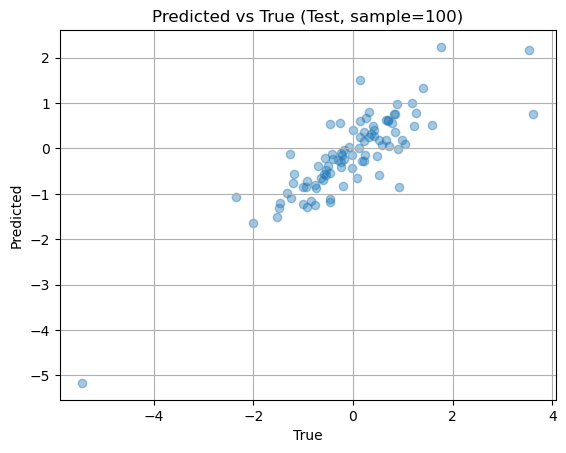

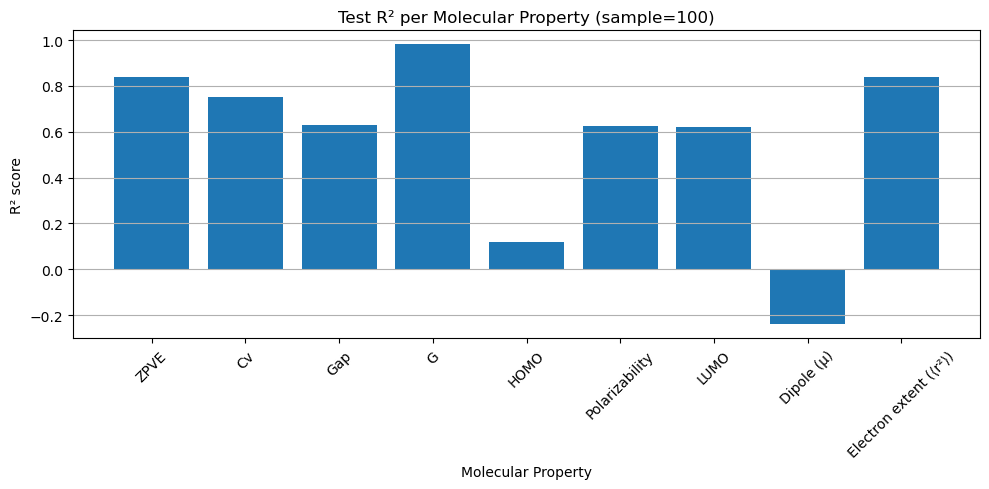

best_epoch: 72
train_r2: 0.7445
val_r2: 0.5009
test_r2: 0.5731

Loaded cached results for sample=500.


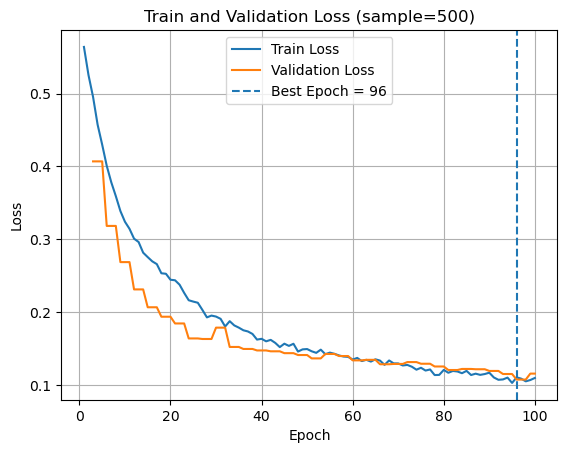

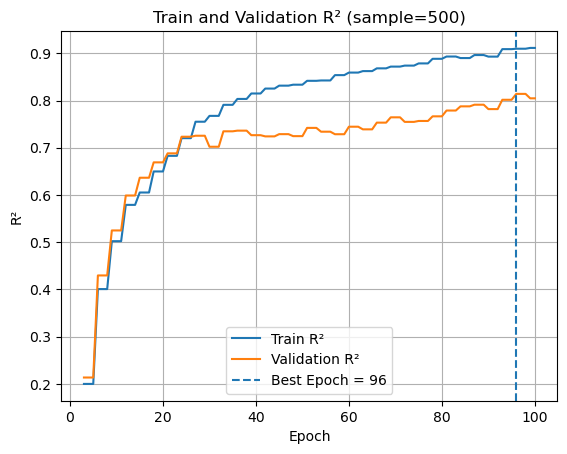

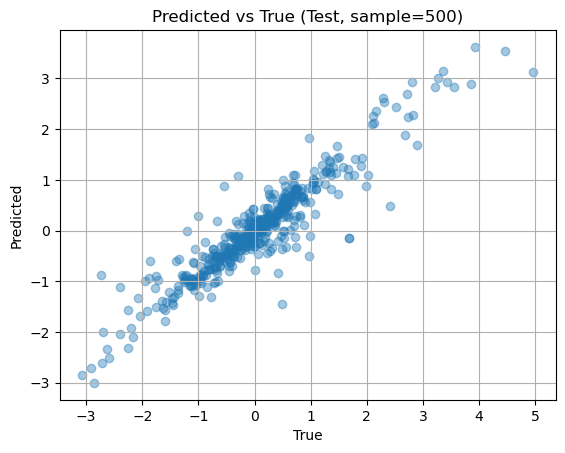

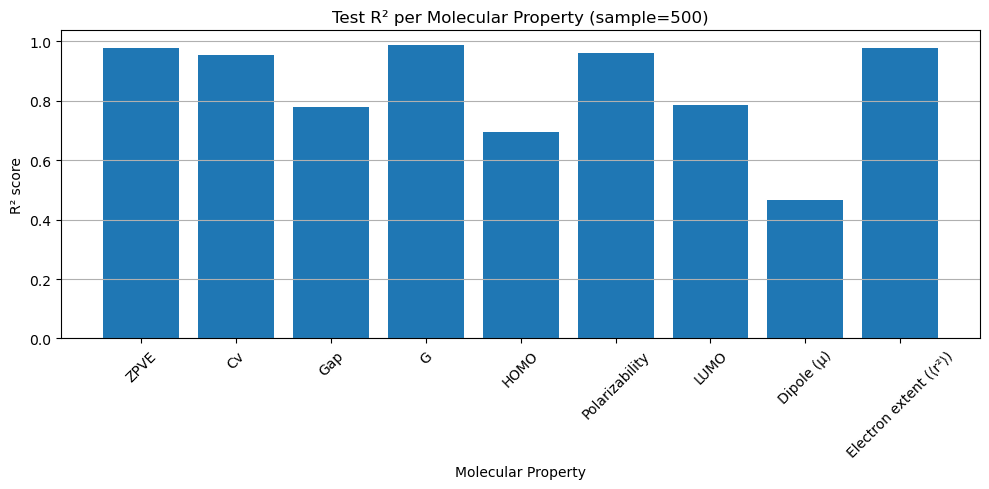

best_epoch: 96
train_r2: 0.9098
val_r2: 0.8141
test_r2: 0.8428

Loaded cached results for sample=1000.


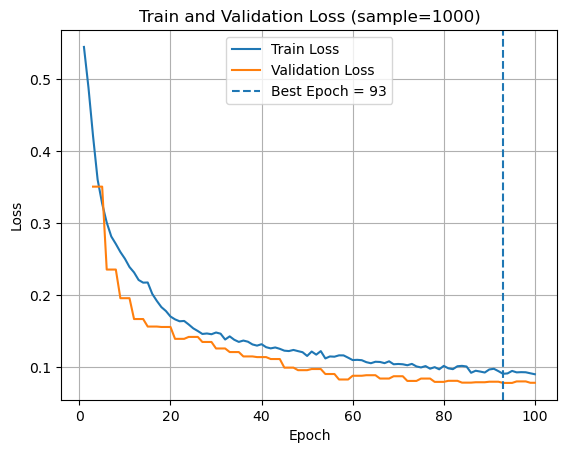

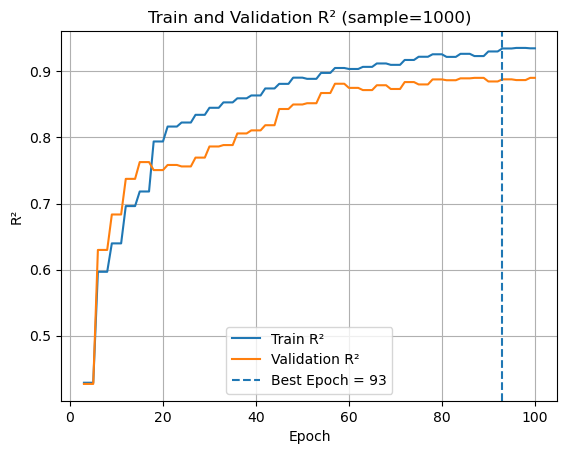

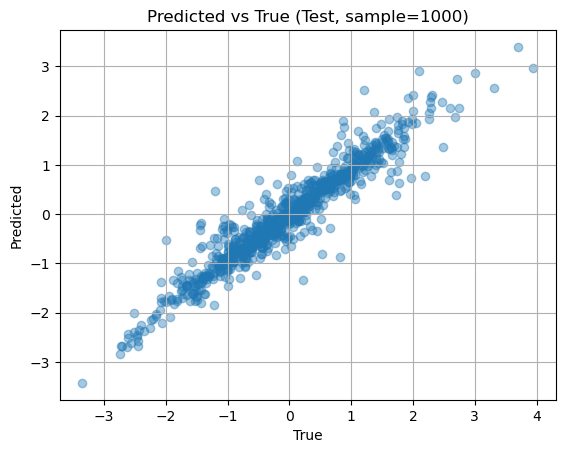

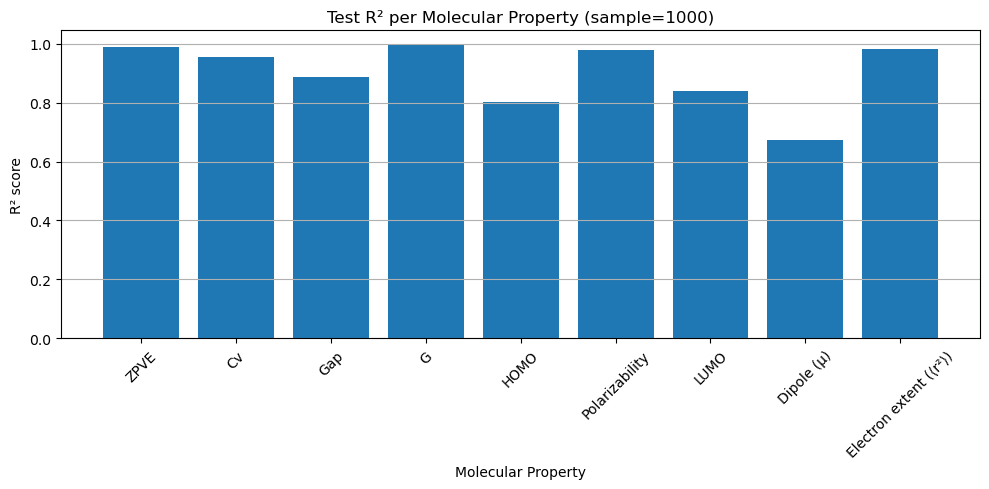

best_epoch: 93
train_r2: 0.9347
val_r2: 0.8880
test_r2: 0.9004



In [33]:
# testing if my final @train_and_test function works well
# using hyperparameters approximated above

import pickle
import io
import torch
import torch.storage

def load_pickle_cuda_to_cpu(path):
    # patch how PyTorch tensors inside pickle are rebuilt
    old_load_from_bytes = torch.storage._load_from_bytes

    try:
        torch.storage._load_from_bytes = lambda b: torch.load(
            io.BytesIO(b),
            map_location=torch.device("cpu"),
            weights_only=False
        )

        with open(path, "rb") as f:
            obj = pickle.load(f)

    finally:
        torch.storage._load_from_bytes = old_load_from_bytes

    return obj


for sample in [100, 500, 1000]:

    cache_path = f"cached_data/gnn_trainvaltest_{sample}_cuda.pkl"

    if os.path.exists(cache_path):
        results = load_pickle_cuda_to_cpu(cache_path)
        print(f"Loaded cached results for sample={sample}.")
    else:
        results = train_validate_test(
            model_class=GNN,
            graph_dataset=graph_dataset[:sample],
            test_size=0.1,
            val_size=0.1,
            batch_size=100,
            epochs=100,
            hidden_dim=100,
            dropout=0.25,
            lr=9e-4,
            loss_type="smoothl1",
            beta=0.6,
            device=device,
            random_state=67,
            show_progress=False,
            verbose=False,
            make_plots=False,   # disable internal plotting
            val_every=3,        # validate every 3 epochs
            train_eval_every=3, # also evaluate train r2 every 3 epochs
            early_stopping_patience_epochs=15,  # stop if val R² does not improve for ~15 epochs 
            min_delta=1e-4
        )

        with open(cache_path, "wb") as f:
            pickle.dump(results, f)

        print(f"Saved cached results for sample={sample}.")

    epochs_ran = len(results["train_losses"])

    # 1. train and validation loss
    plt.figure()
    plt.plot(range(1, epochs_ran + 1), results["train_losses"], label="Train Loss")
    plt.plot(range(1, epochs_ran + 1), results["val_losses"], label="Validation Loss")
    plt.axvline(results["best_epoch"], linestyle="--", label=f"Best Epoch = {results['best_epoch']}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train and Validation Loss (sample={sample})")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. train and validation R²
    plt.figure()
    plt.plot(range(1, epochs_ran + 1), results["train_r2s"], label="Train R²")
    plt.plot(range(1, epochs_ran + 1), results["val_r2s"], label="Validation R²")
    plt.axvline(results["best_epoch"], linestyle="--", label=f"Best Epoch = {results['best_epoch']}")
    plt.xlabel("Epoch")
    plt.ylabel("R²")
    plt.title(f"Train and Validation R² (sample={sample})")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 3. predicted vs true plot aka parity plot
    plt.figure()
    plt.scatter(
        results["test_targets"].flatten().numpy(),
        results["test_preds"].flatten().numpy(),
        alpha=0.4
    )
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"Predicted vs True (Test, sample={sample})")
    plt.grid(True)
    plt.show()

    # 4. per r2 property plot
    clean_property_names = [
        "ZPVE",
        "Cv",
        "Gap",
        "G",
        "HOMO",
        "Polarizability",
        "LUMO",
        "Dipole (μ)",
        "Electron extent (⟨r²⟩)"
    ]

    plt.figure(figsize=(10, 5))
    plt.bar(clean_property_names, results["test_r2_per_output"].cpu().numpy())
    plt.xlabel("Molecular Property")
    plt.ylabel("R² score")
    plt.title(f"Test R² per Molecular Property (sample={sample})")
    plt.xticks(rotation=45)
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

    print(f"best_epoch: {results['best_epoch']}")
    print(f"train_r2: {results['train_r2']:.4f}")
    print(f"val_r2: {results['val_r2']:.4f}")
    print(f"test_r2: {results['test_r2']:.4f}")
    print()

The model gets more accurate and scales better as we increase samples so it is learning from more data! We can continue to the next part which is the transformer.

### (3) Transformer Creation

The first transformer will use GNN derived information while the second other transformer will not and then we will compare if it performs better.

These transformations are mechanistically related and often differ only by directionality. 
Since the model is trained on reaction classification rather than synthesis planning, 
we merge inverse transformations (e.g., oxidation/reduction, protection/deprotection) 
to reduce label redundancy and improve class balance.

In [34]:
reaction_names = {
    1: "Heteroatom alkylation and arylation", # SN1/SN2
    2: "Acylation", # acylation is replacing R' of carbonyl
    3: "C-C bond formation", # grow carbon chain, pair w/ 4
    4: "Heterocycle formation", # grow rings
    5: "Protection", # pair w/ 6
    6: "Deprotection",
    7: "Reduction", # pair w/ 8 
    8: "Oxidation",
    9: "Functional Group Interconversion", # pair w/ 10, 2 
    10: "Functional Group Addition",
} # compress to 5 new classes

new_reaction_names = {
    1: "Heteroatom alkylation / arylation",
    2: "Functional group transformations (incl. acylation)",
    3: "C–C bond formation / ring formation",
    4: "Protection / deprotection",
    5: "Redox",
}

In [35]:
new_reaction_map = {
    1: 1,   # Heteroatom alkylation / arylation (keep)
    2: 2,   # Acylation
    9: 2,   # FGI
    10: 2,  # FGA
    3: 3,   # C–C bond formation
    4: 3,   # Heterocycle formation  ← merged into construction
    5: 4,   # Protection
    6: 4,   # Deprotection
    7: 5,   # Reduction
    8: 5,   # Oxidation
}

reaction_types_df["new_category"] = (
    reaction_types_df["category"].replace(new_reaction_map)
) # append onto df w/o losing the old one just in case

print(reaction_types_df["category"].value_counts(normalize = True).sort_index())
print(reaction_types_df["new_category"].value_counts(normalize = True).sort_index())

category
1     0.245899
2     0.305587
3     0.024804
4     0.017257
5     0.015178
6     0.215173
7     0.119404
8     0.020845
9     0.035112
10    0.000740
Name: proportion, dtype: float64
new_category
1    0.245899
2    0.341440
3    0.042061
4    0.230351
5    0.140249
Name: proportion, dtype: float64


Once we run the GNN model, we will need to then run the model to get the parameters from molecules we encounter in the USPTO dataset. The predictions will be then used as features to help the transformer perform the prediction for the reaction type being performed. Make these predictions with the GNN model and append them to the reaction_types_df as a list of the list of 9 properties. 

For example say 2 reactants and 1 product will add onto reaction_type_df two columns: reactant_preds and product_preds. The first will have two lists for the two molecules in the reactants, each list having the 9 features. The second will just have one list/molecule again with the 9 properties. 

In [36]:
class USPTOStructurePredictor:
    def __init__(self, model, featurizer, device="cpu", random_seed=67, unnormalize=False):

        # take in the trained GNN model used to predict molecular property vectors
        self.model = model
        self.model.eval() # eval mode, again

        # featurizer takes SMILES and turns to PyG graph
        self.featurizer = featurizer

        self.device = device
        self.random_seed = random_seed

        # control whether to undo normalization if I wanna predict some molecule or the other
        # but for this project do not unnormalize because these will be features in the transformer
        self.unnormalize = unnormalize  

        # cache the predictions so repeated molecules are not recomputed
        # the bottleneck is every molecule we approximate the geometry, so
        # if we can just pull up from repeat calculation should be slightly faster
        self.pred_cache = {}


    def smiles_to_graph_uspto(self, smiles):
        """
        Convert one USPTO SMILES molecule into a PyG graph.
        USPTO only gives SMILES, not 3D coordinates.

        Therefore, this function:
        1. Builds an RDKit molecule
        2. Adds hydrogens temporarily for conformer generation
        3. Generates approximate 3D coordinates
        4. Removes hydrogens again
        5. Builds a graph using the Alchemy featurizer
        """

        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None

        # Add Hs only to improve 3D conformer generation
        mol_h = Chem.AddHs(mol)

        # ETKDG gives a reasonable approximate 3D geometry from SMILES
        params = AllChem.ETKDGv3()

        params.randomSeed = self.random_seed
        try: embed_status = AllChem.EmbedMolecule(mol_h, params)
        except: return None

        # embedding failed
        if embed_status != 0: return None

        # try force-field optimization after embedding
        # MMFF is preferred for small organic molecules
        try:
            if AllChem.MMFFHasAllMoleculeParams(mol_h): AllChem.MMFFOptimizeMolecule(mol_h)
            elif AllChem.UFFHasAllMoleculeParams(mol_h): AllChem.UFFOptimizeMolecule(mol_h)
        except: pass

        # extract coordinates from H-containing molecule
        conf = mol_h.GetConformer()
        all_coords = [
            [
                conf.GetAtomPosition(i).x,
                conf.GetAtomPosition(i).y,
                conf.GetAtomPosition(i).z
            ]
            for i in range(mol_h.GetNumAtoms())
        ]

        # keep only heavy atom coordinates because original GNN graphs use heavy atoms
        heavy_idx = [
            i for i, atom in enumerate(mol_h.GetAtoms())
            if atom.GetAtomicNum() != 1
        ]

        coords = [all_coords[i] for i in heavy_idx]

        # dummy target is needed because smiles_to_graph_alchemy expects y
        # this y is not used during prediction
        y_dummy = [0.0] * len(self.featurizer.target_cols)

        # build graph using original heavy-atom SMILES and generated heavy-atom coords
        return self.featurizer.smiles_to_graph_alchemy(
            smiles,
            coords,
            y_dummy
        )

    @torch.no_grad()
    def predict_smiles(self, smiles):
        """
        Predict the GNN molecular property vector for one molecule SMILES.

        Returns:
            list of predicted values
            or None if graph generation fails
        """

        # easy cases to skip over
        if pd.isna(smiles): return None
        smiles = smiles.strip()
        if smiles == "": return None

        # use cached prediction if this molecule was already processed
        if smiles in self.pred_cache: return self.pred_cache[smiles]

        data = self.smiles_to_graph_uspto(smiles)

        # no graph then None it out
        if data is None:
            self.pred_cache[smiles] = None
            return None

        # single graph needs a batch vector of all zeros
        data.batch = torch.zeros(data.num_nodes, dtype=torch.long)

        # move graph tensors to device
        data = data.to(self.device)

        # forward pass through trained GNN
        pred = self.model(
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.graph_feat
        )

        pred = pred.reshape(1, -1).cpu()

        # for transformer features, keep normalized prediction values
        if self.unnormalize: pred = self.featurizer.unnormalize_y(pred)

        pred = pred.flatten().tolist()

        # store result so duplicate molecules are fast
        self.pred_cache[smiles] = pred

        return pred

    def get_structure_preds(self, smiles_string):
        """
        Predict structure vectors for all molecules in one reaction side.
        Example:
            "CCO.O=C=O" -> [prediction_for_CCO, prediction_for_CO2]

        Returns:
            list of predictions, one per molecule
        """
        if pd.isna(smiles_string): return []

        smiles_list = [s.strip() for s in smiles_string.split(".") if s.strip()]
        return [self.predict_smiles(smi) for smi in smiles_list]


    def get_reactant_structure_preds_from_row(self, row):
        return self.get_structure_preds(row["reactant"])


    def get_product_structure_preds_from_row(self, row):
        return self.get_structure_preds(row["product"])

    # tack it onto the dataframe
    def add_structure_preds_to_df(self, df, reactant_col="reactant", product_col="product"):
        df = df.copy()

        df["reactant_preds"] = [
            self.get_structure_preds(x)
            for x in tqdm(df[reactant_col], total=len(df))
        ]
        
        df["product_preds"] = [
            self.get_structure_preds(x)
            for x in tqdm(df[product_col], total=len(df))
        ]

        return df
    


In [37]:
def stratified_sample_df(df, n, random_state=67):
    # count samples per class
    class_counts = df["new_category"].value_counts()

    # smallest class size
    min_class_size = class_counts.min()

    # ensure each class can appear in both splits
    # need at least 2 per class
    if min_class_size < 2:
        raise ValueError("Each class must have at least 2 samples for stratification.")

    # max possible sample size that keeps at least 1 sample per class in remainder
    max_n = len(df) - len(class_counts)

    # also cannot sample more than (min_class_size - 1) per class proportionally
    # sklearn handles proportions, so we only clip global n
    n = min(n, max_n)

    df_sample, _ = train_test_split(
        df,
        train_size=n,
        stratify=df["new_category"],
        random_state=random_state,
        shuffle=True,
    )

    return df_sample.reset_index(drop=True)

def normalize_gnn_preds(df):
    vecs = []

    for col in ["reactant_preds", "product_preds"]:
        for preds in df[col]:
            if preds:
                for v in preds:
                    if v is not None:
                        vecs.append(torch.tensor(v, dtype=torch.float))

    vecs = torch.stack(vecs)
    mean = vecs.mean(dim=0)
    std = vecs.std(dim=0).clamp_min(1e-8)

    def norm(v):
        if v is None: return None
        return ((torch.tensor(v, dtype=torch.float) - mean) / std).tolist()

    for col in ["reactant_preds", "product_preds"]:
        df[col] = [
            [norm(v) for v in preds] if preds else preds
            for preds in df[col]
        ]

    return df

In [38]:
cache_path = "cached_data/transformer_subset_1000_with_gnn_normalized.pkl"

if os.path.exists(cache_path):
    with open(cache_path, "rb") as f:
        subset = pickle.load(f)
    print("Loaded cached normalized subset.")

else:
    structure_predictor = USPTOStructurePredictor(
        model=results["model"],
        featurizer=featurizer,
        device=device,
        unnormalize=False
    )

    subset = stratified_sample_df(reaction_types_df, n=1000)
    subset = structure_predictor.add_structure_preds_to_df(subset)
    subset = normalize_gnn_preds(subset)

    os.makedirs("cached_data", exist_ok=True)
    with open(cache_path, "wb") as f:
        pickle.dump(subset, f)

    print("Generated and cached normalized subset.")

# took 3m30s for 1k rxns so roughly 2 hrs for final dataset

Loaded cached normalized subset.


We can now get started with making the transformer herself. We will only have one transfomer model code with some boolean include_gnn_vec that will include our carefuly curated GNN data.

In [39]:
# special tokens that will be used in transformer
pad_token = "[PAD]"   # pad things out
unk_token = "[UNK]"   # unknown

cls_token = "[CLS]"   # classification token used for final pooled representation

react_mol_token = "[RMOL]"  # beginning of reactant molecule block
prod_mol_token = "[PMOL]"   # beginning of product molecule block
react_gnn_token = "[RGNN]"  # position where reactant GNN vector is inserted
prod_gnn_token = "[PGNN]"   # position where product GNN vector is inserted
sep_token = "[SEP]"         # separator between reactant side and product side


# group smiles as certain tokens
def tokenize_smiles(smi):
    """
    Tokenizes SMILES while preserving:
        1. Bracketed groups like [NH4+], [O-]
        2. Multicharacter atoms like Cl and Br
        3. Reaction arrow (>>)
        4. Ring closures (%10)
        5. Everything else as single-character tokens
    """
    tokens = []
    i = 0
    n = len(smi)

    while i < n:
        # preserve bracket groups like [NH4+]
        if smi[i] == "[":
            j = i + 1
            while j < n and smi[j] != "]":
                j += 1

            if j < n:
                tokens.append(smi[i:j + 1])
                i = j + 1
            else:
                tokens.append(smi[i])
                i += 1

        # preserve reaction arrow if it ever appears
        elif i + 1 < n and smi[i:i + 2] == ">>":
            tokens.append(">>")
            i += 2

        # preserve ring closures like %10
        elif i + 2 < n and smi[i] == "%" and smi[i + 1:i + 3].isdigit():
            tokens.append(smi[i:i + 3])
            i += 3

        # preserve two-character atoms
        elif i + 1 < n and smi[i:i + 2] in ["Cl", "Br"]:
            tokens.append(smi[i:i + 2])
            i += 2

        # everything else is single-character
        else:
            tokens.append(smi[i])
            i += 1

    return tokens


# helper function to make sure a GNN vector is valid
def clean_pred_vec(pred, dim=9):
    """
    Makes sure every GNN vector is length dim.
    If prediction is missing or broken, return zeros.
    """
    if pred is None: return [0.0] * dim

    if isinstance(pred, (list, tuple, np.ndarray)) and len(pred) == dim:
        out = []
        for x in pred:
            try:
                val = float(x)
                if np.isnan(val):
                    val = 0.0
            except Exception:
                val = 0.0
            out.append(val)
        return out

    return [0.0] * dim


# make sure the list of molecule predictions is actually a list
def ensure_prediction_list(preds):
    if preds is None: return []
    if isinstance(preds, list): return preds
    if isinstance(preds, tuple): return list(preds)
    return []


# build a mixed token sequence for one reaction
def build_reaction_tokens(
    reactant_smiles,
    product_smiles,
    reactant_preds=None,
    product_preds=None,
    include_gnn_vec=False,
    gnn_dim=9,
):
    """
    Builds one reaction sequence.
    SMILES-only:
        [CLS] [RMOL] A [RMOL] B [SEP] [PMOL] C
    GNN mode:
        [CLS] [RMOL] [RGNN] A [RMOL] [RGNN] B [SEP] [PMOL] [PGNN] C
    gnn_mask:
        1 only at [RGNN] or [PGNN] positions
        0 everywhere else
    gnn_values:
        real 9-dim GNN vector at [RGNN]/[PGNN]
        zero vector everywhere else
    """

    # split multi-molecule reaction sides
    reactant_parts = [s.strip() for s in str(reactant_smiles).split(".") if s.strip()]
    product_parts = [s.strip() for s in str(product_smiles).split(".") if s.strip()]

    if include_gnn_vec:
        reactant_preds = ensure_prediction_list(reactant_preds)
        product_preds = ensure_prediction_list(product_preds)

    tokens = []
    gnn_mask = []
    gnn_values = []

    # add CLS token at the beginning
    # transformer will use this position for final classification
    tokens.append(cls_token)
    gnn_mask.append(0)
    gnn_values.append([0.0] * gnn_dim)

    # reactant side
    for i, smi in enumerate(reactant_parts):

        # molecule boundary token
        tokens.append(react_mol_token)
        gnn_mask.append(0)
        gnn_values.append([0.0] * gnn_dim)

        # optional GNN vector token
        if include_gnn_vec:
            mol_pred = clean_pred_vec(
                reactant_preds[i] if i < len(reactant_preds) else None,
                dim=gnn_dim,
            )
            tokens.append(react_gnn_token)
            gnn_mask.append(1)
            gnn_values.append(mol_pred)

        # SMILES tokens
        for tok in tokenize_smiles(smi):
            tokens.append(tok)
            gnn_mask.append(0)
            gnn_values.append([0.0] * gnn_dim)

    # separator between reactants and products
    tokens.append(sep_token)
    gnn_mask.append(0)
    gnn_values.append([0.0] * gnn_dim)

    # product side
    for i, smi in enumerate(product_parts):

        # product molecule boundary token
        tokens.append(prod_mol_token)
        gnn_mask.append(0)
        gnn_values.append([0.0] * gnn_dim)

        # optional GNN vector token
        if include_gnn_vec:
            mol_pred = clean_pred_vec(
                product_preds[i] if i < len(product_preds) else None,
                dim=gnn_dim,
            )

            tokens.append(prod_gnn_token)
            gnn_mask.append(1)
            gnn_values.append(mol_pred)

        # product SMILES tokens
        for tok in tokenize_smiles(smi):
            tokens.append(tok)
            gnn_mask.append(0)
            gnn_values.append([0.0] * gnn_dim)

    return tokens, gnn_mask, gnn_values


# master class to build vocab and corresponding integer ids
class ReactionTokenizer:
    def __init__(self):
        # token2idx maps token string -> integer id
        self.token2idx = {
            pad_token: 0,
            unk_token: 1,
            cls_token: 2,
            react_mol_token: 3,
            prod_mol_token: 4,
            react_gnn_token: 5,
            prod_gnn_token: 6,
            sep_token: 7,
        }

        # idx2token maps integer id -> token string
        self.idx2token = {
            idx: tok
            for tok, idx in self.token2idx.items()
        }

    def add_token(self, token):
        # add token only if not already in vocab
        if token not in self.token2idx:
            idx = len(self.token2idx)
            self.token2idx[token] = idx
            self.idx2token[idx] = token

    def build_vocab(self, df):
        # build vocabulary from all reactant and product SMILES
        for _, row in df.iterrows():

            reactant_parts = [s.strip() for s in str(row["reactant"]).split(".") if s.strip()]
            product_parts = [s.strip() for s in str(row["product"]).split(".") if s.strip()]

            for smi in reactant_parts:
                for tok in tokenize_smiles(smi):
                    self.add_token(tok)

            for smi in product_parts:
                for tok in tokenize_smiles(smi):
                    self.add_token(tok)

    def encode_tokens(self, tokens):
        # convert token strings to integer ids
        unk_idx = self.token2idx[unk_token]
        return [self.token2idx.get(tok, unk_idx) for tok in tokens]

    def decode_ids(self, ids):
        # convert integer ids back to token strings
        return [self.idx2token.get(int(i), unk_token) for i in ids]

    @property
    def vocab_size(self):
        return len(self.token2idx)


# convert dataframe of reactions into something PyTorch can train on
class ReactionDataset(TorchDataset):
    def __init__(self, df, tokenizer, include_gnn_vec=False, gnn_dim=9, max_len=512):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.include_gnn_vec = include_gnn_vec
        self.gnn_dim = gnn_dim
        self.max_len = max_len

        # use new_category instead of category
        # new_category should be 1-7 after merged reaction classes
        self.labels = self.df["new_category"].tolist() if "new_category" in self.df.columns else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        tokens, gnn_mask, gnn_values = build_reaction_tokens(
            reactant_smiles=row["reactant"],
            product_smiles=row["product"],
            reactant_preds=row.get("reactant_preds", None),
            product_preds=row.get("product_preds", None),
            include_gnn_vec=self.include_gnn_vec,
            gnn_dim=self.gnn_dim,
        )

        # truncate long reactions to max_len
        # this prevents transformer from crashing on very long sequences
        tokens = tokens[:self.max_len]
        gnn_mask = gnn_mask[:self.max_len]
        gnn_values = gnn_values[:self.max_len]

        input_ids = torch.tensor(
            self.tokenizer.encode_tokens(tokens),
            dtype=torch.long,
        )

        # 1 means real token, 0 means padding
        attention_mask = torch.ones(len(tokens), dtype=torch.long)

        # true only at [RGNN] or [PGNN] positions
        gnn_mask = torch.tensor(gnn_mask, dtype=torch.bool)

        # per-token GNN value
        # zero vector except at GNN token positions
        gnn_values = torch.tensor(gnn_values, dtype=torch.float)

        item = {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "gnn_mask": gnn_mask,
            "gnn_values": gnn_values,
        }

        if self.labels is not None:
            # CrossEntropyLoss needs labels 0-6
            # dataframe has new_category 1-7
            label = torch.tensor(int(self.labels[idx]) - 1, dtype=torch.long)

            # safety check for merged 7-class task because keep getting error
            if label.item() < 0 or label.item() > 6:
                raise ValueError(f"Label must be in 0-6 after shift, got {label.item()}")

            item["label"] = label

        return item


# make sure batches are all the same sequence length
def reaction_collate_fn(batch):
    """
    Pads variable-length reaction sequences into one batch.
    """

    input_ids = [item["input_ids"] for item in batch]
    attention_mask = [item["attention_mask"] for item in batch]
    gnn_mask = [item["gnn_mask"] for item in batch]
    gnn_values = [item["gnn_values"] for item in batch]

    # pad token ids with [PAD] id = 0
    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=0)

    # pad attention mask with 0 so transformer ignores padding
    attention_mask = pad_sequence(attention_mask, batch_first=True, padding_value=0)

    # pad GNN mask with False
    gnn_mask = pad_sequence(gnn_mask, batch_first=True, padding_value=False)

    # pad GNN values with zero vectors
    gnn_values = pad_sequence(gnn_values, batch_first=True, padding_value=0.0)

    out = {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "gnn_mask": gnn_mask,
        "gnn_values": gnn_values,
    }

    # labels exist during training/evaluation, but not necessarily inference
    if "label" in batch[0]:
        out["label"] = torch.stack([item["label"] for item in batch])

    return out


# positional encoder or else OCN and NCO can look too similar
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=512):
        super().__init__()

        self.dropout = nn.Dropout(dropout)

        # initialize positional encoding matrix
        pe = torch.zeros(max_len, d_model)

        # position index: 0, 1, 2, ...
        position = torch.arange(max_len).unsqueeze(1).float()

        # frequency scaling for sine/cosine waves
        frequency = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        # even dimensions use sine
        pe[:, 0::2] = torch.sin(position * frequency)

        # odd dimensions use cosine
        pe[:, 1::2] = torch.cos(position * frequency)

        # add batch dimension
        pe = pe.unsqueeze(0)

        # register_buffer means pe moves with model.to(device), but is not trained
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x shape: [batch, seq_len, d_model]
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# transformer classifier for reaction category prediction
class ReactionTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_classes=5,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.1,
        max_len=512,
        gnn_dim=9,
        include_gnn_vec=False,
    ):
        super().__init__()

        self.include_gnn_vec = include_gnn_vec

        # token embeddings
        self.token_embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=0
        )

        # positional encoding gives order information
        self.positional_encoding = PositionalEncoding(
            d_model,
            dropout=dropout,
            max_len=max_len
        )

        # project 9-dim GNN vector into transformer embedding size
        self.gnn_projection = nn.Sequential(
            nn.Linear(gnn_dim, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )

        # transformer encoder block
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            enable_nested_tensor=False,
        )

        # final classifier outputs logits for 7 merged classes
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, input_ids, attention_mask, gnn_mask=None, gnn_values=None):

        # token embeddings
        x = self.token_embedding(input_ids)

        # if using GNN vectors, add them onto [RGNN]/[PGNN] token embeddings
        # IMPORTANT:
        # this preserves whether the token is [RGNN] or [PGNN]
        # replacing x entirely would erase that token identity
        if self.include_gnn_vec and gnn_mask is not None and gnn_values is not None:
            gnn_emb = self.gnn_projection(gnn_values)
            x = torch.where(
                gnn_mask.unsqueeze(-1),
                x + gnn_emb,
                x
            )

        # add position information
        x = self.positional_encoding(x)

        # True means "ignore this token"
        key_padding_mask = (attention_mask == 0)

        # transformer encoder
        x = self.encoder(x, src_key_padding_mask=key_padding_mask)

        # use [CLS] token output for classification
        # because [CLS] is always the first token
        pooled = x[:, 0, :]

        logits = self.classifier(pooled)
        return logits


# trainer for transformer classification
class TransformerTrainer:
    def __init__(
        self,
        model,
        optimizer=torch.optim.Adam,
        lr=1e-3,
        device="cpu",
        class_weights=None,
    ):
        super().__init__()

        self.model = model.to(device)
        self.device = device
        self.optimizer = optimizer(self.model.parameters(), lr=lr)

        # class_weights helps with class imbalance
        if class_weights is not None:
            class_weights = class_weights.to(device)

        # multiclass classification loss
        self.loss_function = nn.CrossEntropyLoss(weight=class_weights)

    def train_one_epoch(self, loader):
        # training mode turns dropout on
        self.model.train()

        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for batch in loader:

            # move batch tensors to device
            input_ids = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            gnn_mask = batch["gnn_mask"].to(self.device)
            gnn_values = batch["gnn_values"].to(self.device)
            labels = batch["label"].to(self.device).long()

            # clear old gradients
            self.optimizer.zero_grad()

            # forward pass
            logits = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                gnn_mask=gnn_mask,
                gnn_values=gnn_values,
            )

            # compute classification loss
            loss = self.loss_function(logits, labels)

            # update model weights
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

            # compute accuracy
            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == labels).sum().item()
            total_count += labels.size(0)

        avg_loss = total_loss / len(loader)
        avg_acc = total_correct / total_count

        return avg_loss, avg_acc

    @torch.no_grad()
    def evaluate(self, loader):
        # eval mode turns dropout off
        self.model.eval()

        total_loss = 0.0
        total_correct = 0
        total_count = 0

        all_preds = []
        all_labels = []

        for batch in loader:

            input_ids = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            gnn_mask = batch["gnn_mask"].to(self.device)
            gnn_values = batch["gnn_values"].to(self.device)
            labels = batch["label"].to(self.device).long()

            logits = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                gnn_mask=gnn_mask,
                gnn_values=gnn_values,
            )

            loss = self.loss_function(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == labels).sum().item()
            total_count += labels.size(0)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

        avg_loss = total_loss / len(loader)
        avg_acc = total_correct / total_count

        all_preds = torch.cat(all_preds, dim=0)
        all_labels = torch.cat(all_labels, dim=0)

        # macro F1 is important because reaction classes are imbalanced
        avg_f1 = f1_score(
            all_labels.numpy(),
            all_preds.numpy(),
            average="macro",
            zero_division=0,
        )

        return avg_loss, avg_acc, avg_f1, all_preds, all_labels

    def fit(self, train_loader, val_loader, epochs=20, show_progress=True):
        train_losses = []
        val_losses = []
        train_accs = []
        val_accs = []
        val_f1s = []

        best_val_loss = float("inf")
        best_train_loss = None
        best_train_acc = None
        best_val_acc = None
        best_val_f1 = None

        for epoch in range(1, epochs + 1):

            # train one epoch
            train_loss, train_acc = self.train_one_epoch(train_loader)

            # evaluate validation set
            val_loss, val_acc, val_f1, _, _ = self.evaluate(val_loader)

            # store curves
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)
            val_f1s.append(val_f1)

            # save best epoch metrics based on validation loss
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_train_loss = train_loss
                best_train_acc = train_acc
                best_val_acc = val_acc
                best_val_f1 = val_f1

            if show_progress:
                print(
                    f"Epoch {epoch}: "
                    f"train_loss={train_loss:.4f}, "
                    f"train_acc={train_acc:.4f}, "
                    f"val_loss={val_loss:.4f}, "
                    f"val_acc={val_acc:.4f}, "
                    f"val_f1={val_f1:.4f}"
                )

        return {
            "best_train_loss": best_train_loss,
            "best_val_loss": best_val_loss,
            "best_train_acc": best_train_acc,
            "best_val_acc": best_val_acc,
            "best_val_f1": best_val_f1,

            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accs": train_accs,
            "val_accs": val_accs,
            "val_f1s": val_f1s,
        }

In [40]:
# This is structured like the GNN functions, but changed for transformer classification
# Main metric: accuracy / macro-F1
# Early stopping/checkpointing: validation loss


# train one transformer on one train/validation split
def train_single_split_transformer(
    model_class,
    train_df,
    val_df,
    tokenizer,
    include_gnn_vec=False,
    batch_size=32,
    epochs=20,
    optimizer=torch.optim.Adam,
    lr=1e-3,
    device="cpu",
    show_progress=False,
    val_every=1,
    train_eval_every=1,
    model_kwargs=None,
    use_class_weights=False,
    use_weighted_sampling=True,
    gnn_dim=9,
    class_col="new_category",
    min_delta=1e-4,
):
    """
    Train one transformer on one train/validation split.

    Used by KFoldCrossValidationTransformer.
    This function:
        1. builds datasets/loaders
        2. builds transformer model
        3. trains for fixed epochs
        4. saves best checkpoint based on validation loss
        5. returns metrics + validation predictions for confusion matrix
    """

    if model_kwargs is None: model_kwargs = {}

    # build datasets
    train_dataset = ReactionDataset(
        train_df,
        tokenizer,
        include_gnn_vec=include_gnn_vec,
        gnn_dim=gnn_dim
    )

    val_dataset = ReactionDataset(
        val_df,
        tokenizer,
        include_gnn_vec=include_gnn_vec,
        gnn_dim=gnn_dim
    )

    # weighted sampling handles class imbalance by sampling rare classes more often
    if use_weighted_sampling:

        # count how many examples exist in each merged class
        class_counts = train_df[class_col].value_counts().sort_index()

        # rare classes get larger sampling weights
        class_weights_for_sampling = 1.0 / class_counts

        # assign each training row a sampling weight based on its class
        sample_weights = train_df[class_col].map(class_weights_for_sampling).values

        sampler = WeightedRandomSampler(
            weights=torch.tensor(sample_weights, dtype=torch.float),
            num_samples=len(sample_weights),
            replacement=True
        )

        train_loader = TorchDataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            collate_fn=reaction_collate_fn
        )

    else:
        train_loader = TorchDataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            collate_fn=reaction_collate_fn
        )

    # validation loader does not need shuffling
    val_loader = TorchDataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=reaction_collate_fn
    )

    # number of classes should be 5 after merging
    num_classes = train_df[class_col].nunique()

    # build model
    model = model_class(
        vocab_size=tokenizer.vocab_size,
        num_classes=num_classes,
        include_gnn_vec=include_gnn_vec,
        gnn_dim=gnn_dim,
        **model_kwargs
    )

    # optional class weights for CrossEntropyLoss
    # NOTE: not usually use both class_weights and weighted_sampling unless needed
    # will introduce alot of noise in the model if both used
    class_weights = None

    if use_class_weights:
        classes = np.sort(train_df[class_col].unique())

        weights = compute_class_weight(
            class_weight="balanced",
            classes=classes,
            y=train_df[class_col].values
        )

        class_weights = torch.tensor(weights, dtype=torch.float)

    # trainer wraps train/eval logic
    trainer = TransformerTrainer(
        model=model,
        optimizer=optimizer,
        lr=lr,
        device=device,
        class_weights=class_weights
    )

    model = trainer.model.to(device)

    # tracking curves
    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    train_f1s = []
    val_f1s = []

    # best checkpoint tracking based on validation loss
    best_val_loss = float("inf")
    best_train_loss = None

    best_train_acc = None
    best_train_f1 = None

    best_val_acc = None
    best_val_f1 = None

    best_state_dict = None

    # best validation predictions for confusion matrix
    best_val_preds = None
    best_val_labels = None

    # carry-forward values for skipped evaluation epochs
    last_train_acc = np.nan
    last_train_f1 = np.nan

    last_val_loss = np.nan
    last_val_acc = np.nan
    last_val_f1 = np.nan

    for epoch in range(1, epochs + 1):

        # train one epoch
        train_loss, _ = trainer.train_one_epoch(train_loader)
        train_losses.append(train_loss)

        # evaluate train set only every train_eval_every epochs
        if epoch % train_eval_every == 0:
            _, last_train_acc, last_train_f1, _, _ = trainer.evaluate(train_loader)

        train_accs.append(last_train_acc)
        train_f1s.append(last_train_f1)

        # evaluate validation set only every val_every epochs
        if epoch % val_every == 0:
            val_loss, val_acc, val_f1, val_preds, val_labels = trainer.evaluate(val_loader)

            last_val_loss = val_loss
            last_val_acc = val_acc
            last_val_f1 = val_f1

            # improvement means validation loss decreased meaningfully
            # just like before
            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss

                best_train_loss = train_loss
                best_train_acc = last_train_acc
                best_train_f1 = last_train_f1

                best_val_acc = val_acc
                best_val_f1 = val_f1

                # save best model weights
                best_state_dict = copy.deepcopy(model.state_dict())

                # save predictions from best validation-loss epoch
                best_val_preds = val_preds
                best_val_labels = val_labels

        val_losses.append(last_val_loss)
        val_accs.append(last_val_acc)
        val_f1s.append(last_val_f1)

        if show_progress:
            train_acc_str = f"{last_train_acc:.4f}" if not np.isnan(last_train_acc) else "nan"
            train_f1_str = f"{last_train_f1:.4f}" if not np.isnan(last_train_f1) else "nan"
            val_loss_str = f"{last_val_loss:.4f}" if not np.isnan(last_val_loss) else "nan"
            val_acc_str = f"{last_val_acc:.4f}" if not np.isnan(last_val_acc) else "nan"
            val_f1_str = f"{last_val_f1:.4f}" if not np.isnan(last_val_f1) else "nan"

            print(
                f"Epoch {epoch}: "
                f"train_loss={train_loss:.4f}, "
                f"train_acc={train_acc_str}, "
                f"train_f1={train_f1_str}, "
                f"val_loss={val_loss_str}, "
                f"val_acc={val_acc_str}, "
                f"val_f1={val_f1_str}"
            )

    # safety fallback in case validation never ran
    if best_state_dict is None:
        best_state_dict = copy.deepcopy(model.state_dict())
        _, _, _, best_val_preds, best_val_labels = trainer.evaluate(val_loader)

    # reload best model based on validation loss
    model.load_state_dict(best_state_dict)
    model.eval()

    return {
        "model": model,

        "best_train_loss": best_train_loss,
        "best_val_loss": best_val_loss,

        "best_train_acc": best_train_acc,
        "best_train_f1": best_train_f1,

        "best_val_acc": best_val_acc,
        "best_val_f1": best_val_f1,

        "train_losses": train_losses,
        "val_losses": val_losses,

        "train_accs": train_accs,
        "val_accs": val_accs,

        "train_f1s": train_f1s,
        "val_f1s": val_f1s,

        "val_preds": best_val_preds,
        "val_labels": best_val_labels,
    }


# replace regression R^2 with classification accuracy / macro-F1
# used to see if the transformer is stable across splits
def KFoldCrossValidationTransformer(
    model_class,
    df,
    tokenizer,
    include_gnn_vec=False,
    k=3,
    batch_size=32,
    epochs=20,
    optimizer=torch.optim.Adam,
    lr=1e-3,
    device="cpu",
    early_break=False,
    show_progress=False,
    make_plots=True,
    verbose=True,
    random_state=67,
    val_every=1,
    train_eval_every=1,
    model_kwargs=None,
    use_class_weights=False,
    use_weighted_sampling=True,
    gnn_dim=9,
    class_col="new_category",
    min_delta=1e-4,
):
    """
    Run either:
        k=1: one stratified train/validation split
        k>1: stratified k-fold cross validation

    Used for hyperparameter comparison.
    Does not return a final production model.
    """

    if model_kwargs is None:
        model_kwargs = {}

    df = df.reset_index(drop=True)

    # k=1 is faster debugging for me 
    if k == 1:
        train_df, val_df = train_test_split(
            df,
            test_size=0.2,
            random_state=random_state,
            shuffle=True,
            stratify=df[class_col]
        )

        splits = [(train_df.index.tolist(), val_df.index.tolist())]

    # k>1 is real stratified k-fold
    else:
        kf = StratifiedKFold(
            n_splits=k,
            shuffle=True,
            random_state=random_state
        )

        splits = kf.split(df, df[class_col])

    # one best metric per fold
    train_loss_list = []
    val_loss_list = []

    train_acc_list = []
    val_acc_list = []

    train_f1_list = []
    val_f1_list = []

    # full curves from each fold
    all_train_losses = []
    all_val_losses = []

    all_train_accs = []
    all_val_accs = []

    all_train_f1s = []
    all_val_f1s = []

    # for combined confusion matrix across folds
    all_val_preds = []
    all_val_labels = []

    for fold, (train_idx, val_idx) in enumerate(splits):

        # split dataframe into this fold's train/val sets
        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df = df.iloc[val_idx].reset_index(drop=True)

        # train one transformer on this fold
        fold_results = train_single_split_transformer(
            model_class=model_class,
            train_df=train_df,
            val_df=val_df,
            tokenizer=tokenizer,
            include_gnn_vec=include_gnn_vec,
            batch_size=batch_size,
            epochs=epochs,
            optimizer=optimizer,
            lr=lr,
            device=device,
            show_progress=show_progress,
            val_every=val_every,
            train_eval_every=train_eval_every,
            model_kwargs=model_kwargs,
            use_class_weights=use_class_weights,
            use_weighted_sampling=use_weighted_sampling,
            gnn_dim=gnn_dim,
            class_col=class_col,
            min_delta=min_delta,
        )

        # pull best fold metrics
        train_loss_best = fold_results["best_train_loss"]
        val_loss_best = fold_results["best_val_loss"]

        train_acc_best = fold_results["best_train_acc"]
        train_f1_best = fold_results["best_train_f1"]

        val_acc_best = fold_results["best_val_acc"]
        val_f1_best = fold_results["best_val_f1"]

        # store best numbers from this fold
        train_loss_list.append(train_loss_best)
        val_loss_list.append(val_loss_best)

        train_acc_list.append(train_acc_best)
        train_f1_list.append(train_f1_best)

        val_acc_list.append(val_acc_best)
        val_f1_list.append(val_f1_best)

        # store full curves
        all_train_losses.append(fold_results["train_losses"])
        all_val_losses.append(fold_results["val_losses"])

        all_train_accs.append(fold_results["train_accs"])
        all_val_accs.append(fold_results["val_accs"])

        all_train_f1s.append(fold_results["train_f1s"])
        all_val_f1s.append(fold_results["val_f1s"])

        # store predictions for combined confusion matrix
        all_val_preds.append(fold_results["val_preds"])
        all_val_labels.append(fold_results["val_labels"])

        if verbose:
            print(f"\nFold {fold + 1}")
            print(f"Best train loss: {train_loss_best:.4f}")
            print(f"Best val loss: {val_loss_best:.4f}")
            print(f"Best train acc: {train_acc_best:.4f}")
            print(f"Best train f1: {train_f1_best:.4f}")
            print(f"Best val acc: {val_acc_best:.4f}")
            print(f"Best val f1: {val_f1_best:.4f}")

        # debugging: only run first fold
        if early_break: break

    # average curves across folds
    avg_train_losses = np.nanmean(np.array(all_train_losses), axis=0)
    avg_val_losses = np.nanmean(np.array(all_val_losses), axis=0)

    avg_train_accs = np.nanmean(np.array(all_train_accs), axis=0)
    avg_val_accs = np.nanmean(np.array(all_val_accs), axis=0)

    avg_train_f1s = np.nanmean(np.array(all_train_f1s), axis=0)
    avg_val_f1s = np.nanmean(np.array(all_val_f1s), axis=0)

    # combine fold-level validation predictions
    all_val_preds = torch.cat(all_val_preds, dim=0)
    all_val_labels = torch.cat(all_val_labels, dim=0)

    if make_plots:
        plt.figure()
        plt.plot(avg_train_losses, label="Average Train Loss")
        plt.plot(avg_val_losses, label="Average Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss Curves")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure()
        plt.plot(avg_train_accs, label="Train Accuracy")
        plt.plot(avg_val_accs, label="Validation Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Train vs Validation Accuracy")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure()
        plt.plot(avg_train_f1s, label="Train Macro-F1")
        plt.plot(avg_val_f1s, label="Validation Macro-F1")
        plt.xlabel("Epoch")
        plt.ylabel("Macro-F1")
        plt.title("Train vs Validation Macro-F1")
        plt.legend()
        plt.grid(True)
        plt.show()

        # normalized confusion matrix across all validation folds
        cm = confusion_matrix(
            all_val_labels.numpy(),
            all_val_preds.numpy(),
            normalize="true"
        )

        plt.figure(figsize=(8, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues", values_format=".2f")
        plt.title("K-Fold Validation Confusion Matrix")
        plt.grid(False)
        plt.show()

    summary = {
        "hyperparameters": {
            "k": k,
            "batch_size": batch_size,
            "epochs": epochs,
            "optimizer": optimizer.__name__ if hasattr(optimizer, "__name__") else str(optimizer),
            "lr": lr,
            "device": device,
            "random_state": random_state,
            "include_gnn_vec": include_gnn_vec,
            "val_every": val_every,
            "train_eval_every": train_eval_every,
            "model_kwargs": model_kwargs,
            "use_class_weights": use_class_weights,
            "use_weighted_sampling": use_weighted_sampling,
            "gnn_dim": gnn_dim,
            "class_col": class_col,
            "min_delta": min_delta,
        },

        "mean_train_loss": float(np.nanmean(train_loss_list)),
        "std_train_loss": float(np.nanstd(train_loss_list)),
        "mean_val_loss": float(np.nanmean(val_loss_list)),
        "std_val_loss": float(np.nanstd(val_loss_list)),

        "mean_train_acc": float(np.nanmean(train_acc_list)),
        "std_train_acc": float(np.nanstd(train_acc_list)),
        "mean_val_acc": float(np.nanmean(val_acc_list)),
        "std_val_acc": float(np.nanstd(val_acc_list)),

        "mean_train_f1": float(np.nanmean(train_f1_list)),
        "std_train_f1": float(np.nanstd(train_f1_list)),
        "mean_val_f1": float(np.nanmean(val_f1_list)),
        "std_val_f1": float(np.nanstd(val_f1_list)),

        "train_loss_per_fold": train_loss_list,
        "val_loss_per_fold": val_loss_list,

        "train_acc_per_fold": train_acc_list,
        "val_acc_per_fold": val_acc_list,

        "train_f1_per_fold": train_f1_list,
        "val_f1_per_fold": val_f1_list,

        "avg_train_losses": avg_train_losses,
        "avg_val_losses": avg_val_losses,

        "avg_train_accs": avg_train_accs,
        "avg_val_accs": avg_val_accs,

        "avg_train_f1s": avg_train_f1s,
        "avg_val_f1s": avg_val_f1s,

        "val_preds": all_val_preds,
        "val_labels": all_val_labels,
    }

    if make_plots:
        print("\nFinal results:")
        print(f"Train loss: {summary['mean_train_loss']:.4f} ± {summary['std_train_loss']:.4f}")
        print(f"Val loss: {summary['mean_val_loss']:.4f} ± {summary['std_val_loss']:.4f}")
        print(f"Train acc: {summary['mean_train_acc']:.4f} ± {summary['std_train_acc']:.4f}")
        print(f"Val acc: {summary['mean_val_acc']:.4f} ± {summary['std_val_acc']:.4f}")
        print(f"Train f1: {summary['mean_train_f1']:.4f} ± {summary['std_train_f1']:.4f}")
        print(f"Val f1: {summary['mean_val_f1']:.4f} ± {summary['std_val_f1']:.4f}")

    return summary


# final function to train/val/test on the whole reaction dataset
def train_validate_test_transformer(
    model_class,
    df,
    tokenizer,
    include_gnn_vec=False,
    test_size=0.1,
    val_size=0.1,
    batch_size=32,
    epochs=20,
    optimizer=torch.optim.Adam,
    lr=1e-3,
    device="cpu",
    random_state=67,
    show_progress=False,
    verbose=True,
    make_plots=True,
    val_every=1,
    train_eval_every=1,
    early_stopping_patience_epochs=15,
    min_delta=1e-4,

    model_kwargs=None,
    use_class_weights=False,
    use_weighted_sampling=True,
    gnn_dim=9,
    class_col="new_category",
):
    """
    Final transformer training/evaluation function.

    This function:
        1. splits data into train / validation / test
        2. trains transformer on train set
        3. tracks validation loss
        4. stops early if validation loss stops improving
        5. reloads best validation-loss checkpoint
        6. evaluates final model on train / validation / test
    """

    if model_kwargs is None: model_kwargs = {}

    df = df.reset_index(drop=True)

    # first split: hold out final test set
    train_pool_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        shuffle=True,
        stratify=df[class_col]
    )

    # second split: split remaining data into train and validation
    adjusted_val_size = val_size / (1 - test_size)

    train_df, val_df = train_test_split(
        train_pool_df,
        test_size=adjusted_val_size,
        random_state=random_state,
        shuffle=True,
        stratify=train_pool_df[class_col]
    )

    # build datasets
    train_dataset = ReactionDataset(
        train_df,
        tokenizer,
        include_gnn_vec=include_gnn_vec,
        gnn_dim=gnn_dim
    )

    val_dataset = ReactionDataset(
        val_df,
        tokenizer,
        include_gnn_vec=include_gnn_vec,
        gnn_dim=gnn_dim
    )

    test_dataset = ReactionDataset(
        test_df,
        tokenizer,
        include_gnn_vec=include_gnn_vec,
        gnn_dim=gnn_dim
    )

    # weighted sampling makes rare classes appear more often during training
    if use_weighted_sampling:
        class_counts = train_df[class_col].value_counts().sort_index()
        class_weights_for_sampling = 1.0 / class_counts
        sample_weights = train_df[class_col].map(class_weights_for_sampling).values

        sampler = WeightedRandomSampler(
            weights=torch.tensor(sample_weights, dtype=torch.float),
            num_samples=len(sample_weights),
            replacement=True
        )

        train_loader = TorchDataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            collate_fn=reaction_collate_fn
        )

    else:
        train_loader = TorchDataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            collate_fn=reaction_collate_fn
        )

    # validation and test loaders are only for evaluation, so no shuffle
    val_loader = TorchDataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=reaction_collate_fn
    )

    test_loader = TorchDataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=reaction_collate_fn
    )

    # number of output classes after merging should be 5
    num_classes = df[class_col].nunique()

    # build transformer model
    model = model_class(
        vocab_size=tokenizer.vocab_size,
        num_classes=num_classes,
        include_gnn_vec=include_gnn_vec,
        gnn_dim=gnn_dim,
        **model_kwargs
    )

    # optional class weights for CrossEntropyLoss
    # usually do not need both class weights and weighted sampling
    # both will inject alot of uncertainity
    class_weights = None

    if use_class_weights:
        classes = np.sort(train_df[class_col].unique())

        weights = compute_class_weight(
            class_weight="balanced",
            classes=classes,
            y=train_df[class_col].values
        )

        class_weights = torch.tensor(weights, dtype=torch.float)

    # trainer handles training and evaluation loops
    trainer = TransformerTrainer(
        model=model,
        optimizer=optimizer,
        lr=lr,
        device=device,
        class_weights=class_weights
    )

    model = trainer.model.to(device)

    # metric curves for plotting
    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    train_f1s = []
    val_f1s = []

    # best checkpoint tracking based on validation loss
    best_val_loss = float("inf")
    best_epoch = None
    best_state_dict = None

    # carry-forward values for skipped evaluation epochs
    last_train_acc = np.nan
    last_train_f1 = np.nan

    last_val_loss = np.nan
    last_val_acc = np.nan
    last_val_f1 = np.nan

    # patience is counted in validation checks, not raw epochs
    # example: val_every=5, patience=15 -> 3 validation checks
    patience_checks = max(1, early_stopping_patience_epochs // val_every)
    no_improve_count = 0

    # training loop
    for epoch in range(1, epochs + 1):

        # update model weights using one full train epoch
        train_loss, _ = trainer.train_one_epoch(train_loader)
        train_losses.append(train_loss)

        # train evaluation can be expensive, so only run every few epochs
        if epoch % train_eval_every == 0:
            _, last_train_acc, last_train_f1, _, _ = trainer.evaluate(train_loader)

        train_accs.append(last_train_acc)
        train_f1s.append(last_train_f1)

        # validation controls checkpointing and early stopping
        if epoch % val_every == 0:
            last_val_loss, last_val_acc, last_val_f1, _, _ = trainer.evaluate(val_loader)

            # improvement means validation loss decreased by at least min_delta
            if last_val_loss < best_val_loss - min_delta:
                best_val_loss = last_val_loss
                best_epoch = epoch

                # save best weights
                best_state_dict = copy.deepcopy(model.state_dict())

                # reset patience
                no_improve_count = 0

            else:
                # val loss increased or stayed basically flat
                no_improve_count += 1

        val_losses.append(last_val_loss)
        val_accs.append(last_val_acc)
        val_f1s.append(last_val_f1)

        if show_progress:
            train_acc_str = f"{last_train_acc:.4f}" if not np.isnan(last_train_acc) else "nan"
            train_f1_str = f"{last_train_f1:.4f}" if not np.isnan(last_train_f1) else "nan"
            val_loss_str = f"{last_val_loss:.4f}" if not np.isnan(last_val_loss) else "nan"
            val_acc_str = f"{last_val_acc:.4f}" if not np.isnan(last_val_acc) else "nan"
            val_f1_str = f"{last_val_f1:.4f}" if not np.isnan(last_val_f1) else "nan"

            print(
                f"Epoch {epoch}: "
                f"train_loss={train_loss:.4f}, "
                f"train_acc={train_acc_str}, "
                f"train_f1={train_f1_str}, "
                f"val_loss={val_loss_str}, "
                f"val_acc={val_acc_str}, "
                f"val_f1={val_f1_str}"
            )

        # stop if validation loss has not improved for patience window
        if no_improve_count >= patience_checks:
            if verbose:
                print(
                    f"Early stopping at epoch {epoch} "
                    f"(no val loss improvement for ~{early_stopping_patience_epochs} epochs)."
                )
            break

    # safety fallback in case validation never ran
    if best_state_dict is None:
        best_state_dict = copy.deepcopy(model.state_dict())
        best_epoch = epoch

    # reload best validation-loss checkpoint
    model.load_state_dict(best_state_dict)
    model.eval()

    # helper function for final evaluation
    @torch.no_grad()
    def detailed_evaluation(loader):
        total_loss = 0.0
        total_correct = 0
        total_count = 0

        all_preds = []
        all_labels = []

        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            gnn_mask = batch["gnn_mask"].to(device)
            gnn_values = batch["gnn_values"].to(device)
            labels = batch["label"].to(device).long()

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                gnn_mask=gnn_mask,
                gnn_values=gnn_values
            )

            # same loss function used during training
            loss = trainer.loss_function(logits, labels)
            total_loss += loss.item()

            # class prediction from logits
            preds = torch.argmax(logits, dim=1)

            total_correct += (preds == labels).sum().item()
            total_count += labels.size(0)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

        avg_loss = total_loss / len(loader)
        avg_acc = total_correct / total_count

        all_preds = torch.cat(all_preds, dim=0)
        all_labels = torch.cat(all_labels, dim=0)

        # macro-F1 treats each class equally, useful for imbalanced reaction classes
        avg_f1 = f1_score(
            all_labels.numpy(),
            all_preds.numpy(),
            average="macro",
            zero_division=0
        )

        return avg_loss, avg_acc, avg_f1, all_preds, all_labels

    # final evaluation using best checkpoint
    train_loss_final, train_acc_final, train_f1_final, train_preds, train_labels = detailed_evaluation(train_loader)
    val_loss_final, val_acc_final, val_f1_final, val_preds, val_labels = detailed_evaluation(val_loader)
    test_loss_final, test_acc_final, test_f1_final, test_preds, test_labels = detailed_evaluation(test_loader)

    if make_plots:
        epochs_ran = len(train_losses)

        # loss plot
        plt.figure()
        plt.plot(range(1, epochs_ran + 1), train_losses, label="Train Loss")
        plt.plot(range(1, epochs_ran + 1), val_losses, label="Validation Loss")
        plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Train and Validation Loss")
        plt.legend()
        plt.grid()
        plt.show()

        # accuracy plot
        plt.figure()
        plt.plot(range(1, epochs_ran + 1), train_accs, label="Train Accuracy")
        plt.plot(range(1, epochs_ran + 1), val_accs, label="Validation Accuracy")
        plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Train and Validation Accuracy")
        plt.legend()
        plt.grid()
        plt.show()

        # macro-F1 plot
        plt.figure()
        plt.plot(range(1, epochs_ran + 1), train_f1s, label="Train Macro-F1")
        plt.plot(range(1, epochs_ran + 1), val_f1s, label="Validation Macro-F1")
        plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
        plt.xlabel("Epoch")
        plt.ylabel("Macro-F1")
        plt.title("Train and Validation Macro-F1")
        plt.legend()
        plt.grid()
        plt.show()

        # normalized test confusion matrix
        cm = confusion_matrix(
            test_labels.numpy(),
            test_preds.numpy(),
            normalize="true"
        )

        plt.figure(figsize=(8, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues", values_format=".2f")
        plt.title("Test Confusion Matrix (Normalized)")
        plt.grid(False)
        plt.show()

    if verbose:
        print(f"Best Epoch (by val loss): {best_epoch}")
        print(f"Best Val Loss During Training: {best_val_loss:.4f}")

        print(f"Final Train Accuracy: {train_acc_final:.4f}")
        print(f"Final Train Macro-F1: {train_f1_final:.4f}")
        print(f"Final Train Loss: {train_loss_final:.4f}")

        print(f"Final Val Accuracy: {val_acc_final:.4f}")
        print(f"Final Val Macro-F1: {val_f1_final:.4f}")
        print(f"Final Val Loss: {val_loss_final:.4f}")

        print(f"Final Test Accuracy: {test_acc_final:.4f}")
        print(f"Final Test Macro-F1: {test_f1_final:.4f}")
        print(f"Final Test Loss: {test_loss_final:.4f}")

    return {
        # best model after reloading best checkpoint
        "model": model,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,

        # curves
        "train_losses": train_losses,
        "val_losses": val_losses,

        "train_accs": train_accs,
        "val_accs": val_accs,

        "train_f1s": train_f1s,
        "val_f1s": val_f1s,

        # final train metrics
        "train_acc": train_acc_final,
        "train_f1": train_f1_final,
        "train_loss": train_loss_final,
        "train_preds": train_preds,
        "train_labels": train_labels,

        # final validation metrics
        "val_acc": val_acc_final,
        "val_f1": val_f1_final,
        "val_loss": val_loss_final,
        "val_preds": val_preds,
        "val_labels": val_labels,

        # final test metrics
        "test_acc": test_acc_final,
        "test_f1": test_f1_final,
        "test_loss": test_loss_final,
        "test_preds": test_preds,
        "test_labels": test_labels,
    }

Search for decent hyperparameters like before.

In [41]:
class ReactionTransformerClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        include_gnn_vec=False,
        batch_size=32,
        epochs=10,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.1,
        max_len=512,
        gnn_dim=9,
        lr=1e-3,
        device="cpu",
        random_state=67,
        use_class_weights=True,
    ):
        self.include_gnn_vec = include_gnn_vec
        self.batch_size = batch_size
        self.epochs = epochs
        self.d_model = d_model
        self.nhead = nhead
        self.num_layers = num_layers
        self.dim_feedforward = dim_feedforward
        self.dropout = dropout
        self.max_len = max_len
        self.gnn_dim = gnn_dim
        self.lr = lr
        self.device = device
        self.random_state = random_state
        self.use_class_weights = use_class_weights


    def _build_dataframe(self, X, y=None):
        # sklearn may pass X as dataframe or array-like
        if isinstance(X, pd.DataFrame):
            df = X.copy()
        else:
            df = pd.DataFrame(X).copy()

        # use new_category because this is the 7-class merged label
        if y is not None:
            df["new_category"] = np.asarray(y)

        return df.reset_index(drop=True)


    def fit(self, X, y):
        # set random seeds for reproducibility
        torch.manual_seed(self.random_state)
        np.random.seed(self.random_state)

        df = self._build_dataframe(X, y)

        # labels should be original merged class ids: 1-7
        # ReactionDataset will internally convert them to 0-6
        self.classes_ = np.sort(df["new_category"].unique())
        self.num_classes_ = len(self.classes_)

        # build tokenizer only from training fold
        self.tokenizer_ = ReactionTokenizer()
        self.tokenizer_.build_vocab(df)

        # build torch dataset
        train_data = ReactionDataset(
            df=df,
            tokenizer=self.tokenizer_,
            include_gnn_vec=self.include_gnn_vec,
            gnn_dim=self.gnn_dim,
        )

        train_loader = TorchDataLoader(
            train_data,
            batch_size=int(self.batch_size),
            shuffle=True,
            collate_fn=reaction_collate_fn,
        )

        # build model
        self.model_ = ReactionTransformer(
            vocab_size=self.tokenizer_.vocab_size,
            num_classes=self.num_classes_,
            d_model=int(self.d_model),
            nhead=int(self.nhead),
            num_layers=int(self.num_layers),
            dim_feedforward=int(self.dim_feedforward),
            dropout=float(self.dropout),
            max_len=int(self.max_len),
            gnn_dim=int(self.gnn_dim),
            include_gnn_vec=self.include_gnn_vec,
        ).to(self.device)

        optimizer = torch.optim.Adam(
            self.model_.parameters(),
            lr=float(self.lr)
        )

        # optional class weighting for imbalance
        if self.use_class_weights:
            # compute weights using internal labels 0-6
            internal_y = df["new_category"].astype(int).values - 1

            weights = compute_class_weight(
                class_weight="balanced",
                classes=np.arange(self.num_classes_),
                y=internal_y,
            )

            class_weights = torch.tensor(weights, dtype=torch.float).to(self.device)
            loss_function = nn.CrossEntropyLoss(weight=class_weights)

        else:
            loss_function = nn.CrossEntropyLoss()

        # train fixed number of epochs
        self.model_.train()

        for _ in range(int(self.epochs)):
            for batch in train_loader:
                input_ids = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                gnn_mask = batch["gnn_mask"].to(self.device)
                gnn_values = batch["gnn_values"].to(self.device)
                labels = batch["label"].to(self.device).long()

                optimizer.zero_grad()

                logits = self.model_(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    gnn_mask=gnn_mask,
                    gnn_values=gnn_values,
                )

                loss = loss_function(logits, labels)
                loss.backward()
                optimizer.step()

        return self


    @torch.no_grad()
    def predict(self, X):
        df = self._build_dataframe(X)

        # prediction data has no labels
        data = ReactionDataset(
            df=df,
            tokenizer=self.tokenizer_,
            include_gnn_vec=self.include_gnn_vec,
            gnn_dim=self.gnn_dim,
        )

        loader = TorchDataLoader(
            data,
            batch_size=int(self.batch_size),
            shuffle=False,
            collate_fn=reaction_collate_fn,
        )

        self.model_.eval()
        all_preds = []

        for batch in loader:
            input_ids = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            gnn_mask = batch["gnn_mask"].to(self.device)
            gnn_values = batch["gnn_values"].to(self.device)

            logits = self.model_(
                input_ids=input_ids,
                attention_mask=attention_mask,
                gnn_mask=gnn_mask,
                gnn_values=gnn_values,
            )

            # model predicts internal labels 0-6
            pred_idx = torch.argmax(logits, dim=1).cpu().numpy()

            # convert back to original labels 1-7
            preds = pred_idx + 1

            all_preds.append(preds)

        return np.concatenate(all_preds)


    def score(self, X, y):
        preds = self.predict(X)

        return f1_score(
            y,
            preds,
            average="macro",
            zero_division=0
        )

In [42]:
cache_path = "cached_data/transformer_search_results.pkl"

X = subset[["reactant", "product", "reactant_preds", "product_preds"]].copy()
y = subset["new_category"].values

param_dist = {
    "batch_size": randint(32, 97),
    "d_model": [64, 96, 128, 160],
    "nhead": [2, 4],
    "num_layers": randint(1, 4),
    "dim_feedforward": randint(128, 385),
    "dropout": uniform(0.1, 0.3),
    "lr": loguniform(3e-4, 2e-3),
}

base_estimator = ReactionTransformerClassifier(
    include_gnn_vec=True,
    gnn_dim=9,
    device=device,
    random_state=67,
)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=67
)

# load if exists, otherwise run search
if os.path.exists(cache_path):
    with open(cache_path, "rb") as f:
        cache = pickle.load(f)

    cv_results_df = cache["cv_results_df"]
    best_params = cache["best_params"]
    best_score = cache["best_score"]

    print("Loaded cached transformer search results.")
    print(best_params)
    print(best_score)

else:
    search = HalvingRandomSearchCV(
        estimator=base_estimator,
        param_distributions=param_dist,
        factor=4,
        resource="epochs",
        max_resources=15,
        min_resources=5,
        cv=cv,
        scoring="f1_macro",
        random_state=67,
        n_jobs=1,
        verbose=1,
        error_score="raise" # make sure I don't screw up
    )

    search.fit(X, y)

    print(search.best_params_)
    print(search.best_score_)

    cv_results_df = pd.DataFrame(search.cv_results_)

    cv_results_df = cv_results_df[[
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
        "param_epochs",
        "param_batch_size",
        "param_d_model",
        "param_nhead",
        "param_num_layers",
        "param_dim_feedforward",
        "param_dropout",
        "param_lr",
    ]].rename(columns={
        "mean_test_score": "f1_macro",
        "std_test_score": "std",
        "rank_test_score": "rank",
        "param_epochs": "epochs",
        "param_batch_size": "batch_size",
        "param_d_model": "d_model",
        "param_nhead": "nhead",
        "param_num_layers": "num_layers",
        "param_dim_feedforward": "dim_feedforward",
        "param_dropout": "dropout",
        "param_lr": "lr",
    })

    cv_results_df = cv_results_df.sort_values("rank").reset_index(drop=True)

    with open(cache_path, "wb") as f:
        pickle.dump({
            "cv_results_df": cv_results_df,
            "best_params": search.best_params_,
            "best_score": search.best_score_,
        }, f)

    print("Ran and cached transformer search results.")

display(cv_results_df)

Loaded cached transformer search results.
{'batch_size': 85, 'd_model': 128, 'dim_feedforward': 135, 'dropout': 0.28630287274329025, 'lr': 0.0014758580610371712, 'nhead': 2, 'num_layers': 2, 'epochs': 20}
0.2438618064521431


,f1_macro,std,rank,epochs,batch_size,d_model,nhead,num_layers,dim_feedforward,dropout,lr
0,0.243862,0.023454,1,20,85,128,2,2,135,0.286303,0.001476
1,0.207493,0.059523,2,5,85,128,2,2,135,0.286303,0.001476
2,0.190194,0.047444,3,5,77,96,4,3,154,0.156351,0.000583
3,0.157600,0.021924,4,5,85,96,4,3,150,0.112957,0.001836
4,0.111479,0.019160,5,5,77,160,4,3,291,0.348778,0.000797



Loaded cached results for sample=200


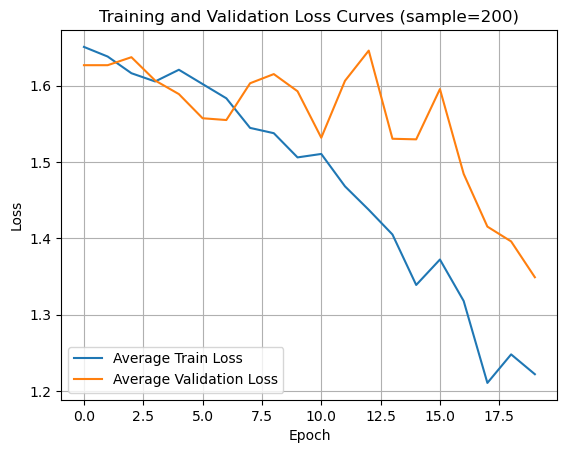

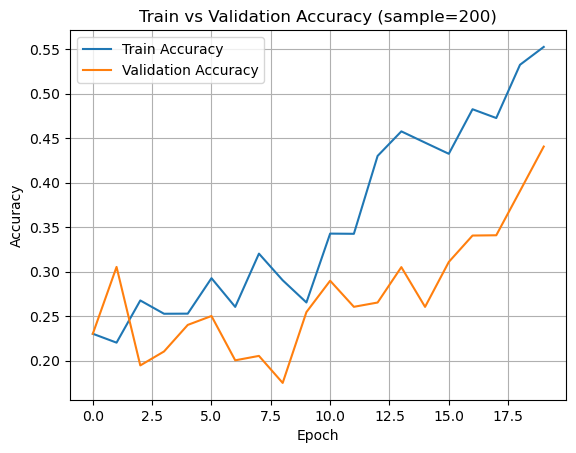

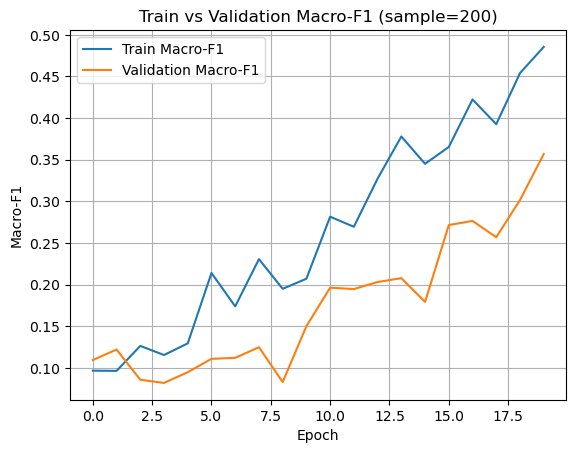

<Figure size 800x600 with 0 Axes>

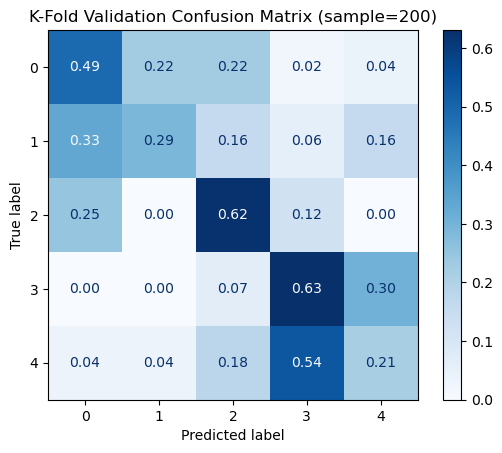

mean_val_acc: 0.42062415196743547
mean_val_f1: 0.3306680211582172

Loaded cached results for sample=500


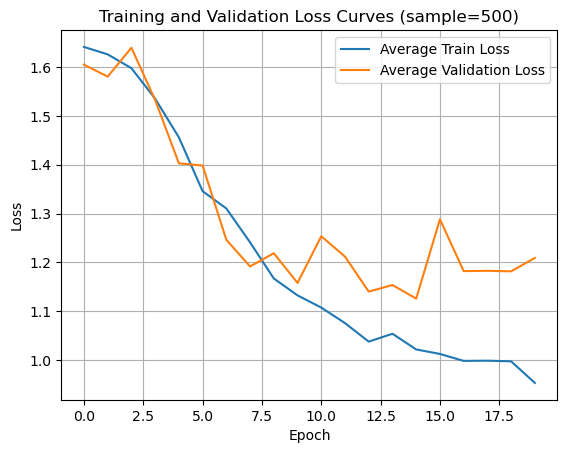

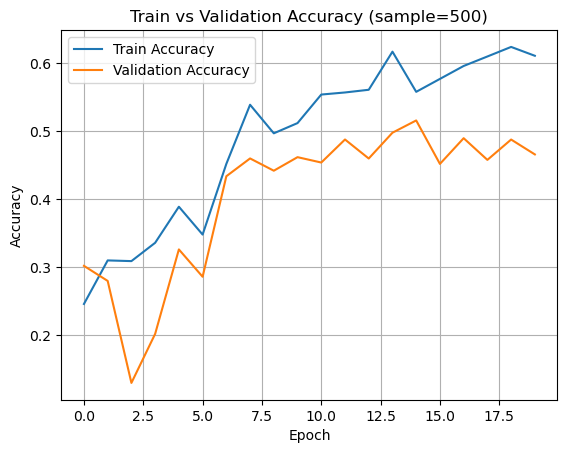

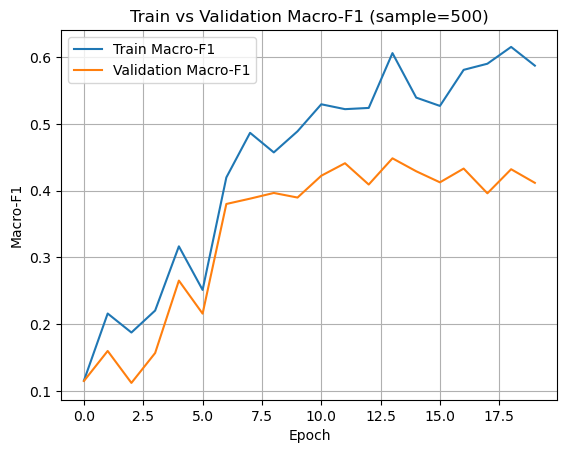

<Figure size 800x600 with 0 Axes>

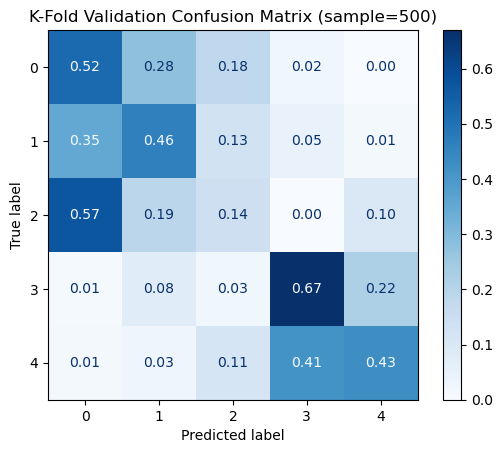

mean_val_acc: 0.5058437342183103
mean_val_f1: 0.4363261039938327

Loaded cached results for sample=1000


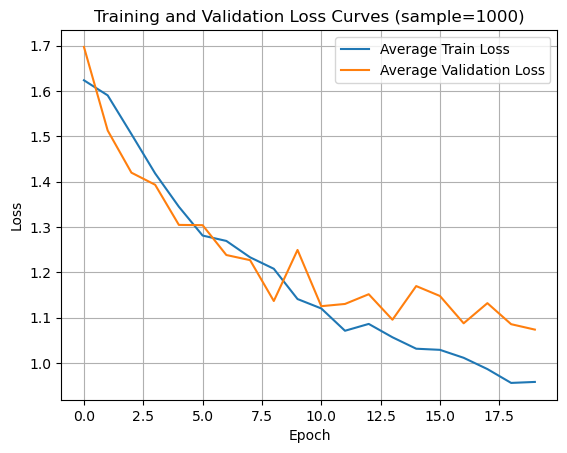

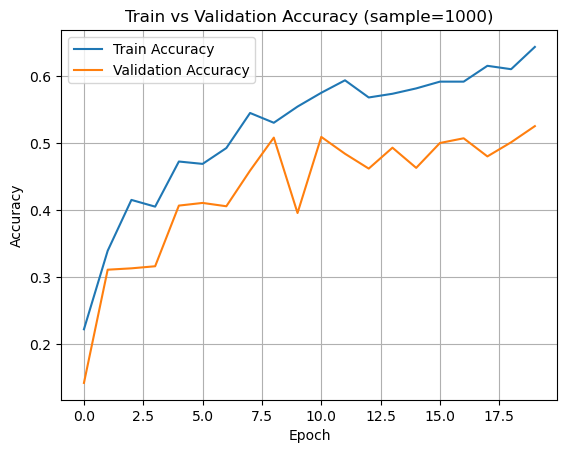

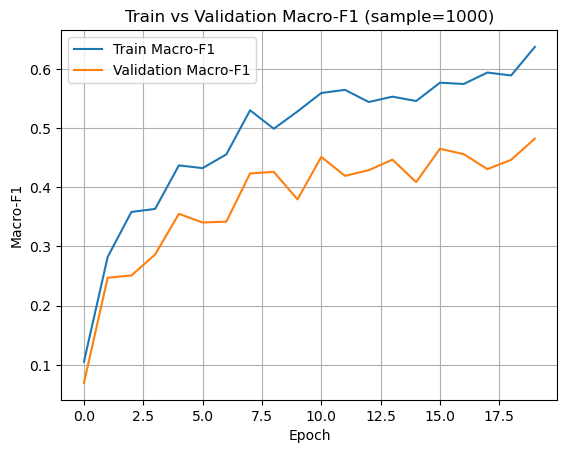

<Figure size 800x600 with 0 Axes>

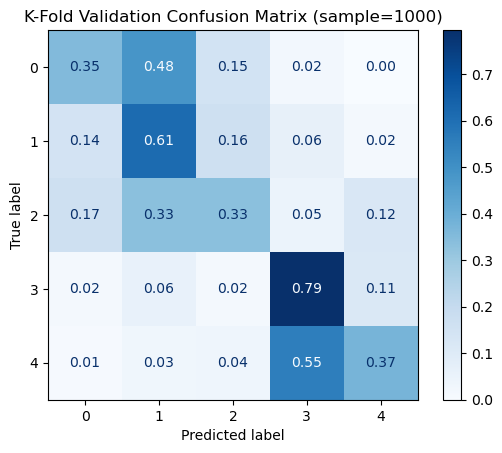

mean_val_acc: 0.5446832647811791
mean_val_f1: 0.4682392879073152


In [43]:
for sample in [200, 500, 1000]:

    cache_path = f"cached_data/transformer_kfold_5class_sample_{sample}.pkl"

    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            results = pickle.load(f)
        print(f"\nLoaded cached results for sample={sample}")
    else:

        df_sample = stratified_sample_df(subset, n=sample, random_state=67)

        print(f"\nSample size = {sample}")
        print(df_sample["new_category"].value_counts(normalize=True).sort_index())

        # tokenizer must be built on the dataframe being used
        tokenizer = ReactionTokenizer()
        tokenizer.build_vocab(df_sample)

        # try to get the smallest max_len_seen param to make the end code faster
        max_len_seen = 0
        for _, row in df_sample.iterrows():
            tokens, _, _ = build_reaction_tokens(
                reactant_smiles=row["reactant"],
                product_smiles=row["product"],
                reactant_preds=row.get("reactant_preds", None),
                product_preds=row.get("product_preds", None),
                include_gnn_vec=True
            )
            max_len_seen = max(max_len_seen, len(tokens))
        
        results = KFoldCrossValidationTransformer(
        model_class=ReactionTransformer,
        df=df_sample,
        tokenizer=tokenizer,

        include_gnn_vec=True,
        k=3,
        batch_size=85,
        epochs=20,
        lr=1.5e-3,

        device=device,
        show_progress=False,
        verbose=False,
        make_plots=False,

        random_state=67,
        val_every=1,
        train_eval_every=1,

        use_class_weights=False,
        use_weighted_sampling=True,
        gnn_dim=9,
        class_col="new_category",

        model_kwargs={
            "d_model": 128,
            "nhead": 2,
            "num_layers": 2,
            "dim_feedforward": 135,
            "dropout": 0.29,
            "max_len": max_len_seen + 16,
        }
        )

        # save it so no rerun  
        os.makedirs("cached_data", exist_ok=True)
        with open(cache_path, "wb") as f:
            pickle.dump(results, f)
        print(f"Saved cached results for sample={sample}")
    
    # loss
    plt.figure()
    plt.plot(results["avg_train_losses"], label="Average Train Loss")
    plt.plot(results["avg_val_losses"], label="Average Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training and Validation Loss Curves (sample={sample})")
    plt.legend()
    plt.grid(True)
    plt.show()

    # accuracy
    plt.figure()
    plt.plot(results["avg_train_accs"], label="Train Accuracy")
    plt.plot(results["avg_val_accs"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Train vs Validation Accuracy (sample={sample})")
    plt.legend()
    plt.grid(True)
    plt.show()

    # f1 curves
    plt.figure()
    plt.plot(results["avg_train_f1s"], label="Train Macro-F1")
    plt.plot(results["avg_val_f1s"], label="Validation Macro-F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.title(f"Train vs Validation Macro-F1 (sample={sample})")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # confusion matrix
    cm = confusion_matrix(
        results["val_labels"].numpy(),
        results["val_preds"].numpy(),
        normalize="true"
    )
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format=".2f")
    plt.title(f"K-Fold Validation Confusion Matrix (sample={sample})")
    plt.grid(False)
    plt.show()

    print("mean_val_acc:", results["mean_val_acc"])
    print("mean_val_f1:", results["mean_val_f1"])


Loaded cached results for sample = 200


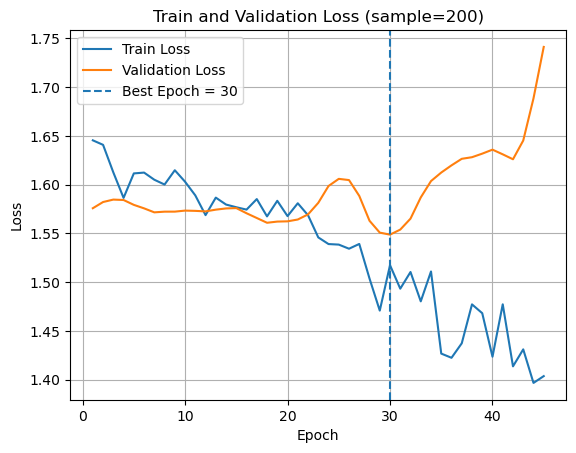

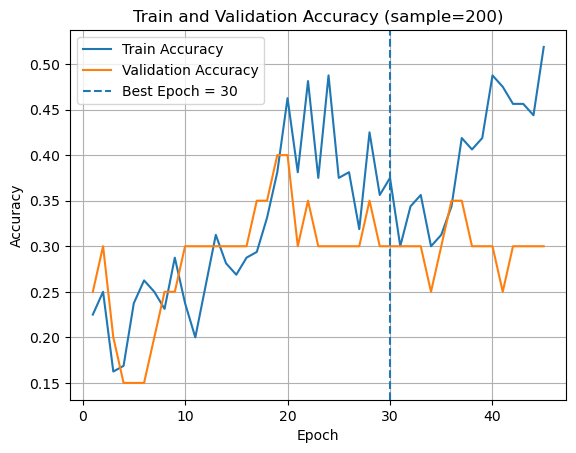

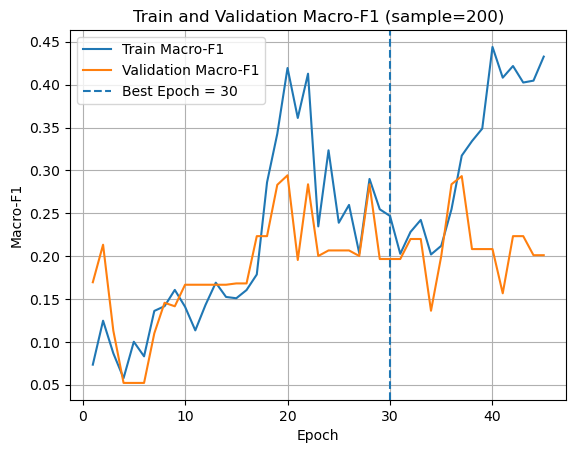

<Figure size 800x600 with 0 Axes>

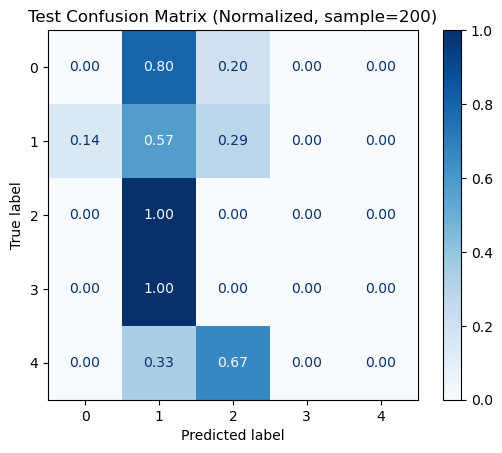

train_acc: 0.4
val_acc: 0.3
test_acc: 0.2
train_f1: 0.2580045351473923
val_f1: 0.19666666666666666
test_f1: 0.07619047619047618

Loaded cached results for sample = 500


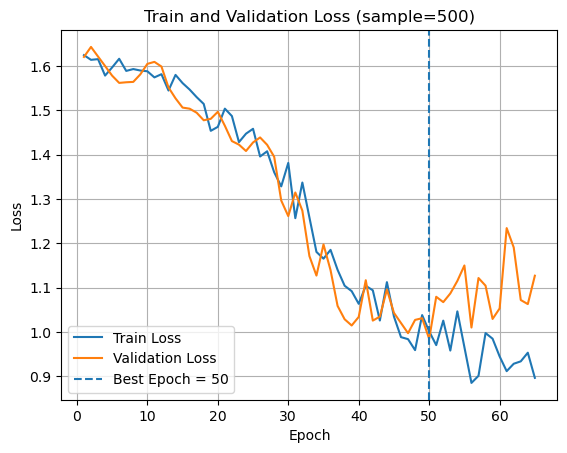

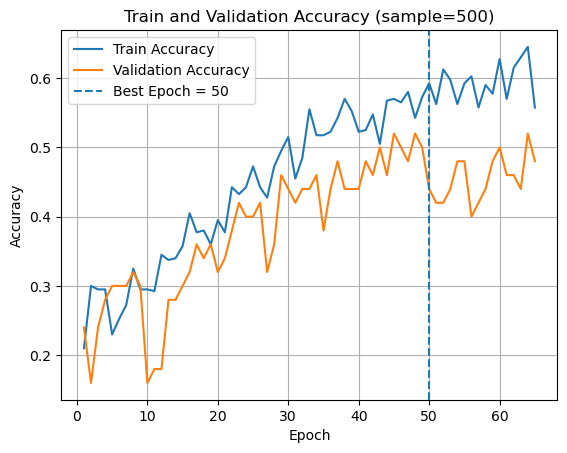

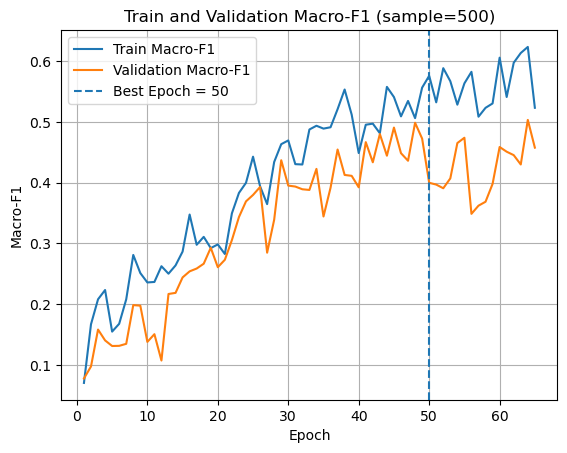

<Figure size 800x600 with 0 Axes>

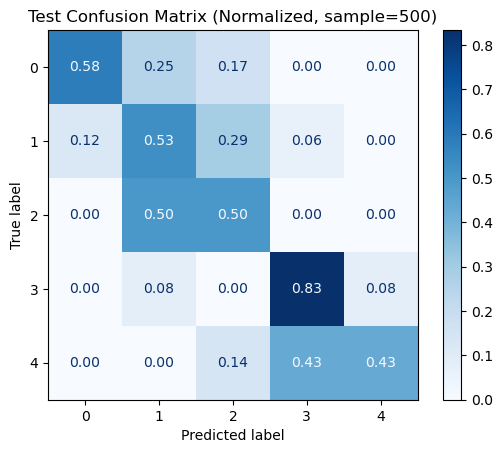

train_acc: 0.5875
val_acc: 0.44
test_acc: 0.6
train_f1: 0.5575840310591439
val_f1: 0.39978942152855196
test_f1: 0.5487630648920971

Loaded cached results for sample = 1000


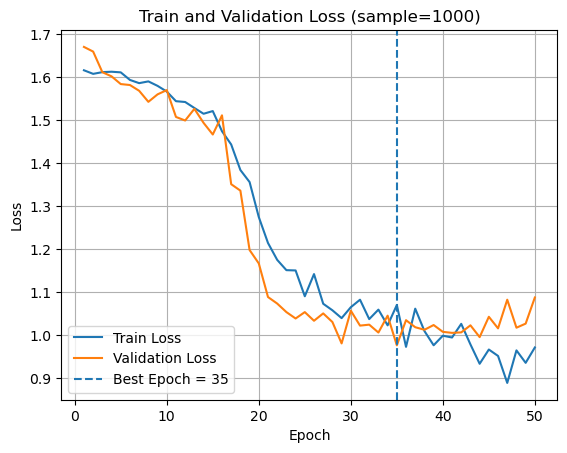

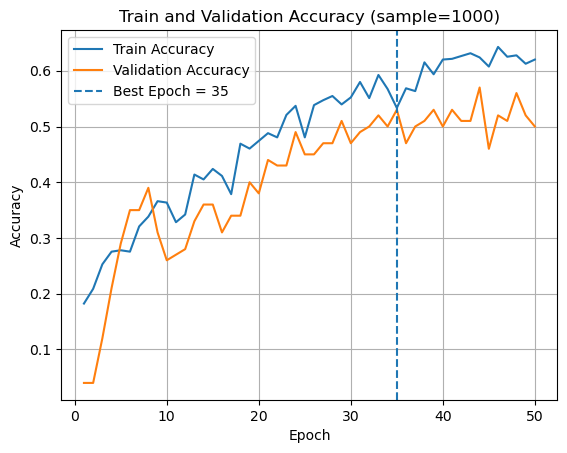

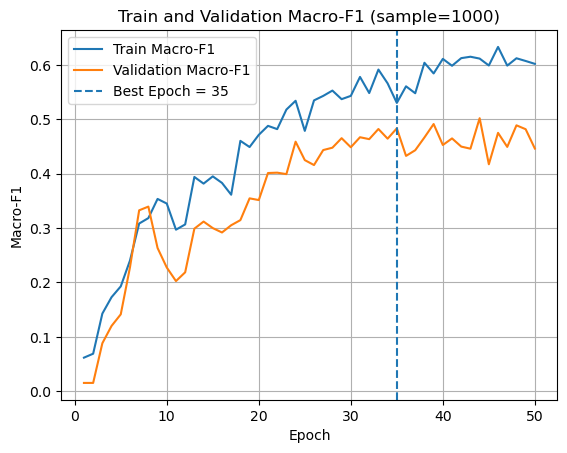

<Figure size 800x600 with 0 Axes>

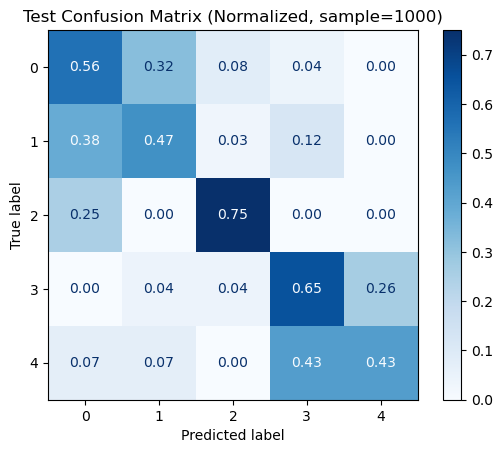

train_acc: 0.5647798742138365
val_acc: 0.53
test_acc: 0.54
train_f1: 0.5617910608141568
val_f1: 0.4833463711429813
test_f1: 0.5342179513608085


In [44]:
for sample in [200, 500, 1000]:

    cache_path = f"cached_data/transformer_trainvaltest_5class_sample_{sample}_cuda.pkl"

    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            results = load_pickle_cuda_to_cpu(cache_path)
        print(f"\nLoaded cached results for sample = {sample}")

    else:
        df_sample = stratified_sample_df(subset, n=sample, random_state=67)

        print(f"\nSample size = {sample}")
        print(df_sample["new_category"].value_counts(normalize=True).sort_index())

        tokenizer = ReactionTokenizer()
        tokenizer.build_vocab(df_sample)

        max_len_seen = 0
        for _, row in df_sample.iterrows():
            tokens, _, _ = build_reaction_tokens(
                reactant_smiles=row["reactant"],
                product_smiles=row["product"],
                reactant_preds=row.get("reactant_preds", None),
                product_preds=row.get("product_preds", None),
                include_gnn_vec=True
            )
            max_len_seen = max(max_len_seen, len(tokens))

        results = train_validate_test_transformer(
            model_class=ReactionTransformer,
            df=df_sample,
            tokenizer=tokenizer,
            include_gnn_vec=True,

            test_size=0.1,
            val_size=0.1,
            batch_size=124,
            epochs=80,
            lr=1.5e-4,

            optimizer=torch.optim.Adam,
            device=device,
            random_state=67,

            show_progress=False,
            verbose=True,
            make_plots=False,

            val_every=1,
            train_eval_every=1,
            early_stopping_patience_epochs=15,

            use_class_weights=False,
            use_weighted_sampling=True,
            gnn_dim=9,

            class_col="new_category",
            model_kwargs={
                "d_model": 128,
                "nhead": 2,
                "num_layers": 3,
                "dim_feedforward": 135,
                "dropout": 0.25,
                "max_len": max_len_seen + 16,
            } # these are more towards what I will use finally
        )

        os.makedirs("cached_data", exist_ok=True)
        with open(cache_path, "wb") as f:
            pickle.dump(results, f)

        print(f"Saved cached results for sample = {sample}")

    epochs_ran = len(results["train_losses"])

    plt.figure()
    plt.plot(range(1, epochs_ran + 1), results["train_losses"], label="Train Loss")
    plt.plot(range(1, epochs_ran + 1), results["val_losses"], label="Validation Loss")
    plt.axvline(results["best_epoch"], linestyle="--", label=f"Best Epoch = {results['best_epoch']}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train and Validation Loss (sample={sample})")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(range(1, epochs_ran + 1), results["train_accs"], label="Train Accuracy")
    plt.plot(range(1, epochs_ran + 1), results["val_accs"], label="Validation Accuracy")
    plt.axvline(results["best_epoch"], linestyle="--", label=f"Best Epoch = {results['best_epoch']}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Train and Validation Accuracy (sample={sample})")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(range(1, epochs_ran + 1), results["train_f1s"], label="Train Macro-F1")
    plt.plot(range(1, epochs_ran + 1), results["val_f1s"], label="Validation Macro-F1")
    plt.axvline(results["best_epoch"], linestyle="--", label=f"Best Epoch = {results['best_epoch']}")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.title(f"Train and Validation Macro-F1 (sample={sample})")
    plt.legend()
    plt.grid(True)
    plt.show()

    cm = confusion_matrix(
        results["test_labels"].numpy(),
        results["test_preds"].numpy(),
        normalize="true"
    )

    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format=".2f")
    plt.title(f"Test Confusion Matrix (Normalized, sample={sample})")
    plt.grid(False)
    plt.show()

    print("train_acc:", results["train_acc"])
    print("val_acc:", results["val_acc"])
    print("test_acc:", results["test_acc"])

    print("train_f1:", results["train_f1"])
    print("val_f1:", results["val_f1"])
    print("test_f1:", results["test_f1"])

### (4) Motif Analysis

Now is the trickiest bit of code I will need to muster. From the trasnformer model, find the chemical group or the smiles string most responsible for the label aka chemical reaction. 

For instance: I select a chemical reaction that has predicted label 'protection' reaction. From the transformer, identify which smiles tokens/chemcial motifs most influenced the model's prediction as protection (the output maybe groups involved in acetal hydrolysis, or amine protection group, or whatever). 

This is qualitatively how the algorithm will work:

(1) Importance of a singular token. 

   - Mask a token and recompute the prob of label. 

   - The bigger the drop, the more vital it is. 

(2) Aggregate the top tokens and substrings. 

   - To simplify this code, we will only aggregeate the atom tokens and the chemical groups. Then, if so happen two atom tokens are adjacent, highlight the bond between them. 

(3) Map these calculated substrings to the motif in the reaction scheme on the products and reactants side.

In [45]:
# alchemy elements (uppercase) and when thet are in rings
ATOM_TOKENS = ATOM_TOKENS = {"C", "H", "O", "N", "F", "Cl", "S", "c", "n", "o", "s"}
SPECIAL_TOKENS = {
    pad_token,
    unk_token, 
    cls_token, 
    react_mol_token, 
    prod_mol_token,
    react_gnn_token, 
    prod_gnn_token, 
    sep_token
}

def is_atom_token(tok):
    return tok in ATOM_TOKENS or (tok.startswith("[") and tok.endswith("]"))


def make_model_inputs(tokenizer, tokens, gnn_mask, gnn_values, device="cpu", max_len=512):
    tokens, gnn_mask, gnn_values = tokens[:max_len], gnn_mask[:max_len], gnn_values[:max_len]

    input_ids = torch.tensor(
        tokenizer.encode_tokens(tokens), dtype=torch.long
    ).unsqueeze(0).to(device)

    attention_mask = torch.ones_like(input_ids)

    gnn_mask = torch.tensor(
        gnn_mask, dtype=torch.bool
    ).unsqueeze(0).to(device)

    gnn_values = torch.tensor(
        gnn_values, dtype=torch.float
    ).unsqueeze(0).to(device)

    return input_ids, attention_mask, gnn_mask, gnn_values


@torch.no_grad()
def get_probs(model, tokenizer, tokens, gnn_mask, gnn_values, device="cpu", max_len=512):
    model.eval()

    input_ids, attention_mask, gnn_mask, gnn_values = make_model_inputs(
        tokenizer, tokens, gnn_mask, gnn_values, device=device, max_len=max_len
    )

    logits = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        gnn_mask=gnn_mask,
        gnn_values=gnn_values,
    )

    return torch.softmax(logits, dim=1).cpu().numpy().flatten()


def token_mask_importance(
    model,
    tokenizer,
    row,
    include_gnn_vec=True,
    gnn_dim=9,
    device="cpu",
    target_class=None,
    max_len=512,
    only_atom_tokens=True,
):
    """
    Importance = original class probability - probability after masking token.
    target_class should be original 1-5 label. If None, explain predicted class.
    """

    tokens, gnn_mask, gnn_values = build_reaction_tokens(
        row["reactant"],
        row["product"],
        row.get("reactant_preds", None),
        row.get("product_preds", None),
        include_gnn_vec=include_gnn_vec,
        gnn_dim=gnn_dim,
    )

    tokens, gnn_mask, gnn_values = tokens[:max_len], gnn_mask[:max_len], gnn_values[:max_len]

    probs = get_probs(model, tokenizer, tokens, gnn_mask, gnn_values, device, max_len)
    target_idx = int(target_class) - 1 if target_class is not None else int(np.argmax(probs))
    original_prob = probs[target_idx]

    rows = []

    for i, tok in enumerate(tokens):
        if tok in SPECIAL_TOKENS: continue
        if only_atom_tokens and not is_atom_token(tok): continue

        masked_tokens = tokens.copy()
        masked_tokens[i] = unk_token

        masked_prob = get_probs(
            model, tokenizer, masked_tokens, gnn_mask, gnn_values, device, max_len
        )[target_idx]

        rows.append({
            "token_index": i,
            "token": tok,
            "original_prob": original_prob,
            "masked_prob": masked_prob,
            "importance": original_prob - masked_prob,
            "target_class": target_idx + 1,
            "pred_class": int(np.argmax(probs)) + 1,
        })

    df = pd.DataFrame(rows)
    return df.sort_values("importance", ascending=False).reset_index(drop=True), tokens, probs


def token_position_map(tokens):
    """
    Maps global token index -> reaction side, molecule index, local SMILES token index.
    """
    out, side, mol_idx, local_idx = {}, None, -1, 0

    for i, tok in enumerate(tokens):
        if tok == react_mol_token:
            side, mol_idx, local_idx = "reactant", mol_idx + 1, 0
            continue

        if tok == sep_token:
            side, mol_idx, local_idx = None, -1, 0
            continue

        if tok == prod_mol_token:
            side, mol_idx, local_idx = "product", 0 if side != "product" else mol_idx + 1, 0
            continue

        if tok in {cls_token, react_gnn_token, prod_gnn_token}: continue

        if side in {"reactant", "product"}:
            out[i] = {
                "side": side,
                "mol_idx": mol_idx,
                "local_idx": local_idx,
                "token": tok,
            }
            local_idx += 1

    return out


def smiles_token_atom_map(smi):
    """
    Approximate local SMILES-token index -> RDKit atom index map.
    Works well enough for qualitative highlighting.
    """
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None, {}

    mapping, atom_idx = {}, 0

    for local_idx, tok in enumerate(tokenize_smiles(smi)):
        if is_atom_token(tok) and atom_idx < mol.GetNumAtoms():
            mapping[local_idx] = atom_idx
            atom_idx += 1

    return mol, mapping


def collect_motif_atoms(row, tokens, importance_df, top_k=8, min_importance=0.0):
    """
    Converts important token positions into highlighted atoms/bonds.
    """
    pos_map = token_position_map(tokens)

    smiles = {
        "reactant": [s.strip() for s in str(row["reactant"]).split(".") if s.strip()],
        "product":  [s.strip() for s in str(row["product"]).split(".") if s.strip()],
    }

    mols, maps = {}, {}

    for side in ["reactant", "product"]:
        pairs = [smiles_token_atom_map(smi) for smi in smiles[side]]
        mols[side] = [p[0] for p in pairs]
        maps[side] = [p[1] for p in pairs]

    atoms = {side: [set() for _ in mols[side]] for side in ["reactant", "product"]}
    bonds = {side: [set() for _ in mols[side]] for side in ["reactant", "product"]}

    top_df = importance_df[importance_df["importance"] > min_importance].head(top_k)

    for _, r in top_df.iterrows():
        info = pos_map.get(int(r["token_index"]))
        if info is None: continue

        side, mi, li = info["side"], info["mol_idx"], info["local_idx"]
        if mi >= len(mols[side]) or mols[side][mi] is None: continue
        if li in maps[side][mi]: atoms[side][mi].add(maps[side][mi][li])

    for side in ["reactant", "product"]:
        for mi, mol in enumerate(mols[side]):
            if mol is None: continue

            for bond in mol.GetBonds():
                a, b = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
                if a in atoms[side][mi] and b in atoms[side][mi]: bonds[side][mi].add(bond.GetIdx())

    return mols, atoms, bonds, top_df


def draw_motif_grid(mols, atoms, bonds):
    imgs = []

    for side in ["reactant", "product"]:
        for i, mol in enumerate(mols[side]):
            if mol is None: continue

            drawer = rdMolDraw2D.MolDraw2DSVG(500, 300)
            opts = drawer.drawOptions()
            opts.useBWAtomPalette()

            drawer.DrawMolecule(
                mol,
                legend=f"{side} {i}",
                highlightAtoms=list(atoms[side][i]),
                highlightBonds=list(bonds[side][i]),
            )

            drawer.FinishDrawing()
            imgs.append(SVG(drawer.GetDrawingText()))

    return imgs


def explain_reaction_motif(
    model,
    tokenizer,
    row,
    include_gnn_vec=True,
    gnn_dim=9,
    device="cpu",
    target_class=None,
    top_k=8,
    min_importance=0.0,
    max_len=512,
    show=True,
):
    """
    Full motif explanation:
        1. mask tokens one-by-one
        2. rank by probability drop
        3. map important tokens to atoms
        4. highlight atoms/bonds
    """

    importance_df, tokens, probs = token_mask_importance(
        model=model,
        tokenizer=tokenizer,
        row=row,
        include_gnn_vec=include_gnn_vec,
        gnn_dim=gnn_dim,
        device=device,
        target_class=target_class,
        max_len=max_len,
        only_atom_tokens=True,
    )

    mols, atoms, bonds, top_df = collect_motif_atoms(
        row=row,
        tokens=tokens,
        importance_df=importance_df,
        top_k=top_k,
        min_importance=min_importance,
    )

    img = draw_motif_grid(mols, atoms, bonds)

    pred_class = int(np.argmax(probs)) + 1
    pred_prob = float(np.max(probs))

    print(f"Predicted class: {pred_class}")
    print(f"Predicted probability: {pred_prob:.4f}")

    if target_class is not None:
        print(f"Explaining class: {target_class}")
        print(f"Target probability: {probs[int(target_class)-1]:.4f}")

    if show:
        display(top_df)
        for im in img: display(im)

    return {
        "importance_df": importance_df,
        "top_df": top_df,
        "tokens": tokens,
        "probs": probs,
        "pred_class": pred_class,
        "pred_prob": pred_prob,
        "mols": mols,
        "highlight_atoms": atoms,
        "highlight_bonds": bonds,
        "image": img,
    }

In [46]:
display(new_reaction_names)

{1: 'Heteroatom alkylation / arylation',
 2: 'Functional group transformations (incl. acylation)',
 3: 'C–C bond formation / ring formation',
 4: 'Protection / deprotection',
 5: 'Redox'}

Predicted class: 1
Predicted probability: 0.5861
Explaining class: 1
Target probability: 0.5861


,token_index,token,original_prob,masked_prob,importance,target_class,pred_class
0,4,N,0.586122,0.558309,0.027813,1,1
1,26,N,0.586122,0.558640,0.027482,1,1
2,19,O,0.586122,0.584367,0.001755,1,1


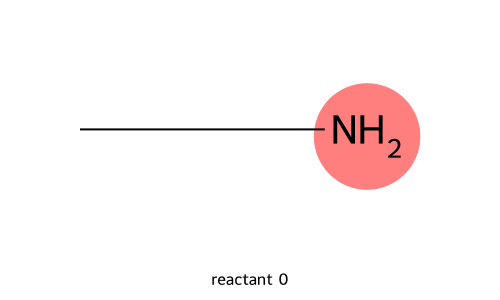

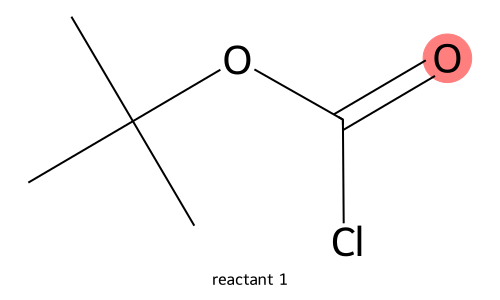

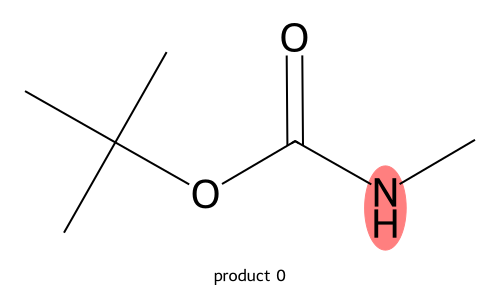

In [47]:
gnn_results = load_pickle_cuda_to_cpu("cached_data/gnn_trainvaltest_1000_cuda.pkl")

structure_predictor = USPTOStructurePredictor(
    model=gnn_results["model"],
    featurizer=featurizer,
    device=device,
    unnormalize=False
)

# simple BOC protection example
# methylamine + BOC chloride -> BOC-protected methylamine
row = pd.Series({
    "reactant": "CN.CC(C)(C)OC(=O)Cl",
    "product": "CNC(=O)OC(C)(C)C",
    "new_category": 4  # Protection / Deprotection in 5-class setup
})

# get GNN vectors for each molecule on reactant/product side
row["reactant_preds"] = structure_predictor.get_structure_preds(row["reactant"])
row["product_preds"] = structure_predictor.get_structure_preds(row["product"])

# normalize the GNN vectors using the same prediction-normalization logic
temp_df = pd.DataFrame([row])
temp_df = normalize_gnn_preds(temp_df)
row = temp_df.iloc[0]

# rebuild the tokenizer if loaded from cache
tokenizer = ReactionTokenizer()
tokenizer.build_vocab(subset)   # or full_df used during training

# run motif explanation
motif_results = explain_reaction_motif(
    model=results["model"],
    tokenizer=tokenizer,
    row=row,
    include_gnn_vec=True,
    gnn_dim=9,
    device=device,
    target_class=1, # this protection reaction also does look like an alkylation reaction
    top_k=3,
    max_len=512,
    show=True
) # now, we can run and train the whole thing

## Endgame
Using the whole alchemy and uspto dataset, run the transformer by itself to see if chemical reactions are well-predicted. Then, run the GNN, couple it to the transfomer, and see if reactions are less confused.

(1) Run the GNN on the whole dataset and cache the results.

In [48]:
device = "cuda" if torch.cuda.is_available() else "cpu" # now for savio
gnn_cache_path = "cached_data/gnn_trainvaltest_full.pkl"

if os.path.exists(gnn_cache_path):
    with open(gnn_cache_path, "rb") as f:
        gnn_results = load_pickle_cuda_to_cpu(gnn_cache_path)
    print("Loaded cached full GNN results.")
else:
    gnn_results = train_validate_test(
        model_class=GNN,
        graph_dataset=graph_dataset,   # full alchemy graph dataset, done and made earlier
        test_size=0.1,
        val_size=0.1,
        batch_size=100,
        epochs=150, # no worries, we have an early stopping patience and save best model so no overtrain
        hidden_dim=100,
        dropout=0.25,
        lr=9e-4,
        optimizer=torch.optim.Adam,
        loss_type="smoothl1",
        beta=0.6,
        device=device,
        random_state=67,
        show_progress=True,
        verbose=True,
        make_plots=True,
        val_every=1,
        train_eval_every=1,
        early_stopping_patience_epochs=15,
        min_delta=1e-4,
    )

    os.makedirs("cached_data", exist_ok=True)

    with open(gnn_cache_path, "wb") as f:
        pickle.dump(gnn_results, f)

    print("Saved cached full GNN results.")

Loaded cached full GNN results.


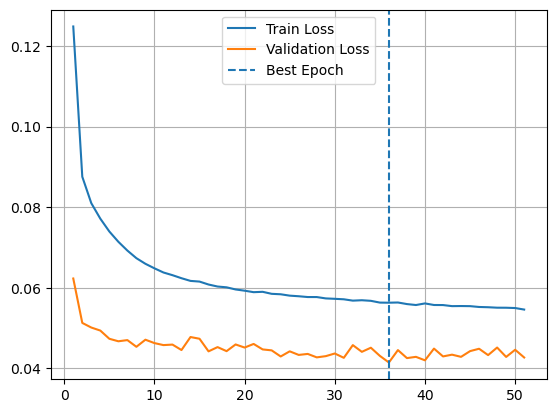

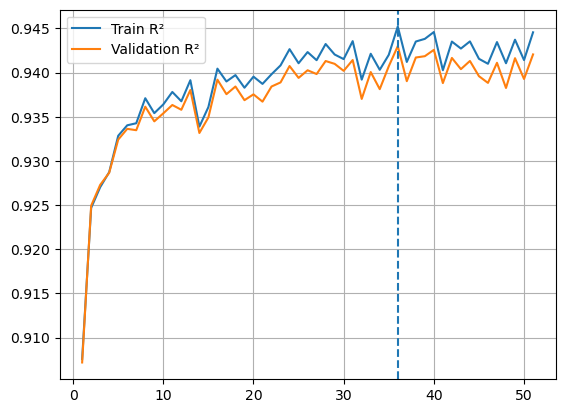

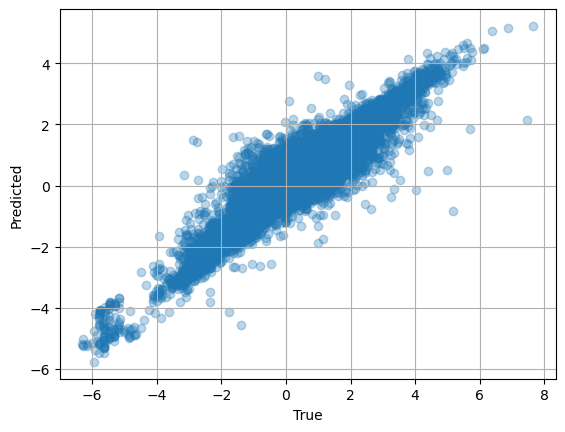

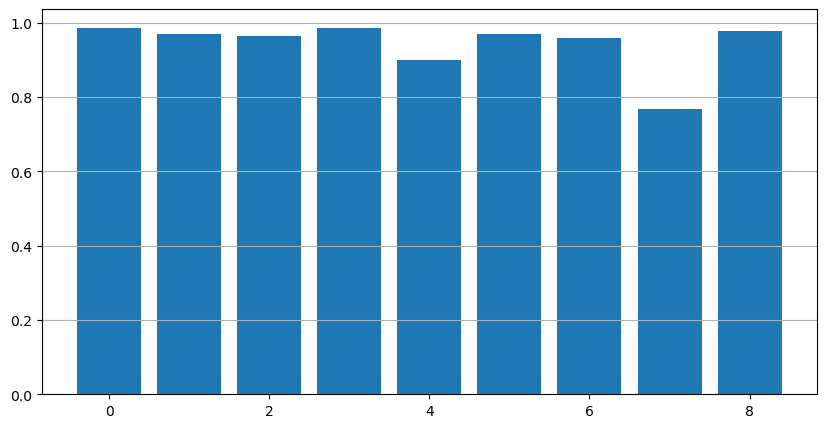

Train R²: 0.9452288746833801
Val R²: 0.9430049061775208
Test R²: 0.9424908757209778


In [49]:
# this will plot everything if pulled from cache
epochs_ran = len(gnn_results["train_losses"])

# loss
plt.figure()
plt.plot(range(1, epochs_ran + 1), gnn_results["train_losses"], label="Train Loss")
plt.plot(range(1, epochs_ran + 1), gnn_results["val_losses"], label="Validation Loss")
plt.axvline(gnn_results["best_epoch"], linestyle="--", label=f"Best Epoch")
plt.legend(); plt.grid(); plt.show()

# R²
plt.figure()
plt.plot(range(1, epochs_ran + 1), gnn_results["train_r2s"], label="Train R²")
plt.plot(range(1, epochs_ran + 1), gnn_results["val_r2s"], label="Validation R²")
plt.axvline(gnn_results["best_epoch"], linestyle="--")
plt.legend(); plt.grid(); plt.show()

# parity
plt.figure()
plt.scatter(
    gnn_results["test_targets"].flatten().numpy(),
    gnn_results["test_preds"].flatten().numpy(),
    alpha=0.3
)
plt.xlabel("True"); plt.ylabel("Predicted"); plt.grid(); plt.show()

# per-property R²
plt.figure(figsize=(10,5))
plt.bar(range(len(gnn_results["test_r2_per_output"])),
        gnn_results["test_r2_per_output"].cpu().numpy())
plt.grid(axis="y"); plt.show()

print("Train R²:", gnn_results["train_r2"])
print("Val R²:", gnn_results["val_r2"])
print("Test R²:", gnn_results["test_r2"])

(2) Now, use the GNN model to featurize the USPTO reaction dataset.

In [50]:
structure_predictor = USPTOStructurePredictor(
    model=gnn_results["model"], # the model from the GNN
    featurizer=featurizer, # from the AlchemyFeaturizer class, made earlier
    device=device,
    unnormalize=False
)

uspto_gnn_cache_path = "cached_data/uspto_full_with_gnn_normalized.pkl"

if os.path.exists(uspto_gnn_cache_path):
    with open(uspto_gnn_cache_path, "rb") as f:
        reaction_types_df = pickle.load(f)
    print("Loaded cached USPTO dataframe with normalized GNN features.")

else:
    reaction_types_df = reaction_types_df.copy()

    reaction_types_df = structure_predictor.add_structure_preds_to_df(
        reaction_types_df,
        reactant_col="reactant",
        product_col="product"
    ) # tack on the predictions the normalize them

    reaction_types_df = normalize_gnn_preds(reaction_types_df)

    os.makedirs("cached_data", exist_ok=True)
    with open(uspto_gnn_cache_path, "wb") as f:
        pickle.dump(reaction_types_df, f)

    print("Generated and cached USPTO dataframe with normalized GNN features.")

Loaded cached USPTO dataframe with normalized GNN features.


(3) Now run the transformer with and without the GNN vector and see how well it performs. We can split this in two and run in parallel because one does not depend on the other. 

In [51]:
# build the tokenizer once and pass it along because it takes a long time to load
full_df = reaction_types_df.copy()
tokenizer = ReactionTokenizer()
tokenizer.build_vocab(full_df)
print("Vocab size:", tokenizer.vocab_size)

Vocab size: 58


In [52]:
def run_final_transformer_experiment(include_gnn_vec, tokenizer):
    mode = "with_gnn" if include_gnn_vec else "smiles_only"
    cache_path = f"cached_data/final_transformer_full_35k_5class_{mode}.pkl"

    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            transformer_results = load_pickle_cuda_to_cpu(cache_path)
        print(f"Loaded cached final transformer results: {mode}")

        if "tokenizer" not in transformer_results:
            transformer_results["tokenizer"] = tokenizer

    else:
        full_df = reaction_types_df.copy()

        max_len_seen = 0
        for _, row in full_df.iterrows():
            tokens, _, _ = build_reaction_tokens(
                row["reactant"],
                row["product"],
                row.get("reactant_preds", None),
                row.get("product_preds", None),
                include_gnn_vec=include_gnn_vec
            )
            max_len_seen = max(max_len_seen, len(tokens))

        transformer_results = train_validate_test_transformer(
            model_class=ReactionTransformer,
            df=full_df,
            tokenizer=tokenizer,
            include_gnn_vec=include_gnn_vec,
            test_size=0.1,
            val_size=0.1,
            batch_size=124,
            epochs = 150,
            lr=1.5e-4,
            optimizer=torch.optim.Adam,
            device=device,
            random_state=67,
            show_progress=True,
            verbose=True,
            make_plots=False,
            val_every=3,
            train_eval_every=3,
            early_stopping_patience_epochs=60,
            min_delta=1e-4,
            use_class_weights=False,
            use_weighted_sampling=True,
            gnn_dim=9,
            class_col="new_category",
            model_kwargs={
                "d_model": 128,
                "nhead": 4,
                "num_layers": 3,
                "dim_feedforward": 135,
                "dropout": 0.25,
                "max_len": max_len_seen + 16,
            }
        )

        transformer_results["tokenizer"] = tokenizer
        transformer_results["max_len_seen"] = max_len_seen
        transformer_results["mode"] = mode

        os.makedirs("cached_data", exist_ok=True)
        with open(cache_path, "wb") as f:
            pickle.dump(transformer_results, f)

    return transformer_results

def plot_transformer_results(transformer_results, title_prefix="Transformer"):
    epochs_ran = len(transformer_results["train_losses"])

    plt.figure()
    plt.plot(range(1, epochs_ran + 1), transformer_results["train_losses"], label="Train Loss")
    plt.plot(range(1, epochs_ran + 1), transformer_results["val_losses"], label="Validation Loss")
    plt.axvline(transformer_results["best_epoch"], linestyle="--", label=f"Best Epoch = {transformer_results['best_epoch']}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix}: Train and Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(range(1, epochs_ran + 1), transformer_results["train_accs"], label="Train Accuracy")
    plt.plot(range(1, epochs_ran + 1), transformer_results["val_accs"], label="Validation Accuracy")
    plt.axvline(transformer_results["best_epoch"], linestyle="--", label=f"Best Epoch = {transformer_results['best_epoch']}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix}: Train and Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(range(1, epochs_ran + 1), transformer_results["train_f1s"], label="Train Macro-F1")
    plt.plot(range(1, epochs_ran + 1), transformer_results["val_f1s"], label="Validation Macro-F1")
    plt.axvline(transformer_results["best_epoch"], linestyle="--", label=f"Best Epoch = {transformer_results['best_epoch']}")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.title(f"{title_prefix}: Train and Validation Macro-F1")
    plt.legend()
    plt.grid(True)
    plt.show()

    cm = confusion_matrix(
        transformer_results["test_labels"].numpy(),
        transformer_results["test_preds"].numpy(),
        normalize="true"
    )

    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format=".2f")
    plt.title(f"{title_prefix}: Test Confusion Matrix")
    plt.grid(False)
    plt.show()

    print("best_epoch:", transformer_results["best_epoch"])
    print("train_acc:", transformer_results["train_acc"])
    print("val_acc:", transformer_results["val_acc"])
    print("test_acc:", transformer_results["test_acc"])
    print("train_f1:", transformer_results["train_f1"])
    print("val_f1:", transformer_results["val_f1"])
    print("test_f1:", transformer_results["test_f1"])

Loaded cached final transformer results: smiles_only


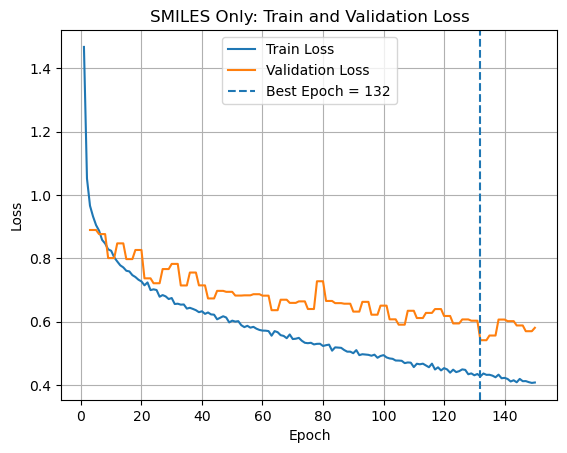

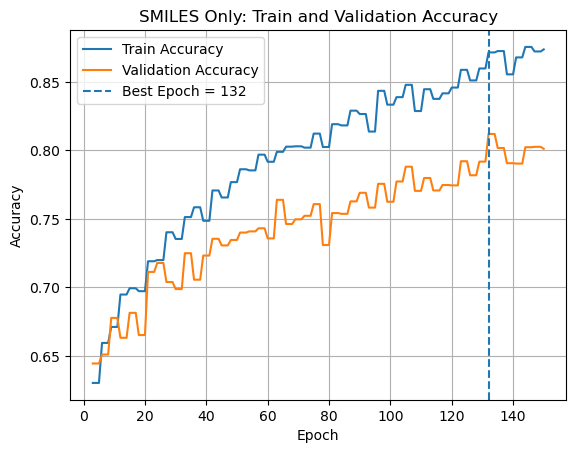

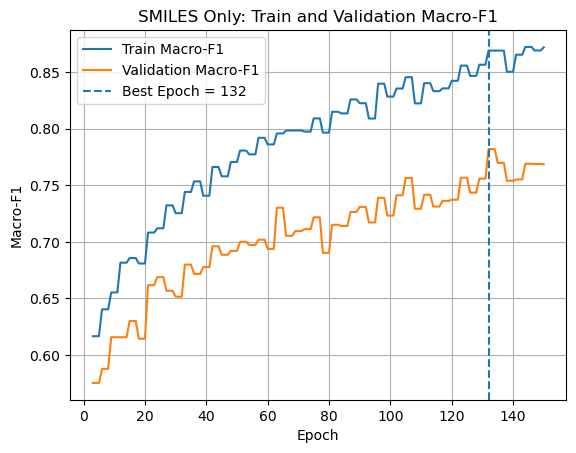

<Figure size 800x600 with 0 Axes>

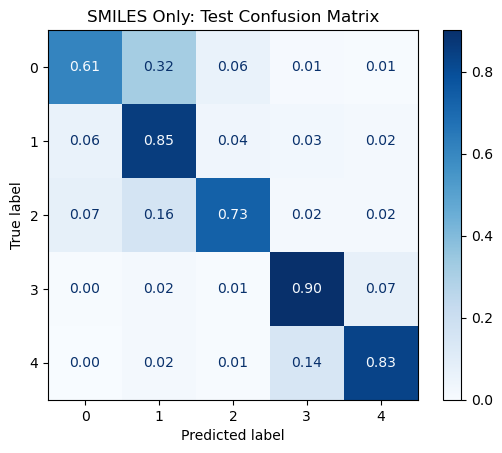

best_epoch: 132
train_acc: 0.8715292609995728
val_acc: 0.8120728929384966
test_acc: 0.7958428246013668
train_f1: 0.8698369313113208
val_f1: 0.7820880236724252
test_f1: 0.7645298337933796


In [53]:
transformer_results = run_final_transformer_experiment(include_gnn_vec=False, tokenizer=tokenizer)
plot_transformer_results(transformer_results, title_prefix="SMILES Only")

Loaded cached final transformer results: with_gnn


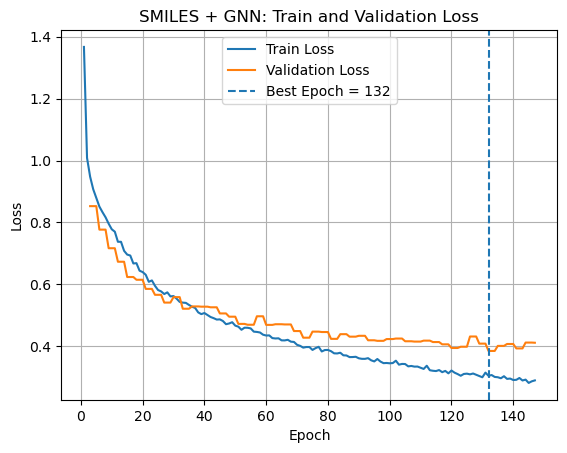

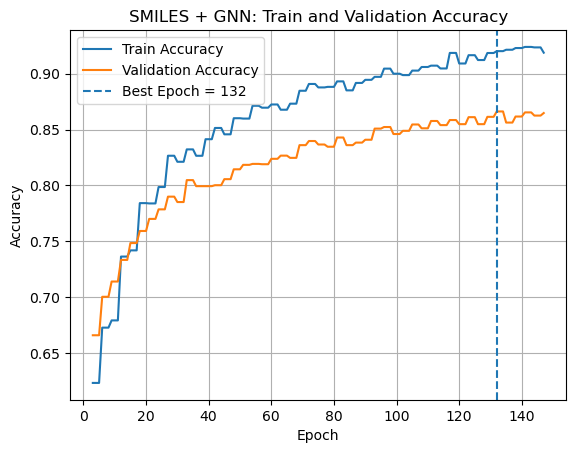

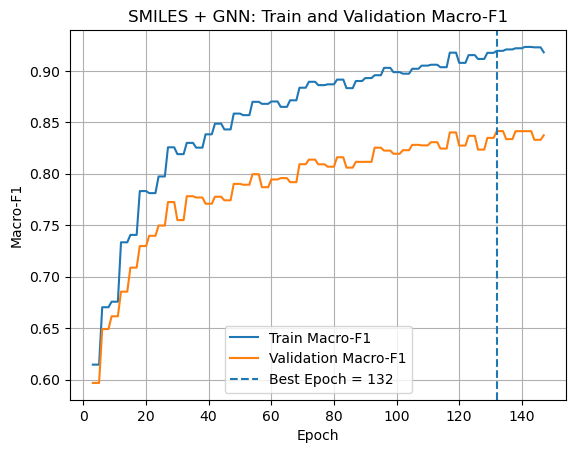

<Figure size 800x600 with 0 Axes>

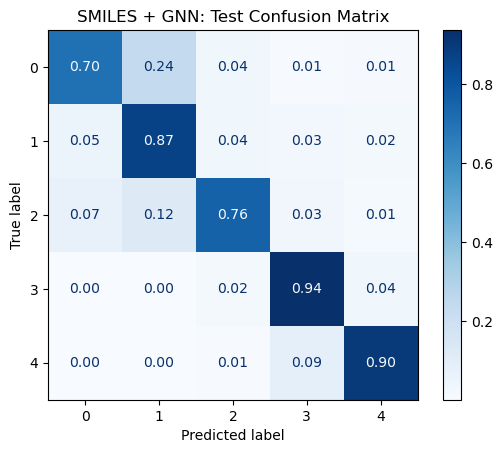

best_epoch: 132
train_acc: 0.9209739427595045
val_acc: 0.8661731207289294
test_acc: 0.8436788154897494
train_f1: 0.9201371599517632
val_f1: 0.8414534578961783
test_f1: 0.8133831812234726


In [54]:
transformer_results = run_final_transformer_experiment(include_gnn_vec=True, tokenizer=tokenizer)
plot_transformer_results(transformer_results, title_prefix="SMILES + GNN")

Plots for Presentation

In [55]:
def plot_r2_with_best(results, title="Train vs Validation R²"):

    epochs = range(1, len(results["train_r2s"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, results["train_r2s"], label="Train R²")
    plt.plot(epochs, results["val_r2s"], label="Validation R²")

    # best epoch
    best_epoch = results["best_epoch"]
    plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")

    # extract best values
    best_train = results["train_r2"]
    best_val = results["val_r2"]
    best_test = results["test_r2"]

    # annotate on plot
    text_str = (
        f"Best Train R²: {best_train:.3f}\n"
        f"Best Val R²: {best_val:.3f}\n"
        f"Test R²: {best_test:.3f}"
    )

    plt.text(
        0.65, 0.1, text_str,
        transform=plt.gca().transAxes,
        bbox=dict(facecolor='white', alpha=0.8)
    )

    plt.xlabel("Epoch")
    plt.ylabel("R²")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

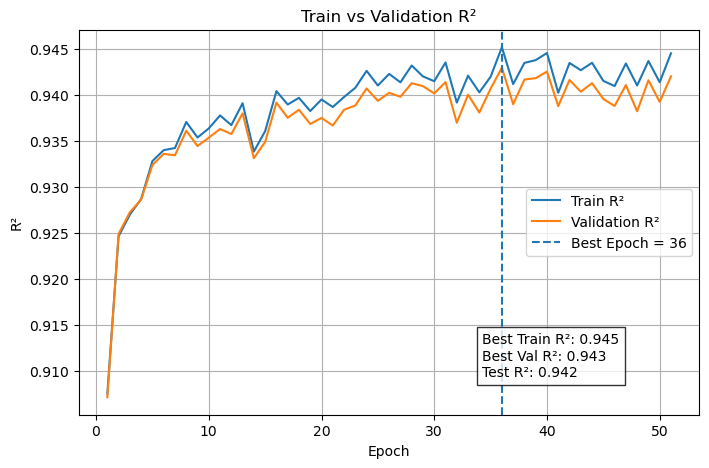

In [56]:
results = gnn_results
plot_r2_with_best(results)

In [57]:
def plot_r2_per_property(results, property_names=None, title="R² per Molecular Property"):
    
    r2_vals = results["test_r2_per_output"].cpu().numpy()

    # default names (your 9 targets)
    if property_names is None:
        property_names = [
            "ZPVE",
            "Cv",
            "Gap",
            "G",
            "HOMO",
            "Polarizability",
            "LUMO",
            "Dipole (μ)",
            "Electron extent ⟨r²⟩"
        ]

    x = np.arange(len(property_names))

    plt.figure(figsize=(10, 5))
    bars = plt.bar(x, r2_vals)

    # add value labels
    for i, v in enumerate(r2_vals):
        plt.text(
            i, v + 0.01,          # position above bar
            f"{v:.2f}",           # format
            ha="center",
            fontsize=9
        )

    plt.xticks(x, property_names, rotation=45)
    plt.ylabel("R² score")
    plt.title(title)
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

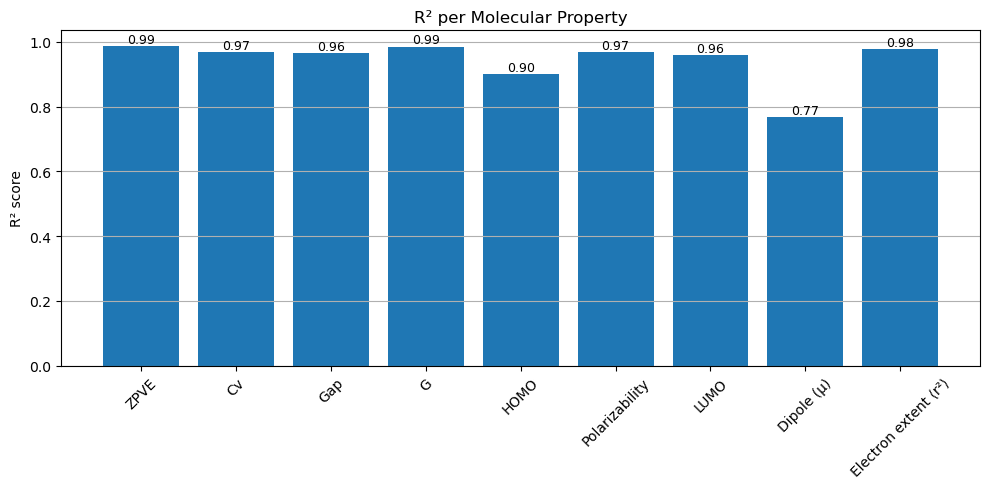

In [58]:
plot_r2_per_property(results)

In [59]:
def plot_transformer_loss_comparison(smiles_results, gnn_results):
    plt.figure(figsize=(10, 6))

    # epochs
    epochs_smiles = range(1, len(smiles_results["train_losses"]) + 1)
    epochs_gnn = range(1, len(gnn_results["train_losses"]) + 1)

    # SMILES-only: lighter / transparent
    plt.plot(
        epochs_smiles,
        smiles_results["train_losses"],
        color="blue",
        alpha=0.35,
        linewidth=2,
        label="Train Loss (SMILES only)"
    )

    plt.plot(
        epochs_smiles,
        smiles_results["val_losses"],
        color="orange",
        alpha=0.35,
        linewidth=2,
        label="Val Loss (SMILES only)"
    )

    # SMILES + GNN: darker / highlighted
    plt.plot(
        epochs_gnn,
        gnn_results["train_losses"],
        color="blue",
        alpha=1.0,
        linewidth=3,
        label="Train Loss (SMILES + GNN)"
    )

    plt.plot(
        epochs_gnn,
        gnn_results["val_losses"],
        color="orange",
        alpha=1.0,
        linewidth=3,
        label="Val Loss (SMILES + GNN)"
    )

    # best epochs
    if "best_epoch" in smiles_results:
        plt.axvline(
            smiles_results["best_epoch"],
            color="gray",
            linestyle="--",
            alpha=0.5,
            label=f"Best Epoch SMILES = {smiles_results['best_epoch']}"
        )

    if "best_epoch" in gnn_results:
        plt.axvline(
            gnn_results["best_epoch"],
            color="black",
            linestyle="--",
            alpha=0.9,
            label=f"Best Epoch GNN = {gnn_results['best_epoch']}"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Transformer Train/Validation Loss: SMILES Only vs SMILES + GNN")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Loaded SMILES-only and SMILES+GNN results


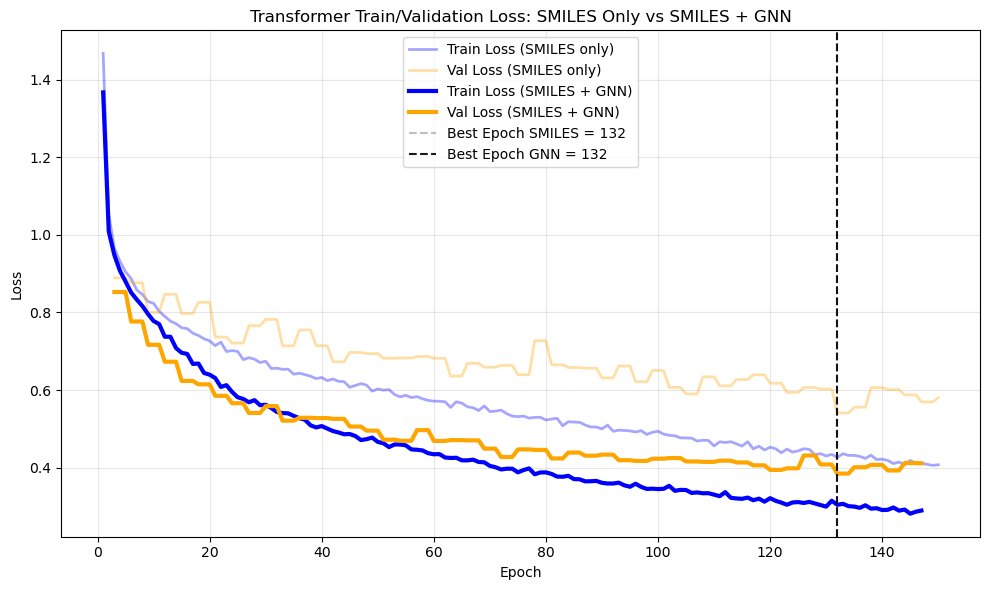

In [60]:
smiles_path = "cached_data/final_transformer_full_35k_5class_smiles_only.pkl"
gnn_path = "cached_data/final_transformer_full_35k_5class_with_gnn.pkl"

smiles_results = load_pickle_cuda_to_cpu(smiles_path)
gnn_results = load_pickle_cuda_to_cpu(gnn_path)

print("Loaded SMILES-only and SMILES+GNN results")

plot_transformer_loss_comparison(smiles_results, gnn_results)

In [61]:
def plot_transformer_f1_comparison(smiles_results, gnn_results):
    plt.figure(figsize=(10, 6))

    epochs_smiles = range(1, len(smiles_results["train_f1s"]) + 1)
    epochs_gnn = range(1, len(gnn_results["train_f1s"]) + 1)

    # SMILES-only: lighter
    plt.plot(
        epochs_smiles,
        smiles_results["train_f1s"],
        color="blue",
        alpha=0.35,
        linewidth=2,
        label=f"Train F1 SMILES only = {smiles_results['train_f1']:.3f}"
    )

    plt.plot(
        epochs_smiles,
        smiles_results["val_f1s"],
        color="orange",
        alpha=0.35,
        linewidth=2,
        label=f"Val F1 SMILES only = {smiles_results['val_f1']:.3f}"
    )

    # SMILES + GNN: highlighted
    plt.plot(
        epochs_gnn,
        gnn_results["train_f1s"],
        color="blue",
        alpha=1.0,
        linewidth=3,
        label=f"Train F1 SMILES + GNN = {gnn_results['train_f1']:.3f}"
    )

    plt.plot(
        epochs_gnn,
        gnn_results["val_f1s"],
        color="orange",
        alpha=1.0,
        linewidth=3,
        label=f"Val F1 SMILES + GNN = {gnn_results['val_f1']:.3f}"
    )

    # best epochs
    plt.axvline(
        smiles_results["best_epoch"],
        color="gray",
        linestyle="--",
        alpha=0.5,
        label=f"Best Epoch SMILES only = {smiles_results['best_epoch']}"
    )

    plt.axvline(
        gnn_results["best_epoch"],
        color="black",
        linestyle="--",
        alpha=0.9,
        label=f"Best Epoch SMILES + GNN = {gnn_results['best_epoch']}"
    )

    # test F1 scores as text box
    text_str = (
        f"Test F1 SMILES only: {smiles_results['test_f1']:.3f}\n"
        f"Test F1 SMILES + GNN: {gnn_results['test_f1']:.3f}"
    )

    plt.text(
        0.62, 0.08,
        text_str,
        transform=plt.gca().transAxes,
        bbox=dict(facecolor="white", alpha=0.85)
    )

    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.title("Transformer Macro-F1: SMILES Only vs SMILES + GNN")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

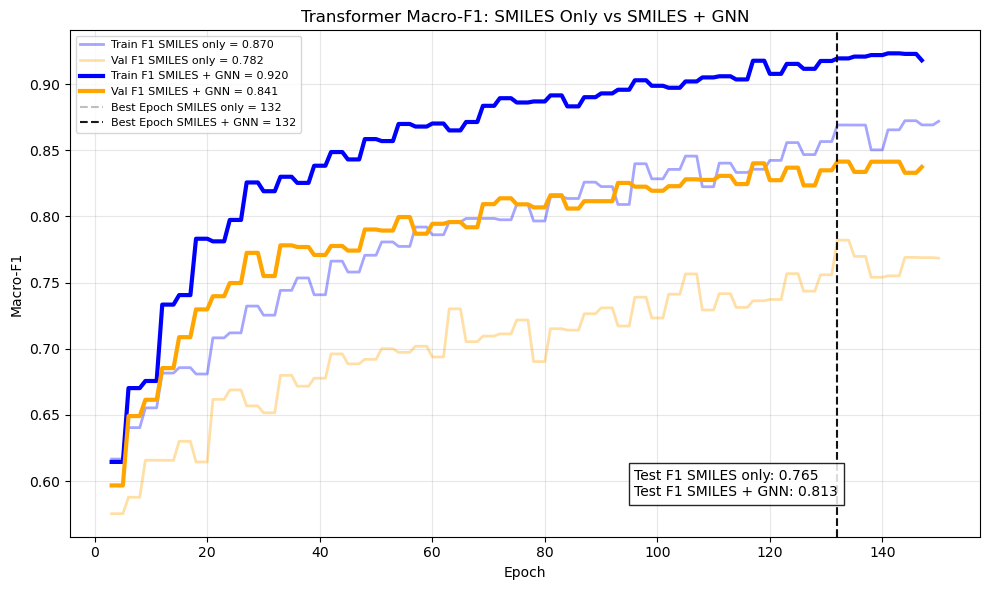

In [62]:
plot_transformer_f1_comparison(smiles_results, gnn_results)

In [63]:
def plot_confusion_matrix_clean(results, title="Test Confusion Matrix"):
    class_ids = [0, 1, 2, 3, 4]
    short_labels = [f"C{i}" for i in class_ids]

    y_true = results["test_labels"].cpu().numpy()
    y_pred = results["test_preds"].cpu().numpy()

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=class_ids,
        normalize="true"
    )

    fig, ax = plt.subplots(figsize=(7, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=short_labels
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format=".2f",
        colorbar=True
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.grid(False)

    plt.tight_layout()
    plt.show()

def plot_class_legend():
    class_names = {
        0: "Heteroatom alkylation / arylation",
        1: "Functional group transformations (incl. acylation)",
        2: "C–C bond formation / ring formation",
        3: "Protection / deprotection",
        4: "Redox",
    }

    legend_text = "\n".join([
        f"C{i}: {class_names[i]}" for i in range(5)
    ])

    plt.figure(figsize=(6, 3))
    plt.text(
        0.05, 0.5,
        legend_text,
        fontsize=12,
        va="center",
        bbox=dict(facecolor="white", edgecolor="black")
    )

    plt.axis("off")
    plt.title("Reaction Class Legend")
    plt.show()

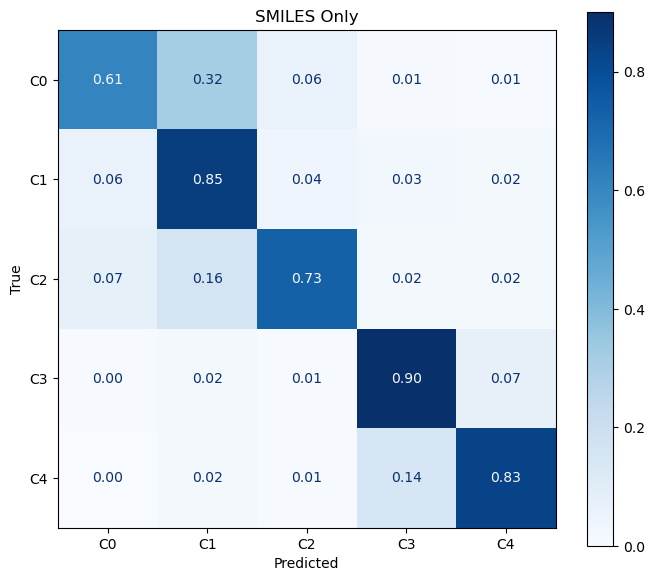

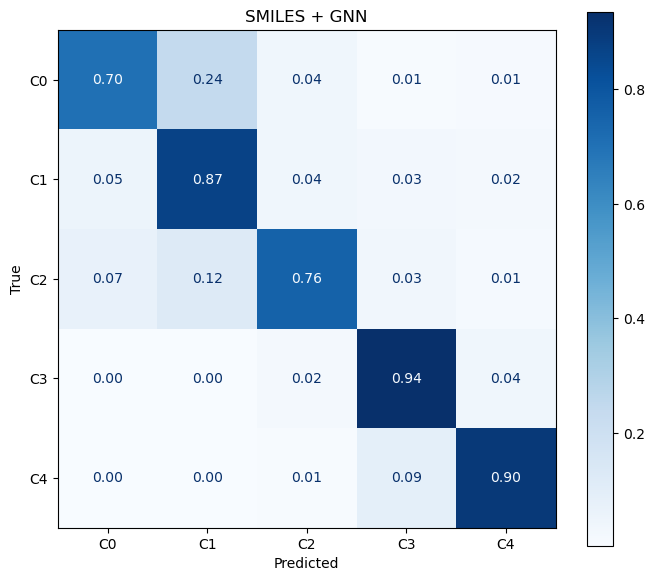

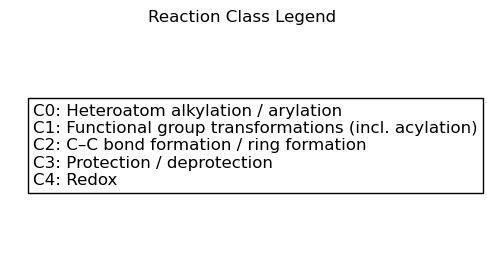

In [64]:
plot_confusion_matrix_clean(smiles_results, title="SMILES Only")
plot_confusion_matrix_clean(gnn_results, title="SMILES + GNN")

plot_class_legend()


In [ ]:
# just a wrapper to help print things, nothing new here
def explain_smiles_reaction(
    reactant_smiles,
    product_smiles,
    transformer_model,
    tokenizer,
    structure_predictor,
    target_class=None,
    include_gnn_vec=True,
    gnn_dim=9,
    device="cpu",
    top_k=8,
    min_importance=0.0,
    max_len=512,
    new_category=None,
    show=True,
):
    # class mapping (1–5)
    class_names = {
        1: "Heteroatom alkylation / arylation",
        2: "Functional group transformations (incl. acylation)",
        3: "C–C bond formation / ring formation",
        4: "Protection / deprotection",
        5: "Redox",
    }

    # build row
    row = pd.Series({
        "reactant": reactant_smiles,
        "product": product_smiles,
    })

    if new_category is not None:
        row["new_category"] = new_category

    # GNN features
    if include_gnn_vec:
        row["reactant_preds"] = structure_predictor.get_structure_preds(row["reactant"])
        row["product_preds"] = structure_predictor.get_structure_preds(row["product"])

        temp_df = pd.DataFrame([row])
        temp_df = normalize_gnn_preds(temp_df)
        row = temp_df.iloc[0]

    # run explanation
    motif_results = explain_reaction_motif(
        model=transformer_model,
        tokenizer=tokenizer,
        row=row,
        include_gnn_vec=include_gnn_vec,
        gnn_dim=gnn_dim,
        device=device,
        target_class=target_class,
        top_k=top_k,
        min_importance=min_importance,
        max_len=max_len,
        show=show,
    )

    # extract predictions
    pred_class = motif_results["pred_class"]
    pred_prob = motif_results["pred_prob"]

    print("\n=== Prediction ===")
    print(f"Predicted class: {pred_class} ({class_names[pred_class]})")
    print(f"Predicted probability: {pred_prob:.4f}")

    if target_class is not None:
        print("\n=== Target Explanation ===")
        print(f"Target class: {target_class} ({class_names[target_class]})")
        print(f"Target probability: {motif_results['probs'][target_class-1]:.4f}")

    return motif_results

In [73]:
# some mass balance was ignored intentionally to see how well it held up 
real_reactions = [
    {
        "name": "SN2 (Williamson ether synthesis)",
        "class": 1,
        "reactant": "CCO.CCCl",
        "product": "CCOCC",
    },
    {
        "name": "Amide formation",
        "class": 2,
        "reactant": "CC(=O)Cl.NCC",
        "product": "CC(=O)NCC",
    },
    {
        "name": "Aldol addition (simplified)",
        "class": 3,
        "reactant": "CC=O.CC=O",
        "product": "CC(O)CC(=O)C",
    },
    {
        "name": "BOC protection",
        "class": 4,
        "reactant": "CN.CC(C)(C)OC(=O)Cl",
        "product": "CNC(=O)OC(C)(C)C",
    },
    {
        "name": "Oxidation",
        "class": 5,
        "reactant": "CC(O)C",
        "product": "CC(=O)C",
    },
    {
        "name": "Functional Group Interconversion",
        "class": 2,
        "reactant": "CCCO.O=S(Cl)Cl",
        "product": "CCCCl",
    }
]


SN2 (Williamson ether synthesis)
Predicted class: 1
Predicted probability: 0.9975
Explaining class: 1
Target probability: 0.9975


,token_index,token,original_prob,masked_prob,importance,target_class,pred_class
0,10,Cl,0.997525,0.993144,0.004381,1,1


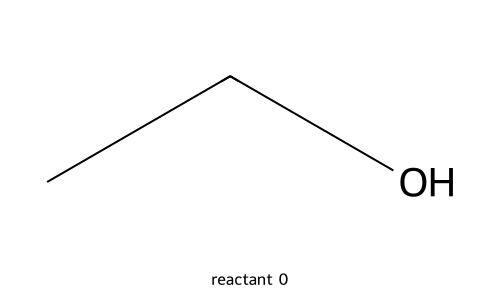

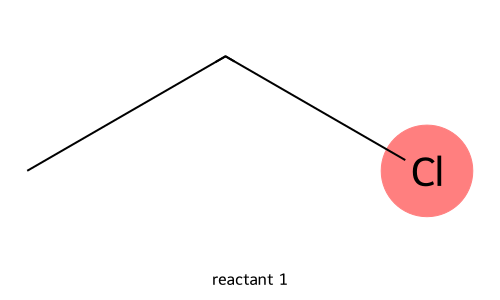

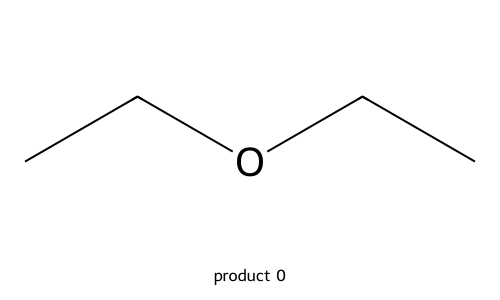


=== Prediction ===
Predicted class: 1 (Heteroatom alkylation / arylation)
Predicted probability: 0.9975

=== Target Explanation ===
Target class: 1 (Heteroatom alkylation / arylation)
Target probability: 0.9975

Amide formation
Predicted class: 2
Predicted probability: 0.5703
Explaining class: 2
Target probability: 0.5703


,token_index,token,original_prob,masked_prob,importance,target_class,pred_class
0,4,C,0.570276,0.568192,0.002084,2,2


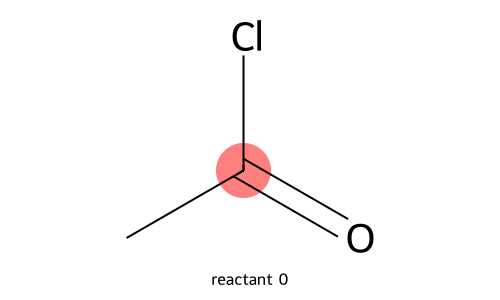

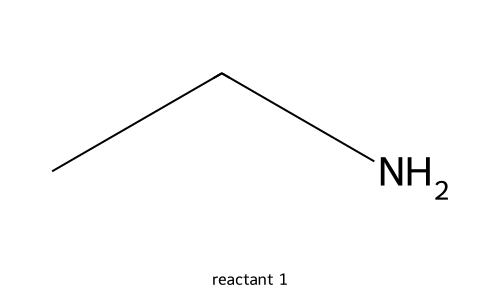

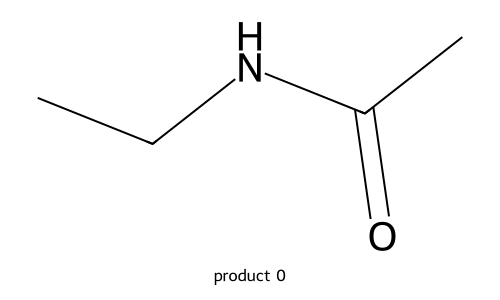


=== Prediction ===
Predicted class: 2 (Functional group transformations (incl. acylation))
Predicted probability: 0.5703

=== Target Explanation ===
Target class: 2 (Functional group transformations (incl. acylation))
Target probability: 0.5703

Aldol addition (simplified)
Predicted class: 2
Predicted probability: 0.5390
Explaining class: 3
Target probability: 0.0184


,token_index,token,original_prob,masked_prob,importance,target_class,pred_class
0,9,C,0.018394,0.009741,0.008653,3,2
1,10,C,0.018394,0.010157,0.008237,3,2
2,3,C,0.018394,0.011573,0.006821,3,2
3,16,C,0.018394,0.011937,0.006456,3,2
4,4,C,0.018394,0.012068,0.006326,3,2
5,17,C,0.018394,0.012144,0.006249,3,2


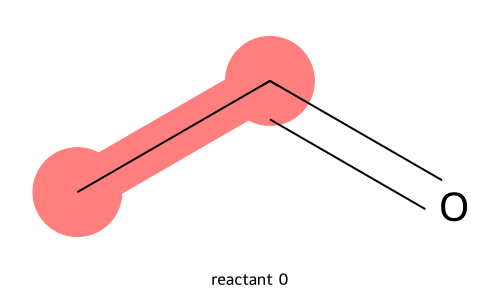

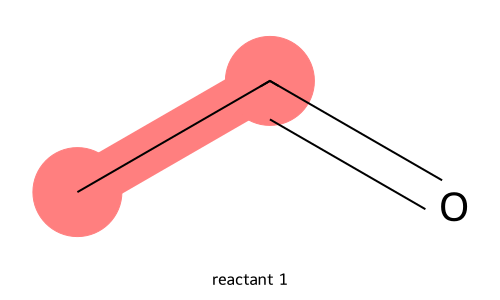

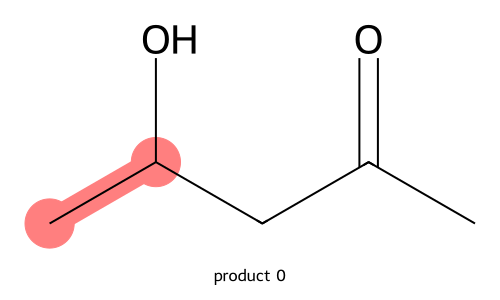


=== Prediction ===
Predicted class: 2 (Functional group transformations (incl. acylation))
Predicted probability: 0.5390

=== Target Explanation ===
Target class: 3 (C–C bond formation / ring formation)
Target probability: 0.0184

BOC protection
Predicted class: 2
Predicted probability: 0.9791
Explaining class: 4
Target probability: 0.0000


,token_index,token,original_prob,masked_prob,importance,target_class,pred_class
0,26,N,0.000002,0.000001,5.201247e-07,4,2
1,32,O,0.000002,0.000001,4.098207e-07,4,2
2,21,Cl,0.000002,0.000001,3.301784e-07,4,2
3,30,O,0.000002,0.000001,2.782738e-07,4,2
4,15,O,0.000002,0.000001,2.742062e-07,4,2
5,19,O,0.000002,0.000001,1.582464e-07,4,2


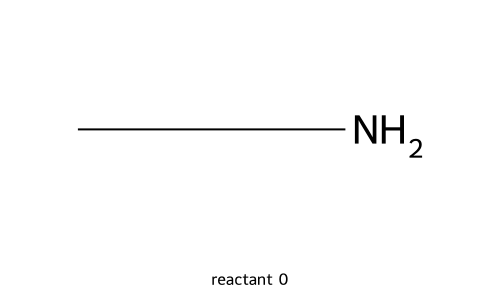

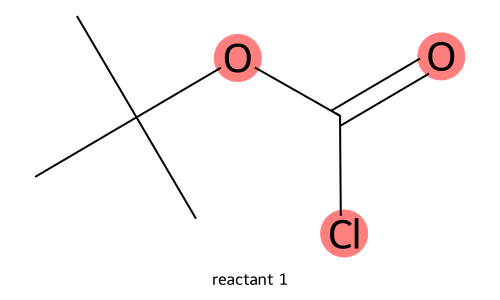

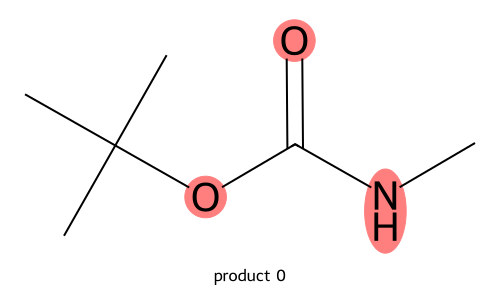


=== Prediction ===
Predicted class: 2 (Functional group transformations (incl. acylation))
Predicted probability: 0.9791

=== Target Explanation ===
Target class: 4 (Protection / deprotection)
Target probability: 0.0000

Oxidation
Predicted class: 4
Predicted probability: 0.9945
Explaining class: 5
Target probability: 0.0019


,token_index,token,original_prob,masked_prob,importance,target_class,pred_class
0,18,C,0.001855,0.001270,0.000585,5,4
1,12,C,0.001855,0.001381,0.000473,5,4
2,13,C,0.001855,0.001463,0.000391,5,4
3,8,C,0.001855,0.001592,0.000263,5,4
4,4,C,0.001855,0.001831,0.000023,5,4


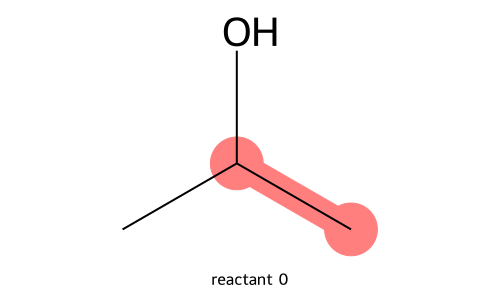

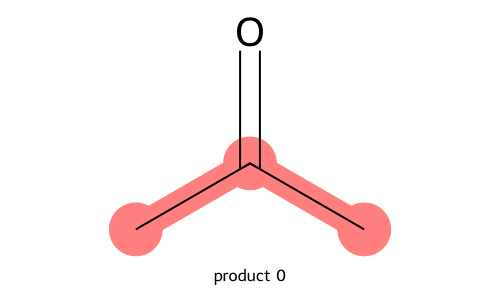


=== Prediction ===
Predicted class: 4 (Protection / deprotection)
Predicted probability: 0.9945

=== Target Explanation ===
Target class: 5 (Redox)
Target probability: 0.0019

Functional Group Interconversion
Predicted class: 1
Predicted probability: 0.8862
Explaining class: 2
Target probability: 0.1104


,token_index,token,original_prob,masked_prob,importance,target_class,pred_class
0,22,Cl,0.110379,0.062755,0.047624,2,1
1,11,S,0.110379,0.063998,0.046381,2,1
2,13,Cl,0.110379,0.077720,0.032660,2,1
3,15,Cl,0.110379,0.083354,0.027026,2,1
4,5,C,0.110379,0.090661,0.019718,2,1
5,21,C,0.110379,0.091000,0.019379,2,1


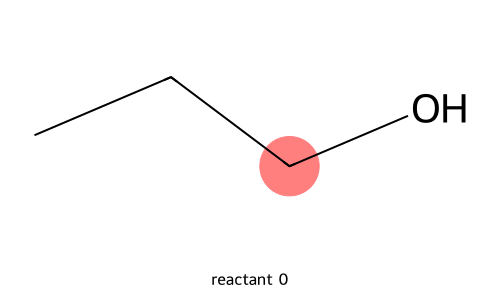

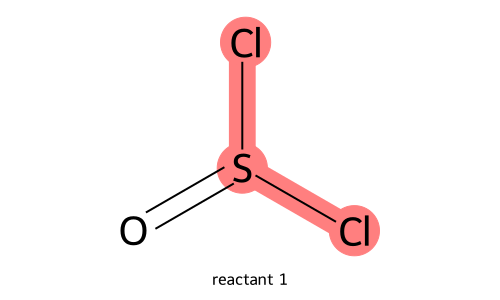

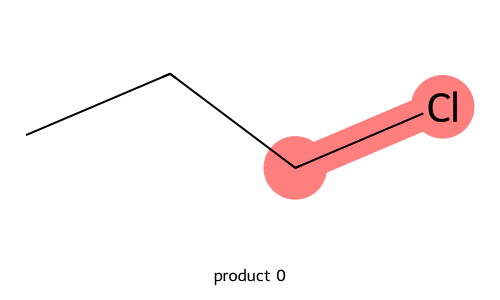


=== Prediction ===
Predicted class: 1 (Heteroatom alkylation / arylation)
Predicted probability: 0.8862

=== Target Explanation ===
Target class: 2 (Functional group transformations (incl. acylation))
Target probability: 0.1104


In [ ]:
for rxn in real_reactions:
    print("\n" + "="*70)
    print(rxn["name"])

    explain_smiles_reaction(
        reactant_smiles=rxn["reactant"],
        product_smiles=rxn["product"],
        transformer_model=gnn_results["model"],
        tokenizer=tokenizer,
        structure_predictor=structure_predictor,
        target_class=rxn["class"],
        new_category=rxn["class"],
        device=device,
        top_k=6, # the top number of delta porbabilities
        show=True,
    )